# GLM-HMM Behavioral State Discovery
## 2-Armed Bandit Task — Common Marmoset

**Purpose:**  
Fit GLM-Hidden Markov Models to discover latent behavioral states from trial-by-trial choice data.  
Two model variants are compared (autoregressive and non-autoregressive), and model selection  
is performed across K = 2–6 states using log-likelihood and BIC.

**Pipeline:**
1. Configuration & imports  
2. Load preprocessed data  
3. Feature preparation (AR and non-AR)  
4. GLM-HMM class  
5. Model selection: fit K = 2–6 for both model types  
6. Select best model  
7. Characterize states  
8. Visualize results  

**Key outputs:**  
- `results_selection` : dict of all fitted models and their BIC scores  
- `model` : selected best model  
- `df` : trial-level dataframe with GLM-HMM state assignments appended  

---

## 1. Configuration & Imports

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.special import logsumexp
from scipy.optimize import minimize
from scipy.stats import sem
from sklearn.preprocessing import StandardScaler

# ── Plotting defaults ─────────────────────────────────────────────────────────
FONTSIZE   = 8
LINE_WIDTH = 0.5
TICK_LEN   = 2

plt.rcParams.update({
    'font.family'         : 'Arial',
    'font.size'           : FONTSIZE,
    'axes.linewidth'      : LINE_WIDTH,
    'xtick.major.width'   : LINE_WIDTH,
    'ytick.major.width'   : LINE_WIDTH,
    'xtick.major.size'    : TICK_LEN,
    'ytick.major.size'    : TICK_LEN,
    'lines.linewidth'     : LINE_WIDTH,
    'svg.fonttype'        : 'none',
})

# ── Animal metadata ───────────────────────────────────────────────────────────
ANIMAL_ORDER = ['Coral','Tuna','Fiona','Salmon','Knuckles',
                'Raven','Sonic','Zazu','Griffin','Sunflower']

ANIMAL_COLORS = {
    'Coral': '#e74c3c',      # Coral/Red
    'Raven': '#2ecc71',      # Green
    'Tuna': '#8b7355',       # Brown/Tan
    'Sonic': '#34495e',      # Dark Gray
    'Griffin': '#9b59b6',    # Purple
    'Sunflower': '#1abc9c',  # Teal/Cyan
    'Zazu': '#3498db',       # Light Blue
    'Salmon': '#f39c12',     # Orange/Yellow
    'Fiona':  '#e91e63',      # Pink/Magenta
    'Knuckles': '#e67e22'    # Orange/Brown
}


ANIMAL_COLORS = {
    'Coral'    : '#e74c3c',
    'Raven'    : '#2ecc71',
    'Tuna'     : '#8b7355',
    'Sonic'    : '#34495e',
    'Griffin'  : '#9b59b6',
    'Sunflower': '#1abc9c',
    'Zazu'     : '#3498db',
    'Salmon'   : '#f39c12',
    'Fiona'    : '#e91e63',
    'Knuckles' : '#16a085',
}

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_PATH  = (
    '/Users/kevinmastro/Library/CloudStorage/'
    'GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/'
    '2-Experiments/5 - Monkey Logic Task/4 - Outputs/'
)
FIGURE_PATH = os.path.join(BASE_PATH, '2-graphs', '2-ABT_80-20_performance_GLM_HMM')
os.makedirs(FIGURE_PATH, exist_ok=True)

DATA_PATH = (
    BASE_PATH +
    '2-graphs/2-ABT_80-20_performance/preprocessed_Reversal_80-20.csv'
)

# ── Model selection parameters ────────────────────────────────────────────────
K_RANGE     = range(2,4) #range(2, 7)       # K = 2, 3, 4, 5, 6
NUM_ITER    = 100               # max EM iterations per model
RANDOM_SEED = 42
STICKINESS  = 5                # prior pseudo-counts on diagonal of transition matrix
L2_PENALTY  = 1.0               # L2 regularisation on GLM weights

print('Configuration loaded.')
print(f'  K range     : {list(K_RANGE)}')
print(f'  EM iters    : {NUM_ITER}')
print(f'  Stickiness  : {STICKINESS}')
print(f'  L2 penalty  : {L2_PENALTY}')
print(f'  Figure path : {FIGURE_PATH}')

Configuration loaded.
  K range     : [2, 3]
  EM iters    : 100
  Stickiness  : 5
  L2 penalty  : 1.0
  Figure path : /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/2-ABT_80-20_performance_GLM_HMM


## 2. Load Preprocessed Data

In [9]:
try:
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded preprocessed data: {len(df):,} trials')
except FileNotFoundError:
    raise FileNotFoundError(
        f'Preprocessed data not found at:\n  {DATA_PATH}\n'
        'Run the preprocessing notebook first.'
    )

# Ensure required columns exist
required_cols = ['Session_ID', 'Animal_Name', 'BlockCount', 'Choice_Binary',
                 'High_Prob', 'Outcome_Binary', 'PhysicalSwitch']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

print(f'  Animals  : {sorted(df["Animal_Name"].unique())}')
print(f'  Sessions : {df["Session_ID"].nunique()}')
print(f'  Trials   : {len(df):,}')

Loaded preprocessed data: 36,673 trials
  Animals  : ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']
  Sessions : 100
  Trials   : 36,673


## 3. Feature Preparation

Two feature sets are prepared:

**AR (autoregressive):** Uses lagged choices and rewards as predictors.  
Each state captures a distinct *integration strategy* — how the animal  
weights recent outcomes and choices to make the next decision.

**Non-AR:** Uses rolling performance metrics (accuracy at two timescales)  
and block structure. Each state captures a distinct *performance mode* —  
how accurately and consistently the animal is performing.

Both are fit and compared via BIC.

In [10]:
def _add_block_cols(df):
    """
    Add Trial_in_Block and Trials_Since_Transition columns if not present.
    Both are computed per session.
    """
    if 'Trial_in_Block' not in df.columns:
        df['Trial_in_Block'] = (
            df.groupby(['Session_ID', 'BlockCount']).cumcount()
        )

    if 'Trials_Since_Transition' not in df.columns:
        df['Trials_Since_Transition'] = 0
        for session in df['Session_ID'].unique():
            mask   = df['Session_ID'] == session
            trans  = df.loc[mask, 'BlockCount'].diff().fillna(0).abs() > 0
            ctr, ts = 0, []
            for is_trans in trans:
                if is_trans:
                    ctr = 0
                ts.append(ctr)
                ctr += 1
            df.loc[mask, 'Trials_Since_Transition'] = ts
    return df


def prepare_features_AR(df):
    """
    Autoregressive feature set.

    Features
    --------
    Bias                    : intercept
    Reward_t-1/2/3          : rewarded on trial t-n (0/1)
    Choice_t-1/2/3          : choice on trial t-n, mean-centred (-0.5/+0.5)
    Reward×Choice_t-1/2     : interaction of reward and choice at t-n
    Block_Position          : trial index within block, normalised by 20
    Log_Trials_Since_Trans  : log(1 + trials since last reversal)

    Target: Choice_Binary (0 = left, 1 = right)

    Rationale: States differ in HOW the animal integrates recent history
    (win-stay, lose-switch, perseveration, random exploration).
    """
    df = df.copy()

    if 'Choice_Binary' not in df.columns:
        df['Choice_Binary'] = df['PhysicalChoice'].map({
            'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
            'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1,
        })
    if 'Outcome_Binary' not in df.columns:
        df['Outcome_Binary'] = df['Outcome'].astype(int)

    for n in range(1, 4):
        if f'Reward_Lag{n}' not in df.columns:
            df[f'Reward_Lag{n}'] = (
                df.groupby('Session_ID')['Outcome_Binary'].shift(n).fillna(0)
            )
        if f'Choice_Lag{n}' not in df.columns:
            df[f'Choice_Lag{n}'] = (
                df.groupby('Session_ID')['Choice_Binary'].shift(n).fillna(0)
            )

    df = _add_block_cols(df)

    features, names = [], []
    features.append(np.ones(len(df)));                      names.append('Bias')
    for n in range(1, 4):
        features.append(df[f'Reward_Lag{n}'].values);       names.append(f'Reward_t-{n}')
    for n in range(1, 4):
        features.append(df[f'Choice_Lag{n}'].values - 0.5); names.append(f'Choice_t-{n}')
    for n in range(1, 3):
        features.append(
            df[f'Reward_Lag{n}'].values * (df[f'Choice_Lag{n}'].values - 0.5)
        )
        names.append(f'Reward×Choice_t-{n}')
    features.append(df['Trial_in_Block'].values / 20.0);    names.append('Block_Position')
    features.append(np.log1p(df['Trials_Since_Transition'].values))
    names.append('Log_Trials_Since_Trans')

    X           = np.column_stack(features)
    y           = df['Choice_Binary'].values
    session_ids = df['Session_ID'].values
    return X, y, session_ids, names, df


def prepare_features_nonAR(df):
    """
    Non-autoregressive feature set.

    Features
    --------
    Bias                    : intercept
    Rolling_Accuracy_3      : rolling accuracy over last 3 trials (fast timescale)
    Rolling_Accuracy_5      : rolling accuracy over last 5 trials (slow timescale)
    Log_Trials_Since_Trans  : log(1 + trials since last reversal)
    Block_Position_Norm     : position within current block, normalised to [0, 1]
    Block_Number_Norm       : block index within session, normalised to [0, 1]

    Target: High_Prob (0 = chose low-probability port, 1 = chose high-probability port)

    Rationale: States differ in CURRENT PERFORMANCE LEVEL rather than
    history integration strategy. Rolling accuracy at two timescales
    gives states distinct emission profiles and prevents weight saturation.
    """
    df = df.copy()
    df = _add_block_cols(df)

    if 'Outcome_Binary' not in df.columns:
        df['Outcome_Binary'] = df['Outcome'].astype(int)

    df['Rolling_Accuracy_3'] = (
        df.groupby('Session_ID')['Outcome_Binary']
          .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )
    df['Rolling_Accuracy_5'] = (
        df.groupby('Session_ID')['Outcome_Binary']
          .transform(lambda x: x.rolling(5, min_periods=1).mean())
    )
    df['Block_Number_Norm'] = df.groupby('Session_ID')['BlockCount'].transform(
        lambda x: (x - x.min()) / max(x.max() - x.min(), 1)
    )
    block_lengths = df.groupby(['Session_ID', 'BlockCount'])['Trial_in_Block'].transform('max')
    df['Block_Position_Norm'] = df['Trial_in_Block'] / block_lengths.clip(lower=1)

    features = [
        np.ones(len(df)),
        df['Rolling_Accuracy_3'].values,
        df['Rolling_Accuracy_5'].values,
        np.log1p(df['Trials_Since_Transition'].values),
        df['Block_Position_Norm'].values,
        df['Block_Number_Norm'].values,
    ]
    names = [
        'Bias', 'Rolling_Accuracy_3', 'Rolling_Accuracy_5',
        'Log_Trials_Since_Trans', 'Block_Position_Norm', 'Block_Number_Norm',
    ]

    X           = np.column_stack(features)
    y           = df['High_Prob'].values
    session_ids = df['Session_ID'].values
    return X, y, session_ids, names, df


# Prepare both feature sets
X_AR,    y_AR,    sess_AR,    names_AR,    df_AR    = prepare_features_AR(df)
X_nonAR, y_nonAR, sess_nonAR, names_nonAR, df_nonAR = prepare_features_nonAR(df)

# Standardise (skip bias column at index 0)
scaler_AR    = StandardScaler()
scaler_nonAR = StandardScaler()

Xs_AR              = X_AR.copy()
Xs_AR[:, 1:]       = scaler_AR.fit_transform(X_AR[:, 1:])

Xs_nonAR           = X_nonAR.copy()
Xs_nonAR[:, 1:]    = scaler_nonAR.fit_transform(X_nonAR[:, 1:])

print('Feature sets prepared and standardised.')
print(f'  AR    : {Xs_AR.shape[1]} features → {names_AR}')
print(f'  non-AR: {Xs_nonAR.shape[1]} features → {names_nonAR}')

Feature sets prepared and standardised.
  AR    : 11 features → ['Bias', 'Reward_t-1', 'Reward_t-2', 'Reward_t-3', 'Choice_t-1', 'Choice_t-2', 'Choice_t-3', 'Reward×Choice_t-1', 'Reward×Choice_t-2', 'Block_Position', 'Log_Trials_Since_Trans']
  non-AR: 6 features → ['Bias', 'Rolling_Accuracy_3', 'Rolling_Accuracy_5', 'Log_Trials_Since_Trans', 'Block_Position_Norm', 'Block_Number_Norm']


## 4. GLM-HMM Class

In [11]:
class GLM_HMM:
    """
    GLM-Hidden Markov Model for binary choice data.

    Architecture
    ------------
    - K hidden states, each with its own GLM weight vector.
    - Emissions: P(choice_t | state_k, X_t) = sigmoid(X_t @ w_k)
    - Transitions: K×K matrix with stickiness prior on diagonal.
    - Fitting: Baum-Welch EM with scipy L-BFGS-B for the M-step GLM solve.

    Key design decisions
    --------------------
    GLM solver     : scipy L-BFGS-B (scale-invariant, guaranteed convergence).
    L2 penalty     : 1.0 (keeps weights in reasonable range, prevents saturation).
    Stickiness     : pseudo-counts on diagonal of transition prior (controls
                     mean dwell time; tune relative to n_trials).
    Xi marginals   : two-slice marginals used for transition M-step (correct
                     Baum-Welch; not the gamma×gamma approximation).
    Per-session FB : forward/backward run independently per session so
                     session boundaries are never crossed.
    """

    def __init__(self, n_states, n_features, random_seed=42,
                 stickiness=20.0, l2_penalty=1.0):
        self.n_states   = n_states
        self.n_features = n_features
        self.stickiness = stickiness
        self.l2_penalty = l2_penalty
        np.random.seed(random_seed)

        # GLM weights: small random init
        self.weights = np.random.randn(n_states, n_features) * 0.1

        # Transition matrix: strong self-transitions
        off = 0.05 / max(n_states - 1, 1)
        self.transitions = np.full((n_states, n_states), off)
        np.fill_diagonal(self.transitions, 0.95)
        self.transitions /= self.transitions.sum(axis=1, keepdims=True)

        self.initial             = np.ones(n_states) / n_states
        self.log_likelihood_history = []
        self.final_ll            = None
        self.bic                 = None

    # ── Emission probabilities ────────────────────────────────────────────────

    def choice_probability(self, X, state):
        """P(y=1 | X, state) via sigmoid."""
        logits = X @ self.weights[state]
        return 1.0 / (1.0 + np.exp(-np.clip(logits, -20, 20)))

    def _log_emissions(self, X, y):
        """Precompute log P(y_t | state_k) for all t, k. Shape: (T, K)."""
        T, K     = len(y), self.n_states
        log_emit = np.zeros((T, K))
        for k in range(K):
            p = self.choice_probability(X, k)
            log_emit[:, k] = np.where(
                y == 1,
                np.log(np.clip(p,     1e-10, 1 - 1e-10)),
                np.log(np.clip(1 - p, 1e-10, 1 - 1e-10)),
            )
        return log_emit

    # ── Per-session forward / backward ────────────────────────────────────────

    def _forward_session(self, log_emit_s):
        T_s, K   = log_emit_s.shape
        log_A    = np.log(self.transitions + 1e-10)
        log_init = np.log(self.initial      + 1e-10)

        log_alpha    = np.zeros((T_s, K))
        log_alpha[0] = log_init + log_emit_s[0]
        for t in range(1, T_s):
            for k in range(K):
                log_alpha[t, k] = (
                    logsumexp(log_alpha[t - 1] + log_A[:, k])
                    + log_emit_s[t, k]
                )
        return log_alpha, logsumexp(log_alpha[-1])

    def _backward_session(self, log_emit_s):
        T_s, K  = log_emit_s.shape
        log_A   = np.log(self.transitions + 1e-10)
        log_beta = np.zeros((T_s, K))
        for t in range(T_s - 2, -1, -1):
            for k in range(K):
                log_beta[t, k] = logsumexp(
                    log_A[k, :] + log_emit_s[t + 1, :] + log_beta[t + 1, :]
                )
        return log_beta

    # ── E-step ────────────────────────────────────────────────────────────────

    def expectation_step(self, X, y, sessions):
        """
        Compute posterior state probabilities (gamma) and log-likelihood.
        Returns gamma (T, K), total_ll (scalar), sess_data (list of per-session
        log_alpha / log_beta / log_emit for use in xi computation).
        """
        T        = len(y)
        K        = self.n_states
        gamma    = np.zeros((T, K))
        total_ll = 0.0
        sess_data = []

        for (s, e) in sessions:
            log_emit_s        = self._log_emissions(X[s:e], y[s:e])
            log_alpha_s, ll_s = self._forward_session(log_emit_s)
            log_beta_s        = self._backward_session(log_emit_s)
            total_ll         += ll_s

            log_gamma_s  = log_alpha_s + log_beta_s
            log_gamma_s -= logsumexp(log_gamma_s, axis=1, keepdims=True)
            gamma[s:e]   = np.exp(log_gamma_s)

            sess_data.append((log_alpha_s, log_beta_s, log_emit_s))

        return gamma, total_ll, sess_data

    # ── Xi (two-slice marginals) ──────────────────────────────────────────────

    def _xi_session(self, log_alpha_s, log_beta_s, log_emit_s):
        """
        Accumulate xi[t,i,j] = P(z_t=i, z_{t+1}=j | data) over all t
        within a session. Returns summed (K, K) matrix.
        Using the full two-slice marginal (not gamma×gamma) ensures correct
        Baum-Welch transition updates.
        """
        T_s   = log_alpha_s.shape[0]
        K     = self.n_states
        log_A = np.log(self.transitions + 1e-10)
        xi_sum = np.zeros((K, K))

        for t in range(T_s - 1):
            log_xi_t = np.zeros((K, K))
            for i in range(K):
                for j in range(K):
                    log_xi_t[i, j] = (
                        log_alpha_s[t, i]
                        + log_A[i, j]
                        + log_emit_s[t + 1, j]
                        + log_beta_s[t + 1, j]
                    )
            log_xi_t -= logsumexp(log_xi_t.ravel())
            xi_sum   += np.exp(log_xi_t)

        return xi_sum

    # ── GLM M-step solver ─────────────────────────────────────────────────────

    def _fit_glm_state(self, X, y, weights_k, init_w):
        """
        Fit GLM weights for state k via weighted logistic regression
        using scipy L-BFGS-B.

        weights_k : (T,) soft assignment probabilities (gamma[:, k]).
        init_w    : (n_features,) warm-start weights from previous iteration.

        L-BFGS-B is scale-invariant so convergence does not depend on
        learning rate or dataset size.
        """
        l2 = self.l2_penalty

        def neg_ll_and_grad(w):
            logits = np.clip(X @ w, -20, 20)
            p      = 1.0 / (1.0 + np.exp(-logits))
            ll     = weights_k * (
                y       * np.log(np.clip(p,     1e-10, 1 - 1e-10)) +
                (1 - y) * np.log(np.clip(1 - p, 1e-10, 1 - 1e-10))
            )
            loss = -(ll.sum() - l2 * np.sum(w ** 2))
            grad = -(X.T @ (weights_k * (y - p)) - 2.0 * l2 * w)
            return loss, grad

        result = minimize(
            neg_ll_and_grad, init_w, jac=True, method='L-BFGS-B',
            options={'maxiter': 100, 'ftol': 1e-9, 'gtol': 1e-6},
        )
        return result.x

    # ── M-step ────────────────────────────────────────────────────────────────

    def maximization_step(self, X, y, gamma, sessions, sess_data):
        K = self.n_states

        # GLM weights: one L-BFGS-B solve per state
        for k in range(K):
            self.weights[k] = self._fit_glm_state(
                X, y, gamma[:, k], self.weights[k]
            )

        # Transition matrix: xi + stickiness prior
        xi_total = np.zeros((K, K))
        for (log_alpha_s, log_beta_s, log_emit_s) in sess_data:
            xi_total += self._xi_session(log_alpha_s, log_beta_s, log_emit_s)

        prior = np.zeros((K, K))
        np.fill_diagonal(prior, self.stickiness)

        counts           = xi_total + prior
        self.transitions = counts / counts.sum(axis=1, keepdims=True)

        # Initial state distribution
        init_counts = np.zeros(K)
        for (s, _) in sessions:
            init_counts += gamma[s]
        self.initial = init_counts / init_counts.sum()

    # ── Fit ───────────────────────────────────────────────────────────────────

    def _build_sessions(self, session_ids):
        """Return list of (start, end) index pairs per session."""
        sessions = []
        for sess in pd.unique(session_ids):
            idx = np.where(session_ids == sess)[0]
            sessions.append((idx[0], idx[-1] + 1))
        return sessions

    def fit(self, X, y, session_ids, n_iter=100, verbose=True):
        sessions = self._build_sessions(session_ids)
        n_params = self.n_states * self.n_features + self.n_states * (self.n_states - 1)

        if verbose:
            print(f'  K={self.n_states} | Features={self.n_features} | '
                  f'Trials={len(y):,} | Sessions={len(sessions)}')

        prev_ll = -np.inf
        for iteration in range(n_iter):
            gamma, total_ll, sess_data = self.expectation_step(X, y, sessions)
            self.log_likelihood_history.append(total_ll)
            self.maximization_step(X, y, gamma, sessions, sess_data)

            if verbose and (iteration + 1) % 10 == 0:
                diag   = np.diag(self.transitions)
                dwell  = 1.0 / np.maximum(1 - diag, 1e-6)
                delta  = total_ll - prev_ll
                print(f'    Iter {iteration+1:3d}/{n_iter} | '
                      f'LL: {total_ll:>10.1f} (Δ{delta:+.1f}) | '
                      f'Dwell: {dwell.round(1)}')

            if abs(total_ll - prev_ll) < 0.1 and iteration > 10:
                if verbose:
                    print(f'    Converged at iteration {iteration + 1}')
                break
            prev_ll = total_ll

        self.final_ll = self.log_likelihood_history[-1]
        self.bic      = n_params * np.log(len(y)) - 2 * self.final_ll

        if verbose:
            print(f'    Final LL: {self.final_ll:.1f} | BIC: {self.bic:.1f}')

        return self

    # ── Viterbi decoding ──────────────────────────────────────────────────────

    def predict_states(self, X, y, session_ids):
        """Most likely state sequence (Viterbi) + posterior probabilities (gamma)."""
        sessions = self._build_sessions(session_ids)
        T, K     = len(y), self.n_states
        log_A    = np.log(self.transitions + 1e-10)
        log_init = np.log(self.initial      + 1e-10)
        states   = np.zeros(T, dtype=int)

        for (s, e) in sessions:
            T_s        = e - s
            log_emit_s = self._log_emissions(X[s:e], y[s:e])

            log_delta    = np.zeros((T_s, K))
            psi          = np.zeros((T_s, K), dtype=int)
            log_delta[0] = log_init + log_emit_s[0]

            for t in range(1, T_s):
                for k in range(K):
                    scores          = log_delta[t - 1] + log_A[:, k]
                    best            = np.argmax(scores)
                    log_delta[t, k] = scores[best] + log_emit_s[t, k]
                    psi[t, k]       = best

            seq     = np.zeros(T_s, dtype=int)
            seq[-1] = np.argmax(log_delta[-1])
            for t in range(T_s - 2, -1, -1):
                seq[t] = psi[t + 1, seq[t + 1]]
            states[s:e] = seq

        gamma, _, _ = self.expectation_step(X, y, sessions)
        return states, gamma


print('GLM_HMM class defined.')

GLM_HMM class defined.


## 5. Model Selection: K = 2–6, AR and non-AR

Both model types are fit for each K. BIC is used for model selection:  
`BIC = n_params × log(T) − 2 × log-likelihood`  

Lower BIC = better model (penalises complexity).

In [12]:
# ── Run model selection ───────────────────────────────────────────────────────
# # results_selection stores every fitted model and its BIC.

# can swap out stickiness values for AR and nonAR models
# for model_type, (X_fit, y_fit, sess_fit, names_fit, stickiness) in [
#     ('AR',    (Xs_AR,    y_AR,    sess_AR,    names_AR,    STICKINESS_AR)),
#     ('nonAR', (Xs_nonAR, y_nonAR, sess_nonAR, names_nonAR, STICKINESS_nonAR)),
# ]:


# Structure: results_selection[model_type][K] = {'model': ..., 'states': ..., 'gamma': ...}

results_selection = {'AR': {}, 'nonAR': {}}

for model_type, (X_fit, y_fit, sess_fit, names_fit) in [
    ('AR',    (Xs_AR,    y_AR,    sess_AR,    names_AR)),
    ('nonAR', (Xs_nonAR, y_nonAR, sess_nonAR, names_nonAR)),
]:
    print(f'\n{"="*60}')
    print(f'Model type: {model_type}')
    print(f'{"="*60}')

    for K in K_RANGE:
        print(f'\n  Fitting K={K}...')
        model_k = GLM_HMM(
            n_states   = K,
            n_features = X_fit.shape[1],
            random_seed = RANDOM_SEED,
            stickiness  = STICKINESS,
            l2_penalty  = L2_PENALTY,
        )
        model_k.fit(X_fit, y_fit, sess_fit, n_iter=NUM_ITER, verbose=True)
        states_k, gamma_k = model_k.predict_states(X_fit, y_fit, sess_fit)

        results_selection[model_type][K] = {
            'model' : model_k,
            'states': states_k,
            'gamma' : gamma_k,
            'bic'   : model_k.bic,
            'll'    : model_k.final_ll,
        }

print('\nModel selection complete.')


Model type: AR

  Fitting K=2...
  K=2 | Features=11 | Trials=36,673 | Sessions=100
    Iter  10/100 | LL:   -15481.0 (Δ+5.8) | Dwell: [50.5 12.2]


KeyboardInterrupt: 

## 6. Model Selection Plot & Selection

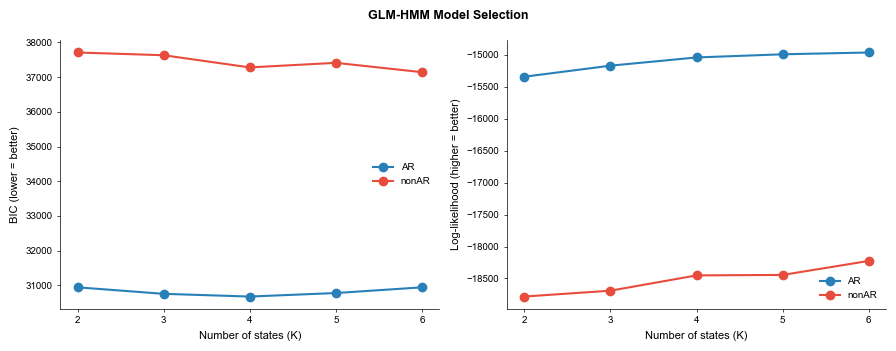


   Model    K           LL          BIC
----------------------------------------
      AR    2     -15345.8      30943.9
      AR    3     -15173.2      30756.2
      AR    4     -15044.6      30677.7
      AR    5     -14995.4      30779.1
      AR    6     -14967.2      30943.4
   nonAR    2     -18782.3      37711.7
   nonAR    3     -18690.3      37632.8
   nonAR    4     -18451.7      37281.7
   nonAR    5     -18444.2      37413.8
   nonAR    6     -18225.4      37144.4


In [ ]:
# ── Plot BIC and LL curves for both model types ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

colors = {'AR': '#2980b9', 'nonAR': '#e74c3c'}
Ks     = list(K_RANGE)

for ax, metric, label in zip(
    axes,
    ['bic', 'll'],
    ['BIC (lower = better)', 'Log-likelihood (higher = better)'],
):
    for mtype in ['AR', 'nonAR']:
        vals = [results_selection[mtype][K][metric] for K in Ks]
        ax.plot(Ks, vals, 'o-', color=colors[mtype], label=mtype, linewidth=1.5)

    ax.set_xlabel('Number of states (K)', fontsize=FONTSIZE)
    ax.set_ylabel(label, fontsize=FONTSIZE)
    ax.set_xticks(Ks)
    ax.legend(fontsize=FONTSIZE - 1, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=FONTSIZE - 1)

fig.suptitle('GLM-HMM Model Selection', fontsize=FONTSIZE + 1, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'model_selection_BIC.svg'), bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"Model":>8} {"K":>4} {"LL":>12} {"BIC":>12}')
print('-' * 40)
for mtype in ['AR', 'nonAR']:
    for K in Ks:
        r = results_selection[mtype][K]
        print(f'{mtype:>8} {K:>4} {r["ll"]:>12.1f} {r["bic"]:>12.1f}')

In [ ]:
# ── Select model to move forward with ────────────────────────────────────────
# Edit these two variables based on the BIC plot above.

SELECTED_MODEL_TYPE = 'AR'   # 'AR' or 'nonAR'
SELECTED_K          = 3      # integer from K_RANGE

# ─────────────────────────────────────────────────────────────────────────────
selected      = results_selection[SELECTED_MODEL_TYPE][SELECTED_K]
model         = selected['model']
states        = selected['states']
gamma         = selected['gamma']

# Select matching feature set
if SELECTED_MODEL_TYPE == 'AR':
    X_sel, y_sel, sess_sel, names_sel = Xs_AR, y_AR, sess_AR, names_AR
else:
    X_sel, y_sel, sess_sel, names_sel = Xs_nonAR, y_nonAR, sess_nonAR, names_nonAR

# Append to dataframe
df['GLM_HMM_State']      = states
df['GLM_HMM_State_Prob'] = gamma.max(axis=1)

print(f'Selected model: {SELECTED_MODEL_TYPE}, K={SELECTED_K}')
print(f'  LL  : {model.final_ll:.1f}')
print(f'  BIC : {model.bic:.1f}')
print(f'\nState occupancy:')
for k in range(SELECTED_K):
    n = (states == k).sum()
    print(f'  State {k}: {n:,} trials ({n/len(states)*100:.1f}%)')

Selected model: AR, K=3
  LL  : -15173.2
  BIC : 30756.2

State occupancy:
  State 0: 12,586 trials (34.3%)
  State 1: 1,403 trials (3.8%)
  State 2: 22,684 trials (61.9%)


## 7. Characterize States

In [ ]:
# ── Per-state behavioral summary ──────────────────────────────────────────────

print(f'\n{"State":<8} {"N":>8} {"Accuracy":>10} {"P(Right)":>10} '
      f'{"Switch":>10} {"Dwell":>10} {"PostProb":>10}')
print('-' * 70)

state_summary = []
mean_dwell    = 1.0 / np.maximum(1 - np.diag(model.transitions), 1e-6)

for k in range(SELECTED_K):
    mask = states == k
    sdf  = df[mask]

    acc      = sdf['High_Prob'].mean()       if 'High_Prob'       in sdf.columns else np.nan
    p_right  = sdf['Choice_Binary'].mean()   if 'Choice_Binary'   in sdf.columns else np.nan
    sw       = sdf['PhysicalSwitch'].mean()  if 'PhysicalSwitch'  in sdf.columns else np.nan
    post     = gamma[mask, k].mean()
    dwell    = mean_dwell[k]

    print(f'  {k:<6} {mask.sum():>8,} {acc:>10.3f} {p_right:>10.3f} '
          f'{sw:>10.3f} {dwell:>10.1f} {post:>10.3f}')

    state_summary.append(dict(
        state=k, n_trials=mask.sum(), accuracy=acc, p_right=p_right,
        switch_rate=sw, mean_dwell=dwell, posterior_prob=post,
    ))

state_summary_df = pd.DataFrame(state_summary)

print(f'\nGLM weights per state:')
for k in range(SELECTED_K):
    w = dict(zip(names_sel, model.weights[k].round(3)))
    print(f'  State {k}: {w}')

print(f'\nTransition matrix:')
print(np.round(model.transitions, 3))


State           N   Accuracy   P(Right)     Switch      Dwell   PostProb
----------------------------------------------------------------------
  0        12,586      0.703      0.351      0.142      456.1      0.916
  1         1,403      0.659      0.527      0.490       14.1      0.831
  2        22,684      0.676      0.579      0.195      124.7      0.883

GLM weights per state:
  State 0: {'Bias': np.float64(-0.582), 'Reward_t-1': np.float64(0.054), 'Reward_t-2': np.float64(-0.179), 'Reward_t-3': np.float64(-0.138), 'Choice_t-1': np.float64(1.005), 'Choice_t-2': np.float64(-0.603), 'Choice_t-3': np.float64(0.059), 'Reward×Choice_t-1': np.float64(1.15), 'Reward×Choice_t-2': np.float64(0.892), 'Block_Position': np.float64(0.081), 'Log_Trials_Since_Trans': np.float64(-0.094)}
  State 1: {'Bias': np.float64(0.026), 'Reward_t-1': np.float64(0.052), 'Reward_t-2': np.float64(0.004), 'Reward_t-3': np.float64(0.104), 'Choice_t-1': np.float64(-0.133), 'Choice_t-2': np.float64(-0.166), 'Ch

## 8. Visualize Results

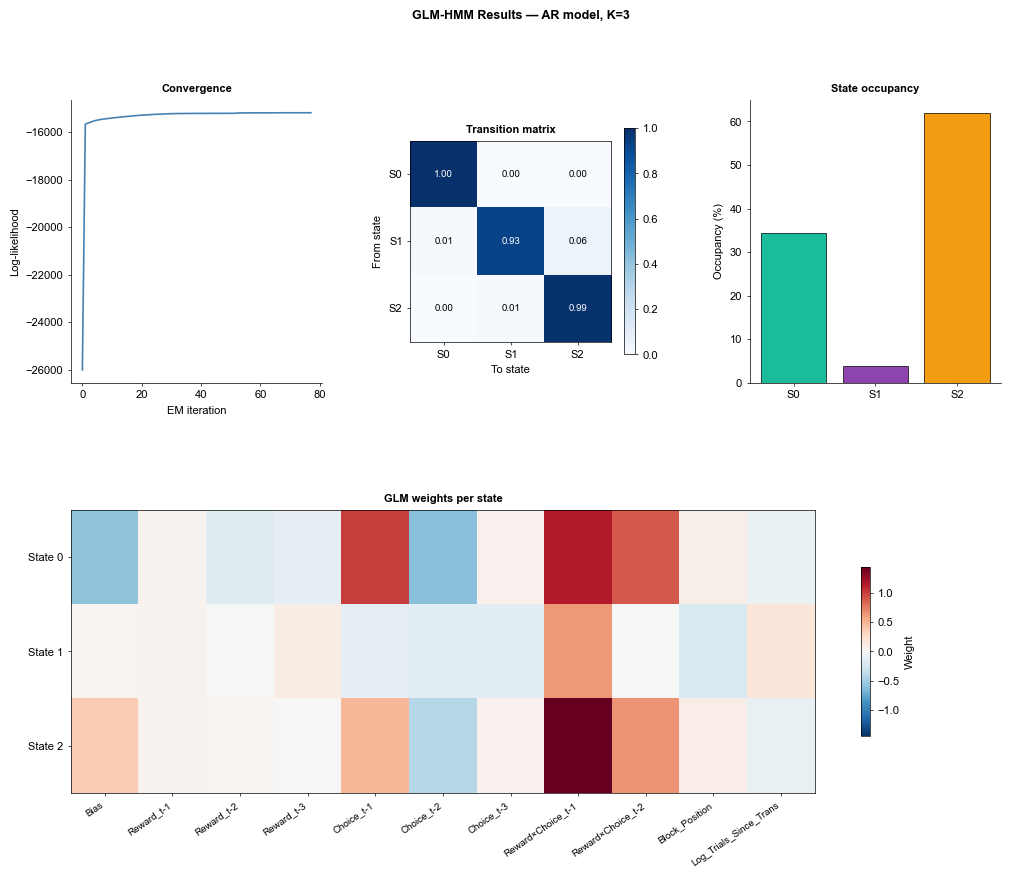

In [ ]:
# ── Figure: convergence + transition matrix + state occupancy + GLM weights ──

STATE_COLORS = [
    '#1abc9c', '#8e44ad', '#f39c12', '#7f8c8d',
    '#2980b9', '#e74c3c', '#16a085',
][:SELECTED_K]

fig = plt.figure(figsize=(12, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax_ll     = fig.add_subplot(gs[0, 0])
ax_trans  = fig.add_subplot(gs[0, 1])
ax_occ    = fig.add_subplot(gs[0, 2])
ax_w      = fig.add_subplot(gs[1, :])

# Panel A: log-likelihood convergence
ax_ll.plot(model.log_likelihood_history, color='steelblue', linewidth=1.2)
ax_ll.set_xlabel('EM iteration', fontsize=FONTSIZE)
ax_ll.set_ylabel('Log-likelihood', fontsize=FONTSIZE)
ax_ll.set_title('Convergence', fontsize=FONTSIZE, fontweight='bold')
ax_ll.spines[['top', 'right']].set_visible(False)

# Panel B: transition matrix
im = ax_trans.imshow(model.transitions, cmap='Blues', vmin=0, vmax=1)
for i in range(SELECTED_K):
    for j in range(SELECTED_K):
        ax_trans.text(j, i, f'{model.transitions[i,j]:.2f}',
                      ha='center', va='center', fontsize=FONTSIZE - 1,
                      color='black' if model.transitions[i,j] < 0.7 else 'white')
ax_trans.set_xticks(range(SELECTED_K))
ax_trans.set_yticks(range(SELECTED_K))
ax_trans.set_xticklabels([f'S{k}' for k in range(SELECTED_K)])
ax_trans.set_yticklabels([f'S{k}' for k in range(SELECTED_K)])
ax_trans.set_xlabel('To state', fontsize=FONTSIZE)
ax_trans.set_ylabel('From state', fontsize=FONTSIZE)
ax_trans.set_title('Transition matrix', fontsize=FONTSIZE, fontweight='bold')
plt.colorbar(im, ax=ax_trans, shrink=0.8)

# Panel C: state occupancy
occupancy = [(states == k).mean() * 100 for k in range(SELECTED_K)]
ax_occ.bar(range(SELECTED_K), occupancy, color=STATE_COLORS, edgecolor='black',
           linewidth=LINE_WIDTH)
ax_occ.set_xticks(range(SELECTED_K))
ax_occ.set_xticklabels([f'S{k}' for k in range(SELECTED_K)])
ax_occ.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
ax_occ.set_title('State occupancy', fontsize=FONTSIZE, fontweight='bold')
ax_occ.spines[['top', 'right']].set_visible(False)

# Panel D: GLM weights heatmap
W = model.weights  # (K, n_features)
vmax = np.abs(W).max()
im2 = ax_w.imshow(W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax_w.set_yticks(range(SELECTED_K))
ax_w.set_yticklabels([f'State {k}' for k in range(SELECTED_K)], fontsize=FONTSIZE)
ax_w.set_xticks(range(len(names_sel)))
ax_w.set_xticklabels(names_sel, fontsize=FONTSIZE - 1, rotation=35, ha='right')
ax_w.set_title('GLM weights per state', fontsize=FONTSIZE, fontweight='bold')
plt.colorbar(im2, ax=ax_w, shrink=0.6, label='Weight')

fig.suptitle(
    f'GLM-HMM Results — {SELECTED_MODEL_TYPE} model, K={SELECTED_K}',
    fontsize=FONTSIZE + 1, fontweight='bold'
)
plt.savefig(
    os.path.join(FIGURE_PATH, f'glmhmm_{SELECTED_MODEL_TYPE}_K{SELECTED_K}_summary.svg'),
    bbox_inches='tight'
)
plt.show()

In [13]:
STICKINESS = 0

In [15]:
def prepare_features_AR_v2(df):
    """
    Autoregressive feature set v2.
    Same as v1 but adds block_pos_rev as an explicit feature,
    giving the model a sharp reversal-locked signal to distinguish
    post-reversal learning from mid-block exploitation.
    
    Added feature
    -------------
    Block_Pos_Rev : trials since last reversal, normalised by 20.
                    Negative before reversal, positive after.
                    Gives model a sharp boundary signal at block transitions.
    """
    df = df.copy()

    if 'Choice_Binary' not in df.columns:
        df['Choice_Binary'] = df['PhysicalChoice'].map({
            'BottomLeft': 0, 'LeftCenter': 0, 'TopLeft': 0,
            'BottomRight': 1, 'RightCenter': 1, 'TopRight': 1,
        })
    if 'Outcome_Binary' not in df.columns:
        df['Outcome_Binary'] = df['Outcome'].astype(int)

    for n in range(1, 4):
        if f'Reward_Lag{n}' not in df.columns:
            df[f'Reward_Lag{n}'] = (
                df.groupby('Session_ID')['Outcome_Binary'].shift(n).fillna(0)
            )
        if f'Choice_Lag{n}' not in df.columns:
            df[f'Choice_Lag{n}'] = (
                df.groupby('Session_ID')['Choice_Binary'].shift(n).fillna(0)
            )

    df = _add_block_cols(df)

    features, names = [], []
    features.append(np.ones(len(df)));                       names.append('Bias')
    for n in range(1, 4):
        features.append(df[f'Reward_Lag{n}'].values);        names.append(f'Reward_t-{n}')
    for n in range(1, 4):
        features.append(df[f'Choice_Lag{n}'].values - 0.5);  names.append(f'Choice_t-{n}')
    for n in range(1, 3):
        features.append(
            df[f'Reward_Lag{n}'].values * (df[f'Choice_Lag{n}'].values - 0.5)
        )
        names.append(f'Reward×Choice_t-{n}')
    # features.append(df['Trial_in_Block'].values / 20.0);     names.append('Block_Position')
    # features.append(np.log1p(df['Trials_Since_Transition'].values))
    # names.append('Log_Trials_Since_Trans')

    # NEW: block_pos_rev normalised by 20
    if 'block_pos_rev' in df.columns:
        features.append(df['block_pos_rev'].values / 20.0)
        names.append('Block_Pos_Rev')
    else:
        print('WARNING: block_pos_rev not found in df — skipping feature')

    X           = np.column_stack(features)
    y           = df['Choice_Binary'].values
    session_ids = df['Session_ID'].values
    return X, y, session_ids, names, df


# Prepare and standardise
X_AR2, y_AR2, sess_AR2, names_AR2, df_AR2 = prepare_features_AR_v2(df)

scaler_AR2       = StandardScaler()
Xs_AR2           = X_AR2.copy()
Xs_AR2[:, 1:]    = scaler_AR2.fit_transform(X_AR2[:, 1:])

print(f'Features ({len(names_AR2)}): {names_AR2}')
print(f'block_pos_rev present: {"Block_Pos_Rev" in names_AR2}')

Features (9): ['Bias', 'Reward_t-1', 'Reward_t-2', 'Reward_t-3', 'Choice_t-1', 'Choice_t-2', 'Choice_t-3', 'Reward×Choice_t-1', 'Reward×Choice_t-2']
block_pos_rev present: False


In [16]:
# ── Refit pooled model at K=3 ─────────────────────────────────────────────────

model_k3 = GLM_HMM(
    n_states    = 3,
    n_features  = Xs_AR.shape[1],
    random_seed = RANDOM_SEED,
    stickiness  = STICKINESS,
    l2_penalty  = L2_PENALTY,
)

model_k3.fit(Xs_AR, y_AR, sess_AR, n_iter=NUM_ITER, verbose=True)
states_k3, gamma_k3 = model_k3.predict_states(Xs_AR, y_AR, sess_AR)

# Characterize
print(f'\n{"State":<8} {"N":>8} {"Accuracy":>10} {"P(Right)":>10} '
      f'{"Switch":>10} {"WinStay":>10} {"LoseSwitch":>12} {"Dwell":>8}')
print('-' * 80)

mean_dwell = 1.0 / np.maximum(1 - np.diag(model_k3.transitions), 1e-6)

for k in range(3):
    mask = states_k3 == k
    sdf  = df_AR[mask]
    acc  = sdf['High_Prob'].mean()
    pr   = sdf['Choice_Binary'].mean()
    sw   = sdf['PhysicalSwitch'].mean()
    ws   = ((sdf['Outcome_Binary'].shift(1) == 1) &
            (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean()
    ls   = ((sdf['Outcome_Binary'].shift(1) == 0) &
            (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean()
    print(f'  {k:<6} {mask.sum():>8,} {acc:>10.3f} {pr:>10.3f} '
          f'{sw:>10.3f} {ws:>10.3f} {ls:>12.3f} {mean_dwell[k]:>8.1f}')

print(f'\nAnimal breakdown per state:')
for k in range(3):
    mask = states_k3 == k
    print(f'\nState {k}:')
    print(df_AR[mask]['Animal_Name'].value_counts().to_string())

  K=3 | Features=11 | Trials=36,673 | Sessions=100
    Iter  10/100 | LL:   -15409.5 (Δ+15.9) | Dwell: [61.5 11.5 20.4]
    Iter  20/100 | LL:   -15285.5 (Δ+10.3) | Dwell: [83.  13.9 71.8]
    Iter  30/100 | LL:   -15217.1 (Δ+4.8) | Dwell: [169.9  15.2 259.1]
    Iter  40/100 | LL:   -15200.2 (Δ+0.5) | Dwell: [280.4  15.9 338. ]
    Iter  50/100 | LL:   -15196.9 (Δ+0.3) | Dwell: [351.6  15.4 258.8]
    Iter  60/100 | LL:   -15176.4 (Δ+0.4) | Dwell: [389.3  15.1 184. ]
    Iter  70/100 | LL:   -15174.0 (Δ+0.2) | Dwell: [435.1  14.4 140.2]
    Converged at iteration 77
    Final LL: -15173.1 | BIC: 30756.1

State           N   Accuracy   P(Right)     Switch    WinStay   LoseSwitch    Dwell
--------------------------------------------------------------------------------
  0        12,586      0.703      0.351      0.142      0.560        0.102    456.5
  1         1,403      0.659      0.527      0.490      0.298        0.266     14.0
  2        22,684      0.676      0.579      0.195    

In [21]:
# Fast state occupancy from K=3 pooled model
# import the spearmanr function
from scipy.stats import spearmanr

fast_occ_k3 = {}
for animal in animal_ages_df['Animal_Name']:
    if animal not in df_AR['Animal_Name'].values:
        continue
    mask = (states_k3 == 1) & (df_AR['Animal_Name'] == animal)
    fast_occ_k3[animal] = mask.sum() / (df_AR['Animal_Name'] == animal).sum() * 100

summary_k3 = animal_ages_df[animal_ages_df['Animal_Name'].isin(fast_occ_k3)].copy()
summary_k3['fast_occ'] = summary_k3['Animal_Name'].map(fast_occ_k3)
summary_k3 = summary_k3.sort_values('Age_Years')

print(summary_k3[['Animal_Name', 'Age_Years', 'fast_occ']])

r, p = spearmanr(summary_k3['Age_Years'], summary_k3['fast_occ'])
print(f'\nSpearman r = {r:.3f}, p = {p:.3f}')

  Animal_Name  Age_Years  fast_occ
1    Knuckles   1.363450  4.443439
2       Sonic   1.401780  3.165528
3   Sunflower   2.488706  5.330512
4        Zazu   5.037645  2.784504
0       Fiona   6.184805  1.225115

Spearman r = -0.700, p = 0.188


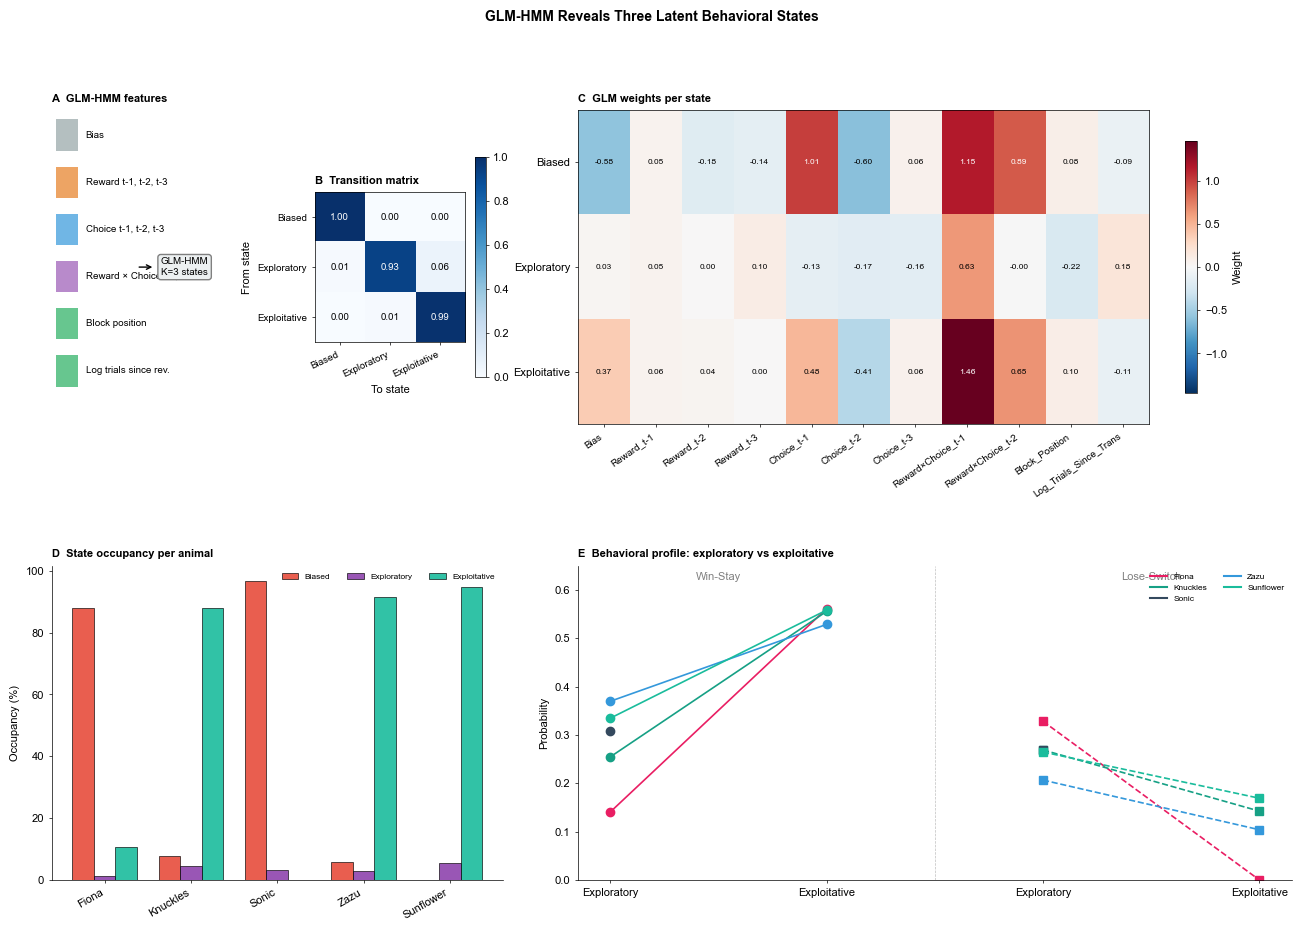

In [22]:
# ── Main figure: GLM-HMM K=3 pooled model ────────────────────────────────────

STATE_NAMES  = {0: 'Biased', 1: 'Exploratory', 2: 'Exploitative'}
STATE_COLORS_K3 = {
    0: '#e74c3c',   # red  — biased
    1: '#8e44ad',   # purple — exploratory
    2: '#1abc9c',   # teal — exploitative
}

animals_ordered = [a for a in ANIMAL_ORDER if a in df_AR['Animal_Name'].values]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(
    2, 5,
    figure     = fig,
    hspace     = 0.45,
    wspace     = 0.4,
    height_ratios = [1, 1],
)

ax_schem  = fig.add_subplot(gs[0, 0])     # A: feature schematic
ax_trans  = fig.add_subplot(gs[0, 1])     # B: transition matrix
ax_weights = fig.add_subplot(gs[0, 2:])   # C: GLM weights (wide)
ax_occ    = fig.add_subplot(gs[1, 0:2])   # D: occupancy per animal
ax_wsls   = fig.add_subplot(gs[1, 2:])    # E: win-stay / lose-switch

# ── Panel A: Feature schematic ────────────────────────────────────────────────
ax = ax_schem
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('A  GLM-HMM features', fontsize=FONTSIZE, fontweight='bold', loc='left')

feature_groups = [
    ('Bias',                  '#95a5a6'),
    ('Reward t-1, t-2, t-3',  '#e67e22'),
    ('Choice t-1, t-2, t-3',  '#3498db'),
    ('Reward × Choice t-1,2', '#9b59b6'),
    ('Block position',        '#27ae60'),
    ('Log trials since rev.', '#27ae60'),
]

for i, (label, color) in enumerate(feature_groups):
    y = 0.92 - i * 0.15
    ax.add_patch(plt.Rectangle((0.02, y - 0.05), 0.12, 0.10,
                                facecolor=color, alpha=0.7, edgecolor='none'))
    ax.text(0.18, y, label, va='center', fontsize=FONTSIZE - 1)

ax.annotate('', xy=(0.55, 0.5), xytext=(0.45, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax.text(0.58, 0.5, 'GLM-HMM\nK=3 states', va='center', fontsize=FONTSIZE - 1,
        bbox=dict(facecolor='#ecf0f1', edgecolor='gray', boxstyle='round'))

# ── Panel B: Transition matrix ────────────────────────────────────────────────
ax = ax_trans
ax.set_title('B  Transition matrix', fontsize=FONTSIZE, fontweight='bold', loc='left')

T    = model_k3.transitions
im   = ax.imshow(T, cmap='Blues', vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{T[i,j]:.2f}', ha='center', va='center',
                fontsize=FONTSIZE - 1,
                color='white' if T[i,j] > 0.6 else 'black')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([STATE_NAMES[k] for k in range(3)],
                   rotation=25, ha='right', fontsize=FONTSIZE - 1)
ax.set_yticklabels([STATE_NAMES[k] for k in range(3)], fontsize=FONTSIZE - 1)
ax.set_xlabel('To state', fontsize=FONTSIZE)
ax.set_ylabel('From state', fontsize=FONTSIZE)
plt.colorbar(im, ax=ax, shrink=0.7)

# ── Panel C: GLM weights heatmap ──────────────────────────────────────────────
ax = ax_weights
ax.set_title('C  GLM weights per state', fontsize=FONTSIZE, fontweight='bold', loc='left')

W    = model_k3.weights   # (3, n_features)
vmax = np.abs(W).max()
im2  = ax.imshow(W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_yticks(range(3))
ax.set_yticklabels([STATE_NAMES[k] for k in range(3)], fontsize=FONTSIZE)
ax.set_xticks(range(len(names_AR)))
ax.set_xticklabels(names_AR, rotation=35, ha='right', fontsize=FONTSIZE - 1)
plt.colorbar(im2, ax=ax, shrink=0.8, label='Weight')

# Add values
for i in range(3):
    for j in range(len(names_AR)):
        ax.text(j, i, f'{W[i,j]:.2f}', ha='center', va='center',
                fontsize=FONTSIZE - 2,
                color='white' if abs(W[i,j]) > vmax * 0.6 else 'black')

# ── Panel D: State occupancy per animal ───────────────────────────────────────
ax = ax_occ
ax.set_title('D  State occupancy per animal', fontsize=FONTSIZE, fontweight='bold', loc='left')

x     = np.arange(len(animals_ordered))
width = 0.25

for ki, (k, name) in enumerate(STATE_NAMES.items()):
    occs = []
    for animal in animals_ordered:
        mask = (states_k3 == k) & (df_AR['Animal_Name'] == animal)
        total = (df_AR['Animal_Name'] == animal).sum()
        occs.append(mask.sum() / total * 100)

    ax.bar(x + (ki - 1) * width, occs, width,
           label=name, color=STATE_COLORS_K3[k],
           edgecolor='black', linewidth=LINE_WIDTH, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE)
ax.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
ax.legend(fontsize=FONTSIZE - 2, frameon=False, ncol=3)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel E: Win-stay / Lose-switch for exploratory vs exploitative ───────────
ax = ax_wsls
ax.set_title('E  Behavioral profile: exploratory vs exploitative',
             fontsize=FONTSIZE, fontweight='bold', loc='left')

for animal in animals_ordered:
    vals = {}
    for k, label in [(1, 'exploratory'), (2, 'exploitative')]:
        mask = (states_k3 == k) & (df_AR['Animal_Name'] == animal)
        sdf  = df_AR[mask]
        vals[label] = {
            'ws': ((sdf['Outcome_Binary'].shift(1) == 1) &
                   (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean(),
            'ls': ((sdf['Outcome_Binary'].shift(1) == 0) &
                   (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean(),
        }

    color = ANIMAL_COLORS.get(animal, 'gray')

    # Win-stay
    ax.plot([0, 1], [vals['exploratory']['ws'], vals['exploitative']['ws']],
            'o-', color=color, linewidth=1.2, markersize=6)

    # Lose-switch
    ax.plot([2, 3], [vals['exploratory']['ls'], vals['exploitative']['ls']],
            's--', color=color, linewidth=1.2, markersize=6)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Exploratory', 'Exploitative',
                    'Exploratory', 'Exploitative'], fontsize=FONTSIZE)
ax.set_ylabel('Probability', fontsize=FONTSIZE)
ax.set_ylim(0, 0.65)
ax.axvline(1.5, color='gray', linewidth=0.5, ls='--', alpha=0.5)
ax.text(0.5, 0.62, 'Win-Stay', ha='center', fontsize=FONTSIZE, color='gray')
ax.text(2.5, 0.62, 'Lose-Switch', ha='center', fontsize=FONTSIZE, color='gray')
ax.spines[['top', 'right']].set_visible(False)

# Animal legend
handles = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                      linewidth=1.5, label=a) for a in animals_ordered]
ax.legend(handles=handles, fontsize=FONTSIZE - 2, frameon=False,
          loc='upper right', ncol=2)

fig.suptitle('GLM-HMM Reveals Three Latent Behavioral States',
             fontsize=FONTSIZE + 2, fontweight='bold')

plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_glmhmm_k3.svg'), bbox_inches='tight')
plt.show()

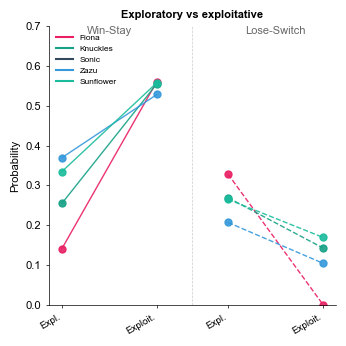

In [23]:
# ── Panel E only — redesign ───────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(3.5, 3.5))

metrics = ['Win-Stay', 'Lose-Switch']
x_pos   = {'Win-Stay': 0, 'Lose-Switch': 1}

for animal in animals_ordered:
    vals = {}
    for k, label in [(1, 'exploratory'), (2, 'exploitative')]:
        mask = (states_k3 == k) & (df_AR['Animal_Name'] == animal)
        sdf  = df_AR[mask]
        if len(sdf) < 20:
            continue
        vals[label] = {
            'ws': ((sdf['Outcome_Binary'].shift(1) == 1) &
                   (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean(),
            'ls': ((sdf['Outcome_Binary'].shift(1) == 0) &
                   (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean(),
        }

    if 'exploratory' not in vals or 'exploitative' not in vals:
        continue

    color = ANIMAL_COLORS.get(animal, 'gray')

    # Win-stay: dot for each state, connected
    ax.plot([0, 0.4], [vals['exploratory']['ws'], vals['exploitative']['ws']],
            'o-', color=color, linewidth=1, markersize=5, alpha=0.9)

    # Lose-switch: offset to right
    ax.plot([0.7, 1.1], [vals['exploratory']['ls'], vals['exploitative']['ls']],
            'o--', color=color, linewidth=1, markersize=5, alpha=0.9)

# Labels
ax.set_xticks([0, 0.4, 0.7, 1.1])
ax.set_xticklabels(['Expl.', 'Exploit.', 'Expl.', 'Exploit.'],
                   fontsize=FONTSIZE - 1, rotation=30, ha='right')
ax.set_ylabel('Probability', fontsize=FONTSIZE)
ax.set_ylim(0, 0.7)

# Group labels above
ax.text(0.2,  0.68, 'Win-Stay',    ha='center', fontsize=FONTSIZE, color='dimgray')
ax.text(0.9,  0.68, 'Lose-Switch', ha='center', fontsize=FONTSIZE, color='dimgray')
ax.axvline(0.55, color='gray', linewidth=0.5, ls='--', alpha=0.4)

# Animal legend
handles = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                      linewidth=1.5, label=a) for a in animals_ordered
           if a in df_AR['Animal_Name'].values]
ax.legend(handles=handles, fontsize=FONTSIZE - 2, frameon=False,
          loc='upper left', ncol=1)

ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Exploratory vs exploitative', fontsize=FONTSIZE, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'panel_E_wsls.svg'), bbox_inches='tight')
plt.show()

KeyError: 'GLM_HMM_State'

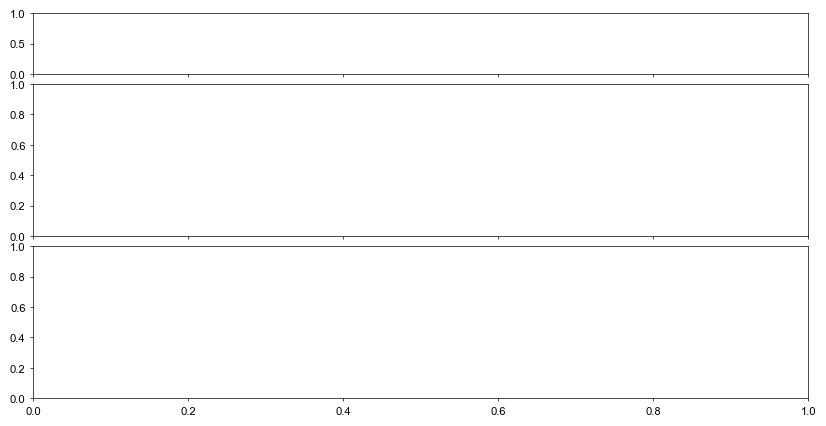

In [24]:
# ── Figure: example session state sequence ────────────────────────────────────
# Shows Viterbi state assignments alongside rolling accuracy for one session.

example_session = df['Session_ID'].iloc[0]   # change as needed

sdf = df[df['Session_ID'] == example_session].sort_values('Trial').reset_index(drop=True)
animal = sdf['Animal_Name'].iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True,
                         gridspec_kw={'height_ratios': [0.4, 1, 1], 'hspace': 0.08})

# State sequence raster
ax = axes[0]
for i, (_, row) in enumerate(sdf.iterrows()):
    k = row['GLM_HMM_State']
    ax.barh(0, 1, left=i, color=STATE_COLORS[int(k)], height=0.8, edgecolor='none')
ax.set_xlim(0, len(sdf))
ax.set_yticks([])
ax.set_ylabel('State', fontsize=FONTSIZE, rotation=0, ha='right', va='center')
ax.spines[['top','right','bottom','left']].set_visible(False)

# Posterior probabilities
ax = axes[1]
gamma_sdf = gamma[sdf.index]
for k in range(SELECTED_K):
    ax.plot(gamma_sdf[:, k], color=STATE_COLORS[k], linewidth=0.8,
            alpha=0.85, label=f'State {k}')
ax.set_ylim(0, 1)
ax.set_ylabel('P(state)', fontsize=FONTSIZE)
ax.legend(fontsize=FONTSIZE - 2, frameon=False, ncol=SELECTED_K,
          loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

# Rolling accuracy
ax = axes[2]
rolling_acc = sdf['High_Prob'].rolling(10, min_periods=3).mean()
ax.plot(rolling_acc, color='#2c3e50', linewidth=0.9)
ax.axhline(0.8, color='gray', ls='--', lw=0.5, alpha=0.6)
ax.axhline(0.5, color='gray', ls=':',  lw=0.5, alpha=0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Rolling accuracy', fontsize=FONTSIZE)
ax.set_xlabel('Trial', fontsize=FONTSIZE)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    f'Example session: {animal} | {example_session}',
    fontsize=FONTSIZE, fontweight='bold'
)
plt.savefig(
    os.path.join(FIGURE_PATH, f'glmhmm_example_session.svg'),
    bbox_inches='tight'
)
plt.show()

In [25]:
for k in [0, 2]:
    mask = states == k
    sdf  = df[mask]
    print(f"\nState {k}:")
    print(f"  P(High_Prob)     : {sdf['High_Prob'].mean():.3f}")
    print(f"  P(Right)         : {sdf['Choice_Binary'].mean():.3f}")
    print(f"  Switch rate      : {sdf['PhysicalSwitch'].mean():.3f}")
    print(f"  P(Win-Stay)      : {((sdf['Outcome_Binary'].shift(1)==1) & (sdf['Choice_Binary']==sdf['Choice_Binary'].shift(1))).mean():.3f}")
    print(f"  P(Lose-Switch)   : {((sdf['Outcome_Binary'].shift(1)==0) & (sdf['Choice_Binary']!=sdf['Choice_Binary'].shift(1))).mean():.3f}")
    print(f"  Animal breakdown :")
    print(sdf['Animal_Name'].value_counts().to_string())

NameError: name 'states' is not defined

In [27]:
# ============================================================================
# PER-ANIMAL GLM-HMM FITTING WITH MODEL SELECTION (K = 2–4)
# ============================================================================

K_RANGE_ANIMAL  = range(2, 4)   # K = 2, 3, 4
STICKINESS_ANIM = 5
L2_PENALTY_ANIM = 1.0
NUM_ITER_ANIM   = 100

# Results structure:
# animal_results[animal]['selection'][K] = {'model', 'states', 'gamma', 'bic', 'll'}
# animal_results[animal]['best']         = {'K', 'model', 'states', 'gamma'}

animal_results = {}

for animal in df['Animal_Name'].unique():
    print(f'\n{"="*60}')
    print(f'Animal: {animal}')
    print(f'{"="*60}')

    df_anim = df[df['Animal_Name'] == animal].copy()

    # Prepare AR features for this animal only
    X_a, y_a, sess_a, names_a, df_a = prepare_features_AR(df_anim)
    scaler_a      = StandardScaler()
    Xs_a          = X_a.copy()
    Xs_a[:, 1:]   = scaler_a.fit_transform(X_a[:, 1:])

    print(f'  Trials: {len(y_a):,} | Sessions: {df_anim["Session_ID"].nunique()}')

    animal_results[animal] = {'selection': {}, 'best': None}

    for K in K_RANGE_ANIMAL:
        print(f'\n  Fitting K={K}...')
        model_k = GLM_HMM(
            n_states    = K,
            n_features  = Xs_a.shape[1],
            random_seed = RANDOM_SEED,
            stickiness  = STICKINESS_ANIM,
            l2_penalty  = L2_PENALTY_ANIM,
        )
        model_k.fit(Xs_a, y_a, sess_a, n_iter=NUM_ITER_ANIM, verbose=True)
        states_k, gamma_k = model_k.predict_states(Xs_a, y_a, sess_a)

        animal_results[animal]['selection'][K] = {
            'model'  : model_k,
            'states' : states_k,
            'gamma'  : gamma_k,
            'bic'    : model_k.bic,
            'll forge'    : model_k.final_ll,
            'X'      : Xs_a,
            'y'      : y_a,
            'sess'   : sess_a,
            'df'     : df_a,
        }

    # Select best K by BIC
    best_K = min(K_RANGE_ANIMAL, key=lambda K: animal_results[animal]['selection'][K]['bic'])
    animal_results[animal]['best'] = {
        'K'     : best_K,
        **animal_results[animal]['selection'][best_K],
    }

    print(f'\n  BIC summary:')
    for K in K_RANGE_ANIMAL:
        marker = ' ← best' if K == best_K else ''
        print(f'    K={K}: BIC={animal_results[animal]["selection"][K]["bic"]:.1f}{marker}')

print('\nPer-animal fitting complete.')


Animal: Fiona
  Trials: 5,224 | Sessions: 14

  Fitting K=2...
  K=2 | Features=11 | Trials=5,224 | Sessions=14
    Iter  10/100 | LL:    -1503.4 (Δ+0.5) | Dwell: [96.  16.2]
    Iter  20/100 | LL:    -1501.4 (Δ+0.1) | Dwell: [154.1  25. ]
    Converged at iteration 20
    Final LL: -1501.4 | BIC: 3208.3

  Fitting K=3...
  K=3 | Features=11 | Trials=5,224 | Sessions=14
    Iter  10/100 | LL:    -1476.9 (Δ+5.5) | Dwell: [104.7  11.1  39.1]
    Iter  20/100 | LL:    -1371.6 (Δ+0.5) | Dwell: [1.000e+06 1.250e+01 3.821e+02]
    Converged at iteration 21
    Final LL: -1371.5 | BIC: 3076.9

  BIC summary:
    K=2: BIC=3208.3
    K=3: BIC=3076.9 ← best

Animal: Knuckles
  Trials: 11,050 | Sessions: 23

  Fitting K=2...
  K=2 | Features=11 | Trials=11,050 | Sessions=23
    Iter  10/100 | LL:    -4844.0 (Δ+1.1) | Dwell: [43.4 10.5]
    Iter  20/100 | LL:    -4839.5 (Δ+0.3) | Dwell: [41.3  8.5]
    Iter  30/100 | LL:    -4837.7 (Δ+0.1) | Dwell: [40.1  7.5]
    Converged at iteration 34
    Fi

In [28]:
# ── Append per-animal state assignments to df ─────────────────────────────────

df['GLM_HMM_Animal_State']      = np.nan
df['GLM_HMM_Animal_State_Prob'] = np.nan
df['GLM_HMM_Animal_K']          = np.nan

for animal, res in animal_results.items():
    best      = res['best']
    df_a      = best['df']
    states_a  = best['states']
    gamma_a   = best['gamma']

    idx = df_a.index
    df.loc[idx, 'GLM_HMM_Animal_State']      = states_a
    df.loc[idx, 'GLM_HMM_Animal_State_Prob'] = gamma_a.max(axis=1)
    df.loc[idx, 'GLM_HMM_Animal_K']          = best['K']

print('State assignments added to df.')
print(df.groupby('Animal_Name')['GLM_HMM_Animal_K'].first())

State assignments added to df.
Animal_Name
Fiona        3.0
Knuckles     2.0
Sonic        2.0
Sunflower    2.0
Zazu         2.0
Name: GLM_HMM_Animal_K, dtype: float64


In [29]:
# ── Per-animal state characterization ────────────────────────────────────────

for animal, res in animal_results.items():
    best    = res['best']
    K       = best['K']
    states_a = best['states']
    gamma_a  = best['gamma']
    df_a     = best['df']
    model_a  = best['model']

    print(f'\n{"="*60}')
    print(f'Animal: {animal} | Best K={K}')
    print(f'{"="*60}')
    print(f'{"State":<8} {"N":>8} {"Accuracy":>10} {"P(Right)":>10} '
          f'{"Switch":>10} {"WinStay":>10} {"LoseSwitch":>12} {"Dwell":>8}')
    print('-' * 80)

    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)

    for k in range(K):
        mask = states_a == k
        sdf  = df_a[mask]
        if len(sdf) < 10:
            continue

        acc  = sdf['High_Prob'].mean()
        pr   = sdf['Choice_Binary'].mean()
        sw   = sdf['PhysicalSwitch'].mean()
        ws   = ((sdf['Outcome_Binary'].shift(1) == 1) &
                (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean()
        ls   = ((sdf['Outcome_Binary'].shift(1) == 0) &
                (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean()

        print(f'  {k:<6} {mask.sum():>8,} {acc:>10.3f} {pr:>10.3f} '
              f'{sw:>10.3f} {ws:>10.3f} {ls:>12.3f} {mean_dwell[k]:>8.1f}')


Animal: Fiona | Best K=3
State           N   Accuracy   P(Right)     Switch    WinStay   LoseSwitch    Dwell
--------------------------------------------------------------------------------
  0           965      0.651      0.572      0.000      0.583        0.000 1000000.0
  1           176      0.545      0.330      0.420      0.312        0.278     12.6
  2         4,083      0.725      0.414      0.121      0.592        0.090    377.2

Animal: Knuckles | Best K=2
State           N   Accuracy   P(Right)     Switch    WinStay   LoseSwitch    Dwell
--------------------------------------------------------------------------------
  0        10,185      0.670      0.538      0.179      0.569        0.135     39.8
  1           865      0.675      0.420      0.532      0.239        0.262      7.2

Animal: Sonic | Best K=2
State           N   Accuracy   P(Right)     Switch    WinStay   LoseSwitch    Dwell
--------------------------------------------------------------------------------
  0

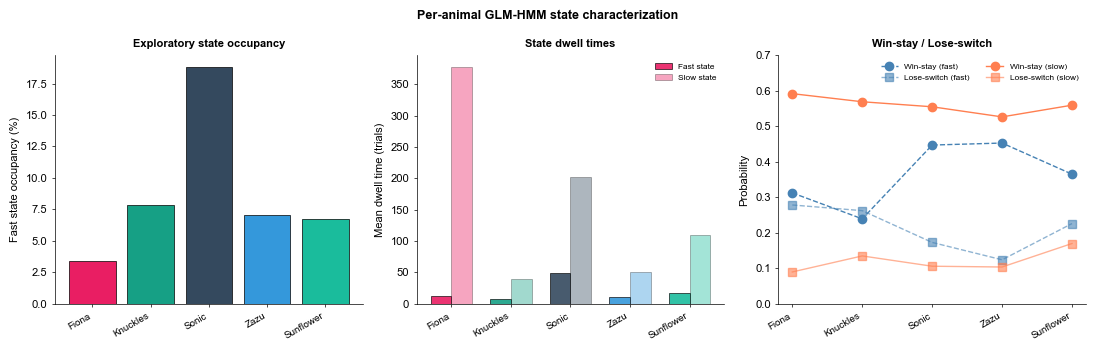

In [32]:
# ── Figure: per-animal state summary ─────────────────────────────────────────

def get_fast_slow_states(model_a, K, max_dwell=500):
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    valid_states = [k for k in range(K) if mean_dwell[k] < max_dwell]
    if len(valid_states) == 0:
        valid_states = list(range(K))
    fast_state = min(valid_states, key=lambda k: mean_dwell[k])
    slow_state = max(valid_states, key=lambda k: mean_dwell[k])
    return fast_state, slow_state, mean_dwell

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
animals_ordered = [a for a in ANIMAL_ORDER if a in animal_results]

# ── Panel A: Fast state occupancy ────────────────────────────────────────────
ax = axes[0]
fast_occupancy = []
for animal in animals_ordered:
    best     = animal_results[animal]['best']
    states_a = best['states']
    model_a  = best['model']
    K        = best['K']
    fast_state, slow_state, mean_dwell = get_fast_slow_states(model_a, K)
    occ = (states_a == fast_state).mean() * 100
    fast_occupancy.append(occ)

ax.bar(animals_ordered, fast_occupancy,
       color=[ANIMAL_COLORS.get(a, 'gray') for a in animals_ordered],
       edgecolor='black', linewidth=LINE_WIDTH)
ax.set_ylabel('Fast state occupancy (%)', fontsize=FONTSIZE)
ax.set_title('Exploratory state occupancy', fontsize=FONTSIZE, fontweight='bold')
ax.set_xticks(range(len(animals_ordered)))
ax.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE-1)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: Fast vs slow dwell time ─────────────────────────────────────────
ax = axes[1]
fast_dwell_list = []
slow_dwell_list = []
for animal in animals_ordered:
    best    = animal_results[animal]['best']
    model_a = best['model']
    K       = best['K']
    fast_state, slow_state, mean_dwell = get_fast_slow_states(model_a, K)
    fast_dwell_list.append(mean_dwell[fast_state])
    slow_dwell_list.append(mean_dwell[slow_state])

x = np.arange(len(animals_ordered))
w = 0.35
ax.bar(x - w/2, fast_dwell_list, width=w, label='Fast state',
       color=[ANIMAL_COLORS.get(a, 'gray') for a in animals_ordered],
       edgecolor='black', linewidth=LINE_WIDTH, alpha=0.9)
ax.bar(x + w/2, slow_dwell_list, width=w, label='Slow state',
       color=[ANIMAL_COLORS.get(a, 'gray') for a in animals_ordered],
       edgecolor='black', linewidth=LINE_WIDTH, alpha=0.4)
ax.set_ylabel('Mean dwell time (trials)', fontsize=FONTSIZE)
ax.set_title('State dwell times', fontsize=FONTSIZE, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE-1)
ax.legend(fontsize=FONTSIZE-2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: Win-stay / Lose-switch ──────────────────────────────────────────
ax = axes[2]
ws_fast, ls_fast = [], []
ws_slow, ls_slow = [], []

for animal in animals_ordered:
    best     = animal_results[animal]['best']
    states_a = best['states']
    model_a  = best['model']
    df_a     = best['df']
    K        = best['K']
    fast_state, slow_state, mean_dwell = get_fast_slow_states(model_a, K)

    for state, ws_list, ls_list in [(fast_state, ws_fast, ls_fast),
                                     (slow_state, ws_slow, ls_slow)]:
        mask = states_a == state
        sdf  = df_a[mask]
        ws   = ((sdf['Outcome_Binary'].shift(1) == 1) &
                (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean()
        ls   = ((sdf['Outcome_Binary'].shift(1) == 0) &
                (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean()
        ws_list.append(ws)
        ls_list.append(ls)

x = np.arange(len(animals_ordered))
ax.plot(x, ws_fast, 'o--', color='steelblue', label='Win-stay (fast)', linewidth=1)
ax.plot(x, ls_fast, 's--', color='steelblue', label='Lose-switch (fast)',
        linewidth=1, alpha=0.6)
ax.plot(x, ws_slow, 'o-', color='coral', label='Win-stay (slow)', linewidth=1)
ax.plot(x, ls_slow, 's-', color='coral', label='Lose-switch (slow)',
        linewidth=1, alpha=0.6)
ax.set_ylabel('Probability', fontsize=FONTSIZE)
ax.set_title('Win-stay / Lose-switch', fontsize=FONTSIZE, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE-1)
ax.set_ylim(0, 0.7)
ax.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Per-animal GLM-HMM state characterization',
             fontsize=FONTSIZE+1, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'per_animal_state_summary.svg'),
            bbox_inches='tight')
plt.show()

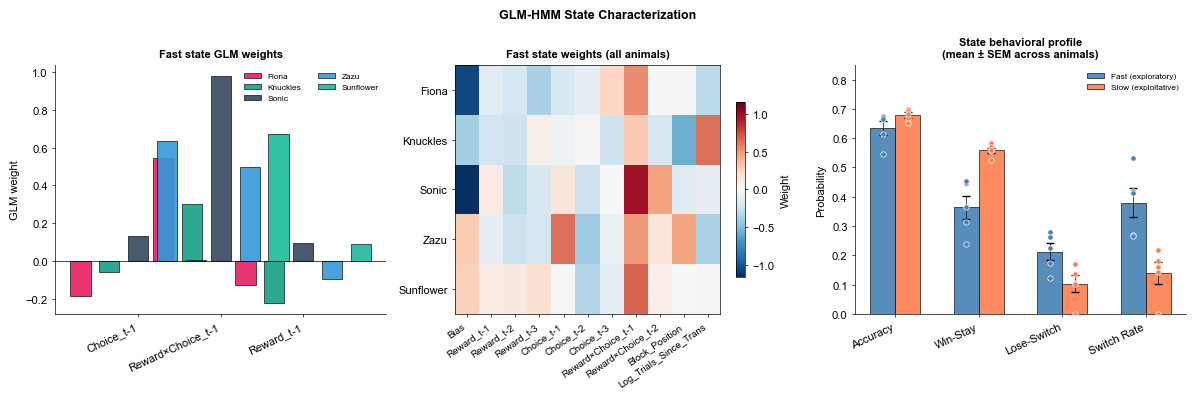

In [33]:
# ── Figure: GLM weights + state characterization for main figure ──────────────

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

animals_ordered = [a for a in ANIMAL_ORDER if a in animal_results]

# ── Panel A: GLM weights for fast vs slow state per animal ────────────────────
# Show key weights: Choice_t-1, Reward×Choice_t-1, Reward_t-1
ax = axes[0]

key_features = ['Choice_t-1', 'Reward×Choice_t-1', 'Reward_t-1']
feature_idx  = [names_AR.index(f) for f in key_features]

x      = np.arange(len(key_features))
width  = 0.35
offset = np.linspace(-width * 2, width * 2, len(animals_ordered))

for i, animal in enumerate(animals_ordered):
    best       = animal_results[animal]['best']
    model_a    = best['model']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)

    w_fast = model_a.weights[fast_state, feature_idx]
    ax.bar(x + offset[i], w_fast, width=width * 0.7,
           color=ANIMAL_COLORS.get(animal, 'gray'),
           edgecolor='black', linewidth=LINE_WIDTH,
           label=animal, alpha=0.9)

ax.axhline(0, color='black', linewidth=LINE_WIDTH)
ax.set_xticks(x)
ax.set_xticklabels(key_features, rotation=25, ha='right', fontsize=FONTSIZE)
ax.set_ylabel('GLM weight', fontsize=FONTSIZE)
ax.set_title('Fast state GLM weights', fontsize=FONTSIZE, fontweight='bold')
ax.legend(fontsize=FONTSIZE - 2, frameon=False, ncol=2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: GLM weight heatmap — fast state across animals ───────────────────
ax = axes[1]

all_features = names_AR
weight_matrix = np.zeros((len(animals_ordered), len(all_features)))

for i, animal in enumerate(animals_ordered):
    best       = animal_results[animal]['best']
    model_a    = best['model']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    weight_matrix[i] = model_a.weights[fast_state]

vmax = np.abs(weight_matrix).max()
im   = ax.imshow(weight_matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_yticks(range(len(animals_ordered)))
ax.set_yticklabels(animals_ordered, fontsize=FONTSIZE)
ax.set_xticks(range(len(all_features)))
ax.set_xticklabels(all_features, rotation=35, ha='right', fontsize=FONTSIZE - 1)
ax.set_title('Fast state weights (all animals)', fontsize=FONTSIZE, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7, label='Weight')

# ── Panel C: Behavioral characterization — fast vs slow state ────────────────
ax = axes[2]

metrics      = ['Accuracy', 'Win-Stay', 'Lose-Switch', 'Switch Rate']
fast_vals    = {m: [] for m in metrics}
slow_vals    = {m: [] for m in metrics}

for animal in animals_ordered:
    best       = animal_results[animal]['best']
    states_a   = best['states']
    model_a    = best['model']
    df_a       = best['df']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    slow_state = np.argmax(np.clip(mean_dwell, 0, 1000))

    for state, d in [(fast_state, fast_vals), (slow_state, slow_vals)]:
        mask = states_a == state
        sdf  = df_a[mask]
        d['Accuracy'].append(sdf['High_Prob'].mean())
        d['Win-Stay'].append(
            ((sdf['Outcome_Binary'].shift(1) == 1) &
             (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean()
        )
        d['Lose-Switch'].append(
            ((sdf['Outcome_Binary'].shift(1) == 0) &
             (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean()
        )
        d['Switch Rate'].append(sdf['PhysicalSwitch'].mean())

x     = np.arange(len(metrics))
width = 0.3

fast_means = [np.mean(fast_vals[m]) for m in metrics]
slow_means = [np.mean(slow_vals[m]) for m in metrics]
fast_sems  = [sem(fast_vals[m])     for m in metrics]
slow_sems  = [sem(slow_vals[m])     for m in metrics]

ax.bar(x - width/2, fast_means, width, yerr=fast_sems,
       color='steelblue', edgecolor='black', linewidth=LINE_WIDTH,
       capsize=3, label='Fast (exploratory)', alpha=0.9)
ax.bar(x + width/2, slow_means, width, yerr=slow_sems,
       color='coral', edgecolor='black', linewidth=LINE_WIDTH,
       capsize=3, label='Slow (exploitative)', alpha=0.9)

# overlay individual animals as dots
for i, m in enumerate(metrics):
    for v in fast_vals[m]:
        ax.scatter(i - width/2, v, color='steelblue', s=15, zorder=5,
                   edgecolors='white', linewidths=0.5)
    for v in slow_vals[m]:
        ax.scatter(i + width/2, v, color='coral', s=15, zorder=5,
                   edgecolors='white', linewidths=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=25, ha='right', fontsize=FONTSIZE)
ax.set_ylabel('Probability', fontsize=FONTSIZE)
ax.set_ylim(0, 0.85)
ax.set_title('State behavioral profile\n(mean ± SEM across animals)',
             fontsize=FONTSIZE, fontweight='bold')
ax.legend(fontsize=FONTSIZE - 2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('GLM-HMM State Characterization', fontsize=FONTSIZE + 1, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_state_characterization.svg'),
            bbox_inches='tight')
plt.show()

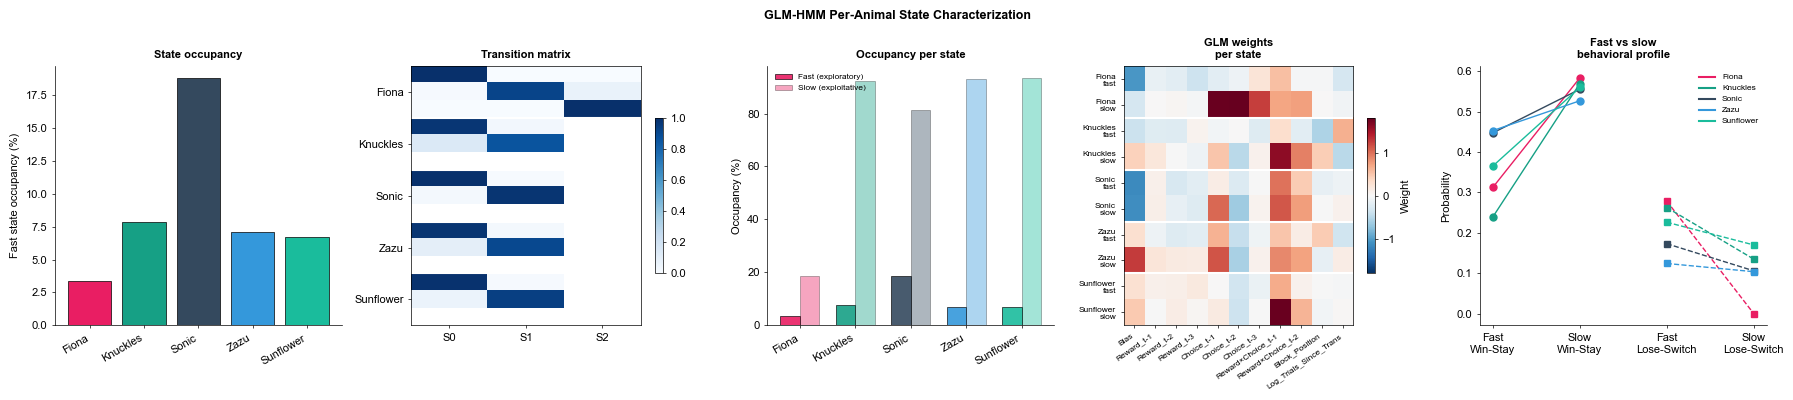

In [34]:
# ── Main figure: per-animal GLM-HMM characterization ─────────────────────────

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

animals_ordered = [a for a in ANIMAL_ORDER if a in animal_results]

# ── Panel 1: Overall fast state occupancy per animal ─────────────────────────
ax = axes[0]

for i, animal in enumerate(animals_ordered):
    best       = animal_results[animal]['best']
    states_a   = best['states']
    model_a    = best['model']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    occ        = (states_a == fast_state).mean() * 100
    ax.bar(i, occ, color=ANIMAL_COLORS.get(animal, 'gray'),
           edgecolor='black', linewidth=LINE_WIDTH)

ax.set_xticks(range(len(animals_ordered)))
ax.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE)
ax.set_ylabel('Fast state occupancy (%)', fontsize=FONTSIZE)
ax.set_title('State occupancy', fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: Transition matrix — one per animal tiled ────────────────────────
ax = axes[1]

# Stack all animals' transition matrices vertically as a single heatmap
n_animals = len(animals_ordered)
max_K     = max(animal_results[a]['best']['K'] for a in animals_ordered)

# Build a block matrix: each animal is a K×K block
block_size = max_K
full_mat   = np.full((n_animals * block_size, block_size), np.nan)

for i, animal in enumerate(animals_ordered):
    best   = animal_results[animal]['best']
    K      = best['K']
    T      = best['model'].transitions
    full_mat[i * block_size: i * block_size + K, :K] = T

im = ax.imshow(full_mat, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_yticks([i * block_size + block_size/2 - 0.5 for i in range(n_animals)])
ax.set_yticklabels(animals_ordered, fontsize=FONTSIZE)
ax.set_xticks(range(block_size))
ax.set_xticklabels([f'S{k}' for k in range(block_size)], fontsize=FONTSIZE)
ax.set_title('Transition matrix', fontsize=FONTSIZE, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.6)

# Add horizontal lines between animals
for i in range(1, n_animals):
    ax.axhline(i * block_size - 0.5, color='white', linewidth=1.5)

# ── Panel 3: Occupancy per state per animal ───────────────────────────────────
ax = axes[2]

x     = np.arange(len(animals_ordered))
width = 0.35

fast_occs = []
slow_occs = []

for animal in animals_ordered:
    best       = animal_results[animal]['best']
    states_a   = best['states']
    model_a    = best['model']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    slow_state = np.argmax(np.clip(mean_dwell, 0, 1000))
    fast_occs.append((states_a == fast_state).mean() * 100)
    slow_occs.append((states_a == slow_state).mean() * 100)

ax.bar(x - width/2, fast_occs, width, label='Fast (exploratory)',
       color=[ANIMAL_COLORS.get(a, 'gray') for a in animals_ordered],
       edgecolor='black', linewidth=LINE_WIDTH, alpha=0.9)
ax.bar(x + width/2, slow_occs, width, label='Slow (exploitative)',
       color=[ANIMAL_COLORS.get(a, 'gray') for a in animals_ordered],
       edgecolor='black', linewidth=LINE_WIDTH, alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE)
ax.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
ax.set_title('Occupancy per state', fontsize=FONTSIZE, fontweight='bold')
ax.legend(fontsize=FONTSIZE - 2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 4: GLM weights per state (fast vs slow) heatmap ────────────────────
ax = axes[3]

# Two rows per animal: fast state, slow state
n_features   = len(names_AR)
n_rows       = len(animals_ordered) * 2
weight_mat   = np.zeros((n_rows, n_features))
row_labels   = []

for i, animal in enumerate(animals_ordered):
    best       = animal_results[animal]['best']
    model_a    = best['model']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    slow_state = np.argmax(np.clip(mean_dwell, 0, 1000))

    weight_mat[i * 2]     = model_a.weights[fast_state]
    weight_mat[i * 2 + 1] = model_a.weights[slow_state]
    row_labels.extend([f'{animal}\nfast', f'{animal}\nslow'])

vmax = np.abs(weight_mat).max()
im   = ax.imshow(weight_mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_yticks(range(n_rows))
ax.set_yticklabels(row_labels, fontsize=FONTSIZE - 2)
ax.set_xticks(range(n_features))
ax.set_xticklabels(names_AR, rotation=35, ha='right', fontsize=FONTSIZE - 2)
ax.set_title('GLM weights\nper state', fontsize=FONTSIZE, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.6, label='Weight')

# Add lines between animals
for i in range(1, len(animals_ordered)):
    ax.axhline(i * 2 - 0.5, color='white', linewidth=1.5)

# ── Panel 5: Fast vs slow — win-stay and lose-switch per animal ───────────────
ax = axes[4]

for i, animal in enumerate(animals_ordered):
    best       = animal_results[animal]['best']
    states_a   = best['states']
    model_a    = best['model']
    df_a       = best['df']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    slow_state = np.argmax(np.clip(mean_dwell, 0, 1000))

    vals = {}
    for state, label in [(fast_state, 'fast'), (slow_state, 'slow')]:
        mask = states_a == state
        sdf  = df_a[mask]
        vals[label] = {
            'ws': ((sdf['Outcome_Binary'].shift(1) == 1) &
                   (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean(),
            'ls': ((sdf['Outcome_Binary'].shift(1) == 0) &
                   (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean(),
        }

    # Win-stay: fast vs slow connected by line
    ax.plot([0, 1], [vals['fast']['ws'], vals['slow']['ws']],
            'o-', color=ANIMAL_COLORS.get(animal, 'gray'),
            linewidth=1, markersize=5, label=animal if i == 0 else '')

    # Lose-switch: fast vs slow connected by line
    ax.plot([2, 3], [vals['fast']['ls'], vals['slow']['ls']],
            's--', color=ANIMAL_COLORS.get(animal, 'gray'),
            linewidth=1, markersize=5)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['Fast\nWin-Stay', 'Slow\nWin-Stay',
                    'Fast\nLose-Switch', 'Slow\nLose-Switch'],
                   fontsize=FONTSIZE)
ax.set_ylabel('Probability', fontsize=FONTSIZE)
ax.set_title('Fast vs slow\nbehavioral profile', fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Legend for animals
handles = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                      linewidth=1.5, label=a) for a in animals_ordered]
ax.legend(handles=handles, fontsize=FONTSIZE - 2, frameon=False)

fig.suptitle('GLM-HMM Per-Animal State Characterization',
             fontsize=FONTSIZE + 1, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_per_animal.svg'), bbox_inches='tight')
plt.show()

In [35]:
# Identify Fiona's absorbing state
best_fiona  = animal_results['Fiona']['best']
model_fiona = best_fiona['model']
states_fiona = best_fiona['states']
df_fiona    = best_fiona['df']

mean_dwell   = 1.0 / np.maximum(1 - np.diag(model_fiona.transitions), 1e-6)
absorbing_state = np.argmax(mean_dwell)  # the 1e6 dwell state
fast_state      = np.argmin(mean_dwell)

print(f"Absorbing state: {absorbing_state} (dwell={mean_dwell[absorbing_state]:.0f})")
print(f"Fast state: {fast_state} (dwell={mean_dwell[fast_state]:.0f})")

# Per-session occupancy of absorbing state
df_fiona['GLM_state'] = states_fiona
session_absorbing = (
    df_fiona.groupby('Session_ID')
    .apply(lambda x: (x['GLM_state'] == absorbing_state).mean())
    .reset_index()
)
session_absorbing.columns = ['Session_ID', 'absorbing_occupancy']
print(session_absorbing.sort_values('absorbing_occupancy', ascending=False))

Absorbing state: 0 (dwell=1000000)
Fast state: 1 (dwell=13)
                                  Session_ID  absorbing_occupancy
13     2022-05-18_20220518_Fiona_Reversal3.1             1.000000
5      2022-05-05_20220505_Fiona_Reversal3.1             0.994805
12     2022-05-17_20220517_Fiona_Reversal3.1             0.988304
0      2022-04-25_20220425_Fiona_Reversal3.1             0.000000
1      2022-04-26_20220426_Fiona_Reversal3.1             0.000000
2      2022-05-02_20220502_Fiona_Reversal3.1             0.000000
3   2022-05-03_20220503_Fiona_Reversal3.1(1)             0.000000
4      2022-05-04_20220504_Fiona_Reversal3.1             0.000000
6      2022-05-06_20220506_Fiona_Reversal3.1             0.000000
7      2022-05-09_20220509_Fiona_Reversal3.1             0.000000
8      2022-05-10_20220510_Fiona_Reversal3.1             0.000000
9      2022-05-12_20220512_Fiona_Reversal3.1             0.000000
10     2022-05-13_20220513_Fiona_Reversal3.1             0.000000
11     2022-05-1

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_45687/1290010960.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['GLM_state'] == absorbing_state).mean())


In [36]:
# Exclude the 3 absorbed sessions and recompute Fiona's fast state occupancy
clean_sessions = session_absorbing[session_absorbing['absorbing_occupancy'] < 0.5]['Session_ID']

df_fiona_clean  = df_fiona[df_fiona['Session_ID'].isin(clean_sessions)]
states_clean    = states_fiona[df_fiona_clean.index - df_fiona.index[0]]

fast_occ_clean  = (states_clean == fast_state).mean() * 100
fast_occ_all    = (states_fiona == fast_state).mean() * 100

print(f"Fiona fast state occupancy (all sessions)   : {fast_occ_all:.1f}%")
print(f"Fiona fast state occupancy (clean sessions) : {fast_occ_clean:.1f}%")
print(f"N clean sessions: {len(clean_sessions)} / {len(session_absorbing)}")

Fiona fast state occupancy (all sessions)   : 3.4%
Fiona fast state occupancy (clean sessions) : 4.0%
N clean sessions: 11 / 14


In [37]:
birth_data = {
    'Animal_Name': [
        'Fiona', 'Salmon', 'Zazu', 'Sunflower', 'Sonic',
        'Ace', 'Coral', 'Knuckles', 'Rick', 'Morty'
    ],
    'Birth_Date': [
        '02/29/2016', '01/10/2021', '02/24/2019', '08/03/2021',
        '06/09/2022', '07/26/2021', '08/14/2022', '06/09/2022',
        '05/19/2023', '05/19/2023'
    ]
}

birth_df = pd.DataFrame(birth_data)
birth_df['Birth_Date'] = pd.to_datetime(birth_df['Birth_Date'])

# compute mean recording date per animal from df
animal_mean_date = (
    df.groupby('Animal_Name')['Date']
    .apply(lambda x: pd.to_datetime(x, errors='coerce').mean())
    .reset_index()
)
animal_mean_date.columns = ['Animal_Name', 'Mean_Date']

# merge and compute age
animal_ages_df = animal_mean_date.merge(birth_df, on='Animal_Name', how='left')
animal_ages_df['Age_Years'] = (
    (animal_ages_df['Mean_Date'] - animal_ages_df['Birth_Date']).dt.days / 365.25
)

print(animal_ages_df[['Animal_Name', 'Age_Years']].sort_values('Age_Years', ascending=False))

  Animal_Name  Age_Years
0       Fiona   6.184805
4        Zazu   5.037645
3   Sunflower   2.488706
2       Sonic   1.401780
1    Knuckles   1.363450


  Animal_Name  Age_Years   fast_occ
1    Knuckles   1.363450   7.828054
2       Sonic   1.401780  18.797936
3   Sunflower   2.488706   6.731157
4        Zazu   5.037645   7.082324
0       Fiona   6.184805   3.369066

Spearman r = -0.800, p = 0.104


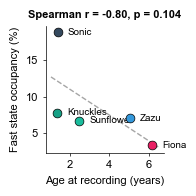

In [38]:
from scipy.stats import spearmanr
from numpy.polynomial.polynomial import polyfit

# Fast state occupancy per animal
fast_occ = {}
for animal in animal_results:
    best       = animal_results[animal]['best']
    states_a   = best['states']
    model_a    = best['model']
    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    fast_occ[animal] = (states_a == fast_state).mean() * 100

# Merge with ages
summary = animal_ages_df[animal_ages_df['Animal_Name'].isin(fast_occ.keys())].copy()
summary['fast_occ'] = summary['Animal_Name'].map(fast_occ)
summary = summary.sort_values('Age_Years')

print(summary[['Animal_Name', 'Age_Years', 'fast_occ']])

r, p = spearmanr(summary['Age_Years'], summary['fast_occ'])
print(f'\nSpearman r = {r:.3f}, p = {p:.3f}')

# Plot
fig, ax = plt.subplots(figsize=(2, 2))

for _, row in summary.iterrows():
    ax.scatter(row['Age_Years'], row['fast_occ'],
               color=ANIMAL_COLORS.get(row['Animal_Name'], 'gray'),
               s=40, zorder=5, edgecolors='black', linewidths=0.5)
    ax.text(row['Age_Years'] + 0.5, row['fast_occ'],
            row['Animal_Name'], fontsize=FONTSIZE - 1, va='center')

# Regression line
x    = summary['Age_Years'].values
y    = summary['fast_occ'].values
b, m = polyfit(x, y, 1)
xline = np.linspace(x.min() - 0.3, x.max() + 0.3, 100)
ax.plot(xline, m * xline + b, color='gray', linewidth=1, ls='--', alpha=0.7)

ax.set_xlabel('Age at recording (years)', fontsize=FONTSIZE)
ax.set_ylabel('Fast state occupancy (%)', fontsize=FONTSIZE)
ax.set_title(f'Spearman r = {r:.2f}, p = {p:.3f}',
             fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fast_state_vs_age.svg'), bbox_inches='tight')
plt.show()

In [39]:
print([c for c in df.columns if 'State' in c or 'Behavioral' in c])

['BehavioralCodes', 'Behavioral_State', 'GLM_HMM_Animal_State', 'GLM_HMM_Animal_State_Prob']


In [40]:
# Map per-animal GLM-HMM states back to df_with_states
# and cross-tabulate with manual Behavioral_State labels

df['GLM_Animal_State'] = np.nan

for animal, res in animal_results.items():
    best     = res['best']
    df_a     = best['df']
    states_a = best['states']
    model_a  = best['model']

    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    slow_state = np.argmax(np.clip(mean_dwell, 0, 1000))

    # Label as exploratory / exploitative / other
    state_labels = {}
    for k in range(best['K']):
        if k == fast_state:
            state_labels[k] = 'Exploratory'
        elif k == slow_state:
            state_labels[k] = 'Exploitative'
        else:
            state_labels[k] = 'Other'

    mapped = pd.Series(states_a, index=df_a.index).map(state_labels)
    df.loc[df_a.index, 'GLM_Animal_State'] = mapped

# Cross-tabulate
cross = pd.crosstab(
    df['Behavioral_State'],
    df['GLM_Animal_State'],
    normalize='index'
) * 100

print(cross.round(1))

GLM_Animal_State  Exploitative  Exploratory  Other
Behavioral_State                                  
Engaged                   82.2          6.7   11.1
Learning (fast)           83.4          9.5    7.1
Learning (slow)           76.5          8.4   15.1
Left Bias                 76.0          8.1   15.8
Mixed                     91.4          8.6    0.0
Random                    67.9         14.0   18.1
Right Bias                87.8          5.4    6.8
Transient Lapse           80.0         11.3    8.6
Unknown                   44.0         54.0    2.0


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_45687/1715096790.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Exploratory' 'Exploratory' 'Exploratory' ... 'Exploitative'
 'Exploitative' 'Exploitative']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df_a.index, 'GLM_Animal_State'] = mapped


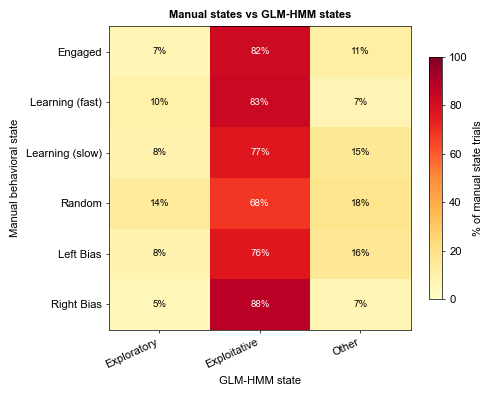

In [41]:
fig, ax = plt.subplots(figsize=(5, 4))

# Clean up the cross-tab — drop Unknown and Mixed
states_to_show = ['Engaged', 'Learning (fast)', 'Learning (slow)',
                  'Random', 'Left Bias', 'Right Bias', 'Perseveration']

cross_clean = cross.loc[
    [s for s in states_to_show if s in cross.index],
    ['Exploratory', 'Exploitative', 'Other']
]

im = ax.imshow(cross_clean.values, cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')

ax.set_yticks(range(len(cross_clean)))
ax.set_yticklabels(cross_clean.index, fontsize=FONTSIZE)
ax.set_xticks(range(3))
ax.set_xticklabels(['Exploratory', 'Exploitative', 'Other'],
                   fontsize=FONTSIZE, rotation=25, ha='right')

# Add values
for i in range(len(cross_clean)):
    for j in range(3):
        val = cross_clean.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=FONTSIZE - 1,
                color='white' if val > 60 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8, label='% of manual state trials')
ax.set_title('Manual states vs GLM-HMM states',
             fontsize=FONTSIZE, fontweight='bold')
ax.set_xlabel('GLM-HMM state', fontsize=FONTSIZE)
ax.set_ylabel('Manual behavioral state', fontsize=FONTSIZE)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'manual_vs_glmhmm_heatmap.svg'),
            bbox_inches='tight')
plt.show()

In [42]:
def prepare_features_performance(df):
    """
    Performance-based feature set designed to match manual state classifier.
    
    Features
    --------
    Bias                   : intercept
    Rolling_Accuracy_5     : rolling accuracy over last 5 trials (matches ROLLING_WINDOW)
    Choice_Deviation       : abs(Rolling_PRight - Expected_PRight)
    Trials_Since_Trans     : position within block (raw, not log)
    High_Prob_Is_Right     : which side is currently correct (0/1)
    Rolling_Switch_Rate    : rolling switch rate over last 5 trials

    Target: High_Prob (correct/incorrect choice)
    """
    df = df.copy()
    df = _add_block_cols(df)

    if 'Outcome_Binary' not in df.columns:
        df['Outcome_Binary'] = df['Outcome'].astype(int)

    # Rolling accuracy — same window as manual classifier
    df['Rolling_Accuracy_5'] = (
        df.groupby('Session_ID')['High_Prob']
          .transform(lambda x: x.rolling(5, min_periods=3).mean())
          .fillna(0.5)
    )

    # Rolling P(Right)
    df['Rolling_PRight_5'] = (
        df.groupby('Session_ID')['Choice_Binary']
          .transform(lambda x: x.rolling(5, min_periods=3).mean())
          .fillna(0.5)
    )

    # Choice deviation from expected
    if 'High_Prob_Is_Right' not in df.columns:
        df['High_Prob_Is_Right'] = df['High_Prob_Is_Right'].astype(float)
    df['Expected_PRight']   = df['High_Prob_Is_Right'].map({True: 0.8, False: 0.2,
                                                             1.0: 0.8,  0.0: 0.2})
    df['Choice_Deviation']  = (df['Rolling_PRight_5'] - df['Expected_PRight']).abs()

    # Rolling switch rate
    if 'PhysicalSwitch' in df.columns:
        df['Rolling_Switch_5'] = (
            df.groupby('Session_ID')['PhysicalSwitch']
              .transform(lambda x: x.rolling(5, min_periods=3).mean())
              .fillna(0.2)
        )
    else:
        df['Rolling_Switch_5'] = 0.2

    features = [
        np.ones(len(df)),
        df['Rolling_Accuracy_5'].values,
        df['Choice_Deviation'].values,
        df['Trials_Since_Transition'].values / 20.0,
        df['High_Prob_Is_Right'].astype(float).values,
        df['Rolling_Switch_5'].values,
    ]
    names = [
        'Bias',
        'Rolling_Accuracy_5',
        'Choice_Deviation',
        'Trials_Since_Trans',
        'High_Prob_Is_Right',
        'Rolling_Switch_5',
    ]

    X           = np.column_stack(features)
    y           = df['High_Prob'].values.astype(float)
    session_ids = df['Session_ID'].values
    return X, y, session_ids, names, df


# Prepare and standardise
X_perf, y_perf, sess_perf, names_perf, df_perf = prepare_features_performance(df)

scaler_perf      = StandardScaler()
Xs_perf          = X_perf.copy()
Xs_perf[:, 1:]   = scaler_perf.fit_transform(X_perf[:, 1:])

print(f'Features ({len(names_perf)}): {names_perf}')

Features (6): ['Bias', 'Rolling_Accuracy_5', 'Choice_Deviation', 'Trials_Since_Trans', 'High_Prob_Is_Right', 'Rolling_Switch_5']


In [58]:
model_perf = GLM_HMM(
    n_states    = 3,
    n_features  = Xs_perf.shape[1],
    random_seed = RANDOM_SEED,
    stickiness  = 50,
    l2_penalty  = L2_PENALTY,
)

model_perf.fit(Xs_perf, y_perf, sess_perf, n_iter=NUM_ITER, verbose=True)
states_perf, gamma_perf = model_perf.predict_states(Xs_perf, y_perf, sess_perf)

  K=3 | Features=6 | Trials=36,673 | Sessions=100
    Iter  10/100 | LL:   -16262.1 (Δ+14.0) | Dwell: [22.9 29.2 11. ]
    Iter  20/100 | LL:   -16102.2 (Δ+15.0) | Dwell: [12.7 27.8  6.8]
    Iter  30/100 | LL:   -15995.6 (Δ+6.9) | Dwell: [ 8.  25.7  5. ]
    Iter  40/100 | LL:   -15955.1 (Δ+2.5) | Dwell: [ 6.4 24.7  4.6]
    Iter  50/100 | LL:   -15936.8 (Δ+1.5) | Dwell: [ 5.7 25.1  4.5]
    Iter  60/100 | LL:   -15921.1 (Δ+1.8) | Dwell: [ 5.3 26.3  4.4]
    Iter  70/100 | LL:   -15893.2 (Δ+4.1) | Dwell: [ 5.  28.3  4.5]
    Iter  80/100 | LL:   -15824.5 (Δ+9.4) | Dwell: [ 4.5 29.3  4.4]
    Iter  90/100 | LL:   -15717.1 (Δ+12.7) | Dwell: [ 4.1 25.   4.1]
    Iter 100/100 | LL:   -14241.5 (Δ+169.7) | Dwell: [3.9 9.  3.4]
    Final LL: -14241.5 | BIC: 28735.3


In [59]:
# Characterize states
print(f'\n{"State":<8} {"N":>8} {"Accuracy":>10} {"P(Right)":>10} '
      f'{"Switch":>10} {"WinStay":>10} {"LoseSwitch":>12} {"Dwell":>8}')
print('-' * 80)

mean_dwell_perf = 1.0 / np.maximum(1 - np.diag(model_perf.transitions), 1e-6)

for k in range(3):
    mask = states_perf == k
    sdf  = df_perf[mask]
    acc  = sdf['High_Prob'].mean()
    pr   = sdf['Choice_Binary'].mean()
    sw   = sdf['PhysicalSwitch'].mean()
    ws   = ((sdf['Outcome_Binary'].shift(1) == 1) &
            (sdf['Choice_Binary'] == sdf['Choice_Binary'].shift(1))).mean()
    ls   = ((sdf['Outcome_Binary'].shift(1) == 0) &
            (sdf['Choice_Binary'] != sdf['Choice_Binary'].shift(1))).mean()
    print(f'  {k:<6} {mask.sum():>8,} {acc:>10.3f} {pr:>10.3f} '
          f'{sw:>10.3f} {ws:>10.3f} {ls:>12.3f} {mean_dwell_perf[k]:>8.1f}')

print(f'\nAnimal breakdown:')
for k in range(3):
    print(f'\nState {k}:')
    print(df_perf[states_perf == k]['Animal_Name'].value_counts().to_string())


State           N   Accuracy   P(Right)     Switch    WinStay   LoseSwitch    Dwell
--------------------------------------------------------------------------------
  0        11,822      0.980      0.500      0.186      0.559        0.127      3.9
  1        19,165      0.703      0.498      0.184      0.550        0.134      9.0
  2         5,686      0.009      0.499      0.207      0.414        0.157      3.4

Animal breakdown:

State 0:
Animal_Name
Knuckles     3398
Sunflower    3298
Fiona        2406
Sonic        1687
Zazu         1033

State 1:
Animal_Name
Knuckles     5896
Sunflower    4988
Sonic        4694
Zazu         1818
Fiona        1769

State 2:
Animal_Name
Knuckles     1756
Sunflower    1638
Fiona        1049
Sonic         790
Zazu          453


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_4566/3412496642.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Session_Trial_Bin')['GLM_Fast']


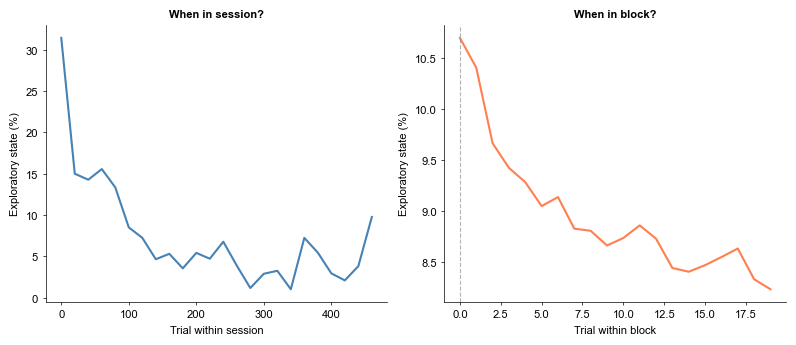

In [61]:
# Where in the session does the fast state occur?
# Look at trial number within session and block position

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# Panel A: fast state probability by trial number within session
ax = axes[0]

df['Session_Trial'] = df.groupby('Session_ID').cumcount()
df['GLM_Fast']      = (df['GLM_Animal_State'] == 'Exploratory').astype(float)

# Bin by session trial number
bins     = np.arange(0, 500, 20)
df['Session_Trial_Bin'] = pd.cut(df['Session_Trial'], bins=bins, labels=bins[:-1])

fast_by_trial = (
    df.groupby('Session_Trial_Bin')['GLM_Fast']
    .mean() * 100
)

ax.plot(fast_by_trial.index.astype(float), fast_by_trial.values,
        color='steelblue', linewidth=1.5)
ax.set_xlabel('Trial within session', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_title('When in session?', fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Panel B: fast state probability by trial position within block
ax = axes[1]

fast_by_block = (
    df.groupby('Trial_in_Block')['GLM_Fast']
    .mean() * 100
)

ax.plot(fast_by_block.index, fast_by_block.values,
        color='coral', linewidth=1.5)
ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_title('When in block?', fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'exploratory_state_timing.svg'),
            bbox_inches='tight')
plt.show()

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_4566/628715351.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast']
/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_4566/628715351.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = session_fast.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem])


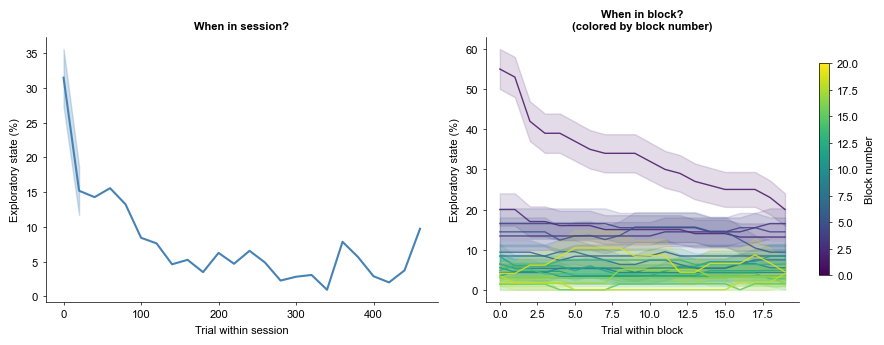

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# ── Panel A: exploratory state by trial within session (with SEM) ─────────────
ax = axes[0]

df['Session_Trial'] = df.groupby('Session_ID').cumcount()
df['GLM_Fast']      = (df['GLM_Animal_State'] == 'Exploratory').astype(float)

bins = np.arange(0, 500, 20)
df['Session_Trial_Bin'] = pd.cut(df['Session_Trial'], bins=bins, labels=bins[:-1])

# Session-level means per bin then SEM across sessions
session_fast = (
    df.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast']
    .mean() * 100
).reset_index()

bin_stats = session_fast.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem])
bin_stats.index = bin_stats.index.astype(float)

ax.plot(bin_stats.index, bin_stats['mean'],
        color='steelblue', linewidth=1.5)
ax.fill_between(bin_stats.index,
                bin_stats['mean'] - bin_stats['sem'],
                bin_stats['mean'] + bin_stats['sem'],
                color='steelblue', alpha=0.25)

ax.set_xlabel('Trial within session', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_title('When in session?', fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: exploratory state by trial within block, grouped by block number ──
ax = axes[1]

# Only first 20 blocks
MAX_BLOCKS = 20
cmap       = plt.cm.viridis
colors     = [cmap(i / MAX_BLOCKS) for i in range(MAX_BLOCKS)]

# Session-level mean per block × trial_in_block, then SEM across sessions
for block_n in range(MAX_BLOCKS):
    block_data = df[df['BlockCount'] == block_n]
    if len(block_data) == 0:
        continue

    session_block = (
        block_data.groupby(['Session_ID', 'Trial_in_Block'])['GLM_Fast']
        .mean() * 100
    ).reset_index()

    stats = session_block.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem])

    ax.plot(stats.index, stats['mean'],
            color=colors[block_n], linewidth=1, alpha=0.85)
    ax.fill_between(stats.index,
                    stats['mean'] - stats['sem'],
                    stats['mean'] + stats['sem'],
                    color=colors[block_n], alpha=0.15)

# Colorbar for block number
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=0, vmax=MAX_BLOCKS))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Block number', shrink=0.8)

ax.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_title('When in block?\n(colored by block number)', fontsize=FONTSIZE,
             fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'exploratory_state_timing_v2.svg'),
            bbox_inches='tight')
plt.show()

In [64]:
# Use integer bins directly instead of pd.cut
df['Session_Trial_Bin'] = (df['Session_Trial'] // 20) * 20

session_fast = (
    df.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast']
    .mean() * 100
).reset_index()

bin_stats = session_fast.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])

print(bin_stats.head(20))

                        mean       sem  count
Session_Trial_Bin                            
0                  33.200000  4.146631    100
20                 15.500000  3.512244    100
40                 14.123711  3.418173     97
60                 15.670103  3.607419     97
80                 13.505155  3.169710     97
100                 8.489583  2.615867     96
120                 7.684211  2.432528     95
140                 4.734043  2.126151     94
160                 5.215054  2.087824     93
180                 3.571429  1.890284     91
200                 5.977011  2.327788     87
220                 4.880952  1.978760     84
240                 6.506024  2.285035     83
260                 5.064103  2.321721     78
280                 2.152778  1.499303     72
300                 2.910448  2.043039     67
320                 2.968750  1.791178     64
340                 0.948276  0.556229     58
360                 7.755102  3.257191     49
380                 5.555556  2.90

/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)


/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; al

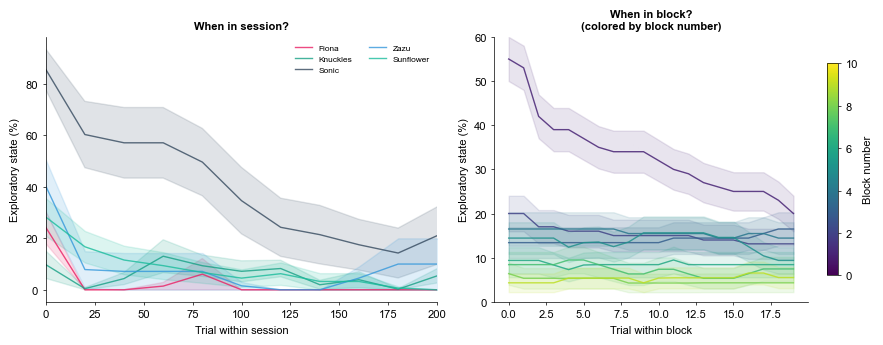

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# ── Panel A: per animal + overall mean ───────────────────────────────────────
ax = axes[0]

df['Session_Trial_Bin'] = (df['Session_Trial'] // 20) * 20

# Per animal
for animal in animals_ordered:
    adf = df[df['Animal_Name'] == animal]
    
    session_fast_a = (
        adf.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast']
        .mean() * 100
    ).reset_index()

    bin_stats_a = session_fast_a.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
    bin_stats_a = bin_stats_a[bin_stats_a['count'] >= 3]

    ax.plot(bin_stats_a.index, bin_stats_a['mean'],
            color=ANIMAL_COLORS.get(animal, 'gray'),
            linewidth=1, alpha=0.8, label=animal)
    ax.fill_between(bin_stats_a.index,
                    bin_stats_a['mean'] - bin_stats_a['sem'],
                    bin_stats_a['mean'] + bin_stats_a['sem'],
                    color=ANIMAL_COLORS.get(animal, 'gray'), alpha=0.15)

# Overall mean on top in black
session_fast_all = (
    df.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast']
    .mean() * 100
).reset_index()
bin_stats_all = session_fast_all.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
bin_stats_all = bin_stats_all[bin_stats_all['count'] >= 5]

# ax.plot(bin_stats_all.index, bin_stats_all['mean'],
#         color='black', linewidth=2, alpha=0.9, label='All', zorder=5)
# ax.fill_between(bin_stats_all.index,
#                 bin_stats_all['mean'] - bin_stats_all['sem'],
#                 bin_stats_all['mean'] + bin_stats_all['sem'],
#                 color='black', alpha=0.15)

ax.set_xlabel('Trial within session', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_xlim(0, 200)
ax.set_title('When in session?', fontsize=FONTSIZE, fontweight='bold')
ax.legend(fontsize=FONTSIZE - 2, frameon=False, ncol=2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: block 0 separate, every other block, zoomed ─────────────────────
ax = axes[1]

MAX_BLOCKS     = 10
BLOCKS_TO_SHOW = [0] + list(range(1, MAX_BLOCKS, 1))
cmap           = plt.cm.viridis

for block_n in BLOCKS_TO_SHOW:
    block_data = df[df['BlockCount'] == block_n]
    if len(block_data) == 0:
        continue

    session_block = (
        block_data.groupby(['Session_ID', 'Trial_in_Block'])['GLM_Fast']
        .mean() * 100
    ).reset_index()

    stats = session_block.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem, 'count'])
    stats = stats[stats['count'] >= 5]

    if block_n == 0:
        color, lw, ls = 'black', 1.5, '--'
    else:
        color, lw, ls = cmap(block_n / MAX_BLOCKS), 1.0, '-'

    ax.plot(stats.index, stats['mean'],
            color=color, linewidth=lw, linestyle=ls, alpha=0.85,
            label='Block 0' if block_n == 0 else None)
    ax.fill_between(stats.index,
                    stats['mean'] - stats['sem'],
                    stats['mean'] + stats['sem'],
                    color=color, alpha=0.12)

ax.legend(fontsize=FONTSIZE - 2, frameon=False)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_BLOCKS))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Block number', shrink=0.8)

ax.set_ylim(0, 60)
ax.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_title('When in block?\n(colored by block number)', fontsize=FONTSIZE,
             fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'exploratory_state_timing_v4.svg'),
            bbox_inches='tight')
plt.show()

In [72]:
block0 = df[df['BlockCount'] == 0]
print(block0['Trial_in_Block'].describe())
print(block0['Trial_in_Block'].unique()[:20])
print(len(block0))

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Trial_in_Block, dtype: float64
[]
0


In [73]:
print(df['BlockCount'].unique()[:10])
print(df['BlockCount'].min())

[ 1  2  3  4  5  6  7  8  9 10]
1


/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; al

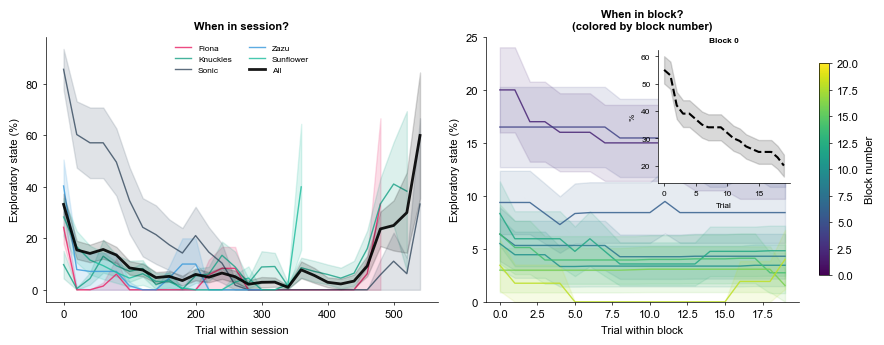

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# ── Panel A: per animal + overall mean ───────────────────────────────────────
ax = axes[0]

for animal in animals_ordered:
    adf = df[df['Animal_Name'] == animal]
    session_fast_a = (
        adf.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast']
        .mean() * 100
    ).reset_index()
    bin_stats_a = session_fast_a.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
    bin_stats_a = bin_stats_a[bin_stats_a['count'] >= 3]

    ax.plot(bin_stats_a.index, bin_stats_a['mean'],
            color=ANIMAL_COLORS.get(animal, 'gray'),
            linewidth=1, alpha=0.8, label=animal)
    ax.fill_between(bin_stats_a.index,
                    bin_stats_a['mean'] - bin_stats_a['sem'],
                    bin_stats_a['mean'] + bin_stats_a['sem'],
                    color=ANIMAL_COLORS.get(animal, 'gray'), alpha=0.15)

# Overall mean
session_fast_all = (
    df.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast']
    .mean() * 100
).reset_index()
bin_stats_all = session_fast_all.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
bin_stats_all = bin_stats_all[bin_stats_all['count'] >= 5]

ax.plot(bin_stats_all.index, bin_stats_all['mean'],
        color='black', linewidth=2, alpha=0.9, label='All', zorder=10)
ax.fill_between(bin_stats_all.index,
                bin_stats_all['mean'] - bin_stats_all['sem'],
                bin_stats_all['mean'] + bin_stats_all['sem'],
                color='black', alpha=0.15, zorder=10)

ax.set_xlabel('Trial within session', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_title('When in session?', fontsize=FONTSIZE, fontweight='bold')
ax.legend(fontsize=FONTSIZE - 2, frameon=False, ncol=2)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: main plot blocks 1+ zoomed, inset for block 0 ───────────────────
ax = axes[1]

MAX_BLOCKS     = 20
BLOCKS_TO_SHOW = list(range(2, MAX_BLOCKS, 2))
cmap           = plt.cm.viridis

# Main plot: blocks 2+ only
for block_n in BLOCKS_TO_SHOW:
    block_data = df[df['BlockCount'] == block_n]
    if len(block_data) == 0:
        continue

    session_block = (
        block_data.groupby(['Session_ID', 'Trial_in_Block'])['GLM_Fast']
        .mean() * 100
    ).reset_index()
    stats = session_block.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem, 'count'])
    stats = stats[stats['count'] >= 5]

    ax.plot(stats.index, stats['mean'],
            color=cmap(block_n / MAX_BLOCKS), linewidth=1, alpha=0.85)
    ax.fill_between(stats.index,
                    stats['mean'] - stats['sem'],
                    stats['mean'] + stats['sem'],
                    color=cmap(block_n / MAX_BLOCKS), alpha=0.12)

ax.set_ylim(0, 25)
ax.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax.set_ylabel('Exploratory state (%)', fontsize=FONTSIZE)
ax.set_title('When in block?\n(colored by block number)', fontsize=FONTSIZE,
             fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=MAX_BLOCKS))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Block number', shrink=0.8)

# Inset: block 0 only
ax_inset = ax.inset_axes([0.55, 0.45, 0.42, 0.50])  # [x, y, width, height]

block0_data = df[df['BlockCount'] == 1]
session_b0  = (
    block0_data.groupby(['Session_ID', 'Trial_in_Block'])['GLM_Fast']
    .mean() * 100
).reset_index()
stats_b0 = session_b0.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem, 'count'])
stats_b0 = stats_b0[stats_b0['count'] >= 5]

ax_inset.plot(stats_b0.index, stats_b0['mean'],
              color='black', linewidth=1.5, linestyle='--')
ax_inset.fill_between(stats_b0.index,
                      stats_b0['mean'] - stats_b0['sem'],
                      stats_b0['mean'] + stats_b0['sem'],
                      color='black', alpha=0.15)

ax_inset.set_title('Block 0', fontsize=FONTSIZE - 2, fontweight='bold')
ax_inset.set_xlabel('Trial', fontsize=FONTSIZE - 2)
ax_inset.set_ylabel('%', fontsize=FONTSIZE - 2)
ax_inset.tick_params(labelsize=FONTSIZE - 2)
ax_inset.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'exploratory_state_timing_v5.svg'),
            bbox_inches='tight')
plt.show()

In [109]:
# Find a session with high bias state occupancy
df_AR['GLM_state_k3'] = states_k3

bias_sessions = (
    df_AR.groupby(['Animal_Name', 'Session_ID'])
    .apply(lambda x: (x['GLM_state_k3'] == 0).mean() * 100)
    .reset_index()
)
bias_sessions.columns = ['Animal_Name', 'Session_ID', 'bias_occ']
bias_sessions = bias_sessions.sort_values('bias_occ', ascending=False)

print(bias_sessions.head(10))

   Animal_Name                                Session_ID  bias_occ
0        Fiona     2022-04-25_20220425_Fiona_Reversal3.1     100.0
13       Fiona     2022-05-18_20220518_Fiona_Reversal3.1     100.0
46       Sonic     2023-11-08_20231108_Sonic_Reversal3.1     100.0
43       Sonic     2023-11-02_20231102_Sonic_Reversal3.1     100.0
40       Sonic     2023-10-26_20231026_Sonic_Reversal3.1     100.0
39       Sonic     2023-10-25_20231025_Sonic_Reversal3.1     100.0
38       Sonic     2023-10-24_20231024_Sonic_Reversal3.1     100.0
50       Sonic     2023-11-20_20231120_Sonic_Reversal3.1     100.0
3        Fiona  2022-05-03_20220503_Fiona_Reversal3.1(1)     100.0
7        Fiona     2022-05-09_20220509_Fiona_Reversal3.1     100.0


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_4566/3561828626.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['GLM_state_k3'] == 0).mean() * 100)


In [123]:
# Get gamma for the example session from per-animal model


# example_session = '2023-10-06_20231006_Knuckles_Reversal3.1'
# animal          = 'Knuckles'

example_session = '2022-04-25_20220425_Fiona_Reversal3.1'
animal = 'Fiona'

best_k      = animal_results[animal]['best']
df_a        = best_k['df']
states_a    = best_k['states']
gamma_a     = best_k['gamma']
model_a     = best_k['model']

mean_dwell  = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
fast_state  = np.argmin(mean_dwell)
slow_state  = 2 # np.argmax(np.clip(mean_dwell, 0, 1000))

# Get session indices
sess_mask   = df_a['Session_ID'] == example_session
sess_idx    = df_a[sess_mask].index
gamma_sess  = gamma_a[sess_mask.values]

print(f'Session trials: {sess_mask.sum()}')
print(f'Fast state: {fast_state}, Slow state: {slow_state}')
print(f'Gamma shape: {gamma_sess.shape}')

Session trials: 497
Fast state: 1, Slow state: 2
Gamma shape: (497, 3)


In [118]:
df['GLM_Animal_State']      = np.nan
df['GLM_Animal_State_Prob'] = np.nan

for animal, res in animal_results.items():
    best       = res['best']
    df_a       = best['df']
    states_a   = best['states']
    gamma_a    = best['gamma']
    model_a    = best['model']
    K          = best['K']

    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)

    # Identify absorbing state (dwell > 10000) if any
    absorbing = [k for k in range(K) if mean_dwell[k] > 10000]
    valid     = [k for k in range(K) if k not in absorbing]

    # Fast and slow from valid states only
    valid_dwells = [(k, mean_dwell[k]) for k in valid]
    fast_state   = min(valid_dwells, key=lambda x: x[1])[0]
    slow_state   = max(valid_dwells, key=lambda x: x[1])[0]

    state_map = {k: 'Other' for k in range(K)}
    state_map[fast_state] = 'Exploratory'
    state_map[slow_state] = 'Exploitative'

    mapped = pd.Series(states_a, index=df_a.index).map(state_map)
    df.loc[df_a.index, 'GLM_Animal_State']      = mapped
    df.loc[df_a.index, 'GLM_Animal_State_Prob'] = gamma_a.max(axis=1)

df['GLM_Fast'] = (df['GLM_Animal_State'] == 'Exploratory').astype(float)

print('State counts per animal:')
print(df.groupby(['Animal_Name', 'GLM_Animal_State']).size().unstack(fill_value=0))

State counts per animal:
GLM_Animal_State  Exploitative  Exploratory  Other
Animal_Name                                       
Fiona                     4083          176    965
Knuckles                 10185          865      0
Sonic                     5823         1348      0
Sunflower                 9256          668      0
Zazu                      3070          234      0


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_4566/2532478104.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Exploratory' 'Exploratory' 'Exploratory' ... 'Other' 'Other' 'Other']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df_a.index, 'GLM_Animal_State']      = mapped


In [140]:
example_session = '2023-10-06_20231006_Knuckles_Reversal3.1'
animal          = 'Knuckles'


# high biased states:
example_session = '2022-04-25_20220425_Fiona_Reversal3.1'
animal = 'Fiona'


TICK_LENGTH     = 5

# Recompute fast/slow state indices for this animal
best_ex      = animal_results[animal]['best']
model_ex     = best_ex['model']
df_a_ex      = best_ex['df']
gamma_ex_all = best_ex['gamma']
K_ex         = best_ex['K']

mean_dwell_ex = 1.0 / np.maximum(1 - np.diag(model_k.transitions), 1e-6)
absorbing_ex  = [k for k in range(best_k['K']) if mean_dwell_ex[k] > 10000]
valid_ex      = [k for k in range(best_k['K']) if k not in absorbing_ex]
valid_dwells  = [(k, mean_dwell_ex[k]) for k in valid_ex]
fast_state    = min(valid_dwells, key=lambda x: x[1])[0]
slow_state    = max(valid_dwells, key=lambda x: x[1])[0]

# Get gamma for this session only
sess_mask_ex = df_a_ex['Session_ID'] == example_session
gamma_sess   = gamma_ex_all[sess_mask_ex.values]

print(f'fast_state={fast_state}, slow_state={slow_state}, gamma_sess shape={gamma_sess.shape}')

sdf = df[df['Session_ID'] == example_session].sort_values('Trial').reset_index(drop=True)
sdf['continuous_trial'] = range(len(sdf))

# Align gamma to session trial order
sess_mask  = df_a['Session_ID'] == example_session
gamma_sess = gamma_a[sess_mask.values]  # (489, 2)

HIGH_RIGHT_COLOR = '#f39c12'
HIGH_LEFT_COLOR  = '#3498db'

fig = plt.figure(figsize=(8, 6))
gs  = fig.add_gridspec(5, 1, hspace=0.25,
                        height_ratios=[0.4, 0.5, 1, 1, 1])

ax1 = fig.add_subplot(gs[0])   # Block structure
ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Choice + outcome
ax3 = fig.add_subplot(gs[2], sharex=ax1)  # Q_diff
ax4 = fig.add_subplot(gs[3], sharex=ax1)  # Rolling accuracy
ax5 = fig.add_subplot(gs[4], sharex=ax1)  # P(state)

block_starts = sdf.groupby('BlockCount')['continuous_trial'].min()

# ── Panel 1: Block structure ──────────────────────────────────────────────────
for _, block_df in sdf.groupby('BlockCount'):
    start = block_df['continuous_trial'].min()
    end   = block_df['continuous_trial'].max()
    color = HIGH_RIGHT_COLOR if block_df['High_Prob_Is_Right'].iloc[0] else HIGH_LEFT_COLOR
    ax1.barh(0, end - start + 1, left=start, height=0.6,
             color=color, edgecolor='white', linewidth=0.3, alpha=0.85)

ax1.set_xlim(-1, len(sdf))
ax1.set_ylim(-0.4, 0.4)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.spines[['top','right','bottom','left']].set_visible(False)
ax1.set_ylabel('Block', fontsize=FONTSIZE, rotation=0, ha='right', va='center')
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(facecolor=HIGH_RIGHT_COLOR, label='Right high-prob', alpha=0.85),
    Patch(facecolor=HIGH_LEFT_COLOR,  label='Left high-prob',  alpha=0.85),
], fontsize=FONTSIZE-2, frameon=False, loc='upper right',
   bbox_to_anchor=(1.0, 1.8), ncol=2)

# ── Panel 2: Choice + outcome ─────────────────────────────────────────────────
for _, trial in sdf.iterrows():
    y_val      = trial['Choice_Binary']
    face_color = '#2ecc71' if trial['Outcome_Binary'] == 1 else 'none'
    edge_color = '#2ecc71' if trial['Outcome_Binary'] == 1 else '#e74c3c'
    ax2.scatter(trial['continuous_trial'], y_val, s=8, marker='o',
                facecolors=face_color, edgecolors=edge_color,
                alpha=0.8, linewidth=0.5, zorder=3)

for block, start in block_starts.items():
    if start > 0:
        ax2.axvline(start - 0.5, color='gray', ls=':', lw=0.6, alpha=0.4)

ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Left', 'Right'], fontsize=FONTSIZE-1)
ax2.set_ylabel('Choice', fontsize=FONTSIZE)
ax2.spines[['top','bottom','right']].set_visible(False)
ax2.tick_params(axis='x', labelbottom=False, length=0)

# ── Panel 3: Q_right - Q_left ───────────────────────────────────────────────
sdf['Q_wave'] = sdf['Q_left'] - sdf['Q_right']

ax3.plot(sdf['continuous_trial'], sdf['Q_wave'],
         color='#2c3e50', linewidth=1.0, alpha=0.85)
ax3.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax3.fill_between(sdf['continuous_trial'], 0, sdf['Q_wave'],
                 where=sdf['Q_wave'] > 0, color=HIGH_RIGHT_COLOR, alpha=0.3)
ax3.fill_between(sdf['continuous_trial'], 0, sdf['Q_wave'],
                 where=sdf['Q_wave'] < 0, color=HIGH_LEFT_COLOR, alpha=0.3)

for block, start in block_starts.items():
    if start > 0:
        ax3.axvline(start - 0.5, color='gray', ls=':', lw=0.6, alpha=0.4)

ax3.set_ylabel('Q_right - Q_left', fontsize=FONTSIZE)
ax3.set_yticks([-0.5, 0, 0.5])
ax3.set_ylim(-0.6, 0.6)
ax3.spines[['top','bottom','right']].set_visible(False)
ax3.tick_params(axis='x', labelbottom=False, length=0)

# ── Panel 4: Rolling accuracy ─────────────────────────────────────────────────
for _, block_df in sdf.groupby('BlockCount'):
    start = block_df['continuous_trial'].min()
    end   = block_df['continuous_trial'].max()
    color = HIGH_RIGHT_COLOR if block_df['High_Prob_Is_Right'].iloc[0] else HIGH_LEFT_COLOR
    ax4.axvspan(start - 0.5, end + 0.5, alpha=0.08, color=color, zorder=0)

for block, start in block_starts.items():
    if start > 0:
        ax4.axvline(start - 0.5, color='gray', ls=':', lw=0.6, alpha=0.4)

ax4.plot(sdf['continuous_trial'], sdf['Rolling_Accuracy'],
         color=ANIMAL_COLORS[animal], linewidth=1.5, alpha=0.9)
ax4.axhline(0.8, color='gray', ls='--', lw=0.8, alpha=0.5)
ax4.axhline(0.5, color='gray', ls=':',  lw=0.8, alpha=0.5)
ax4.set_ylim(0, 1.05)
ax4.set_yticks([0, 0.5, 1.0])
ax4.set_ylabel('Rolling\nAccuracy', fontsize=FONTSIZE)
ax4.spines[['top','bottom','right']].set_visible(False)
ax4.tick_params(axis='x', labelbottom=False, length=0)

# ── Panel 5: P(state) ─────────────────────────────────────────────────────────
for block, start in block_starts.items():
    if start > 0:
        ax5.axvline(start - 0.5, color='gray', ls=':', lw=0.6, alpha=0.4)

ax5.plot(sdf['continuous_trial'], gamma_sess[:, fast_state],
         color='#8e44ad', linewidth=1.2, label='P(exploratory)', alpha=0.9)
ax5.plot(sdf['continuous_trial'], gamma_sess[:, slow_state],
         color='#1abc9c', linewidth=1.2, label='P(exploitative)', alpha=0.9)

ax5.set_ylim(0, 1.05)
ax5.set_yticks([0, 0.5, 1.0])
ax5.set_ylabel('P(state)', fontsize=FONTSIZE)
ax5.set_xlabel('Trial', fontsize=FONTSIZE)
ax5.legend(fontsize=FONTSIZE-2, frameon=False, loc='upper right', ncol=2)
ax5.spines[['top','right']].set_visible(False)
ax5.tick_params(labelsize=FONTSIZE-1, length=TICK_LENGTH)

fig.suptitle(f'{animal} | {example_session}',
             fontsize=FONTSIZE, fontweight='bold')

plt.savefig(os.path.join(FIGURE_PATH, 'exemplar_session_with_HEAVY_BIAS_states.svg'),
            bbox_inches='tight')
plt.show()

fast_state=1, slow_state=0, gamma_sess shape=(497, 3)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 5224 but size of corresponding boolean axis is 3304

In [131]:
session_records = []

for animal, res in animal_results.items():
    best       = res['best']
    df_a       = best['df'].copy()
    states_a   = best['states']
    model_a    = best['model']
    K          = best['K']

    mean_dwell   = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    absorbing    = [k for k in range(K) if mean_dwell[k] > 10000]
    valid        = [k for k in range(K) if k not in absorbing]
    valid_dwells = [(k, mean_dwell[k]) for k in valid]
    fast_state   = min(valid_dwells, key=lambda x: x[1])[0]
    slow_state   = max(valid_dwells, key=lambda x: x[1])[0]

    df_a['GLM_state'] = states_a
    sessions_sorted   = sorted(df_a['Session_ID'].unique())

    for i, session in enumerate(sessions_sorted):
        sdf     = df_a[df_a['Session_ID'] == session]
        n_total = len(sdf)
        if n_total < 20:
            continue

        slow_mask       = sdf['GLM_state'] == slow_state
        runs            = (slow_mask != slow_mask.shift()).cumsum()
        slow_runs       = sdf[slow_mask].groupby(runs[slow_mask]).size()
        mean_slow_dwell = slow_runs.mean() if len(slow_runs) > 0 else np.nan

        session_records.append(dict(
            animal          = animal,
            session_id      = session,
            session_num     = i,
            fast_occ        = (sdf['GLM_state'] == fast_state).mean() * 100,
            slow_occ        = (sdf['GLM_state'] == slow_state).mean() * 100,
            mean_slow_dwell = mean_slow_dwell,
            n_trials        = n_total,
        ))

session_df = pd.DataFrame(session_records)
session_df['session_num_norm'] = session_df.groupby('animal')['session_num'].transform(
    lambda x: x / x.max() if x.max() > 0 else 0
)

session_metrics = (
    df.groupby(['Animal_Name', 'Session_ID'])
    .agg(accuracy=('High_Prob', 'mean'), switch_rate=('PhysicalSwitch', 'mean'))
    .reset_index()
    .rename(columns={'Animal_Name': 'animal', 'Session_ID': 'session_id'})
)
session_df = session_df.merge(session_metrics, on=['animal', 'session_id'], how='left')
session_df_filtered = session_df[session_df['n_trials'] >= 200].copy()

print(f'Total sessions: {len(session_df_filtered)}')
print(session_df_filtered.groupby('animal')[['fast_occ', 'slow_occ']].mean().round(1))

Total sessions: 87
           fast_occ  slow_occ
animal                       
Fiona           3.6      79.8
Knuckles        7.4      92.6
Sonic          18.5      81.5
Sunflower       5.3      94.7
Zazu           10.0      90.0


In [1]:
# # ── Session-level state occupancy ─────────────────────────────────────────────

# session_records = []

# for animal, res in animal_results.items():
#     best       = res['best']
#     df_a       = best['df']
#     states_a   = best['states']
#     model_a    = best['model']

#     # mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
#     # fast_state = np.argmin(mean_dwell)
#     # slow_state = max(valid_dwells, key=lambda x: x[1])[0]
#     mean_dwell  = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
#     absorbing   = [k for k in range(K) if mean_dwell[k] > 10000]
#     valid       = [k for k in range(K) if k not in absorbing]
#     valid_dwells = [(k, mean_dwell[k]) for k in valid]
#     fast_state  = min(valid_dwells, key=lambda x: x[1])[0]
#     slow_state  = max(valid_dwells, key=lambda x: x[1])[0]

#     df_a = df_a.copy()
#     df_a['GLM_state'] = states_a

#     for session, sdf in df_a.groupby('Session_ID'):
#         n_total = len(sdf)
#         if n_total < 20:
#             continue

#         # Get session number (order within animal)
#         session_records.append(dict(
#             animal      = animal,
#             session_id  = session,
#             fast_occ    = (sdf['GLM_state'] == fast_state).mean() * 100,
#             slow_occ    = (sdf['GLM_state'] == slow_state).mean() * 100,
#             n_trials    = n_total,
#         ))

# session_df = pd.DataFrame(session_records)

session_df['valid_occ'] = session_df['fast_occ'] + session_df['slow_occ']
session_df_filtered = session_df[
    (session_df['n_trials'] >= 200) &
    (session_df['valid_occ'] >= 50)
].copy()

print(f'Sessions before filter: {len(session_df)}')
print(f'Sessions after filter:  {len(session_df_filtered)}')
print(session_df_filtered.groupby('animal')[['fast_occ', 'slow_occ']].mean().round(1))


# Add session number per animal (chronological order)
session_df_filtered = session_df_filtered.sort_values(['animal', 'session_id'])
session_df_filtered['session_num'] = session_df_filtered.groupby('animal').cumcount()
session_df_filtered['session_num_norm'] = session_df_filtered.groupby('animal')['session_num'].transform(
    lambda x: x / x.max() if x.max() > 0 else 0
)

print(session_df_filtered.head(10))
print(f'\nTotal sessions: {len(session_df_filtered)}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4.5))

for animal in animals_ordered:
    adf = session_df_filtered[session_df_filtered['animal'] == animal].sort_values('session_num')
    if len(adf) == 0:
        continue

    base_color = np.array(plt.matplotlib.colors.to_rgb(ANIMAL_COLORS.get(animal, 'gray')))

    for _, row in adf.iterrows():
        # Darker = earlier session, lighter = later session
        alpha  = 0.3 + 0.7 * (1 - row['session_num_norm'])
        color  = base_color * row['session_num_norm'] + base_color * (1 - row['session_num_norm']) * 0.3
        color  = np.clip(base_color * (0.4 + 0.6 * (1 - row['session_num_norm'])), 0, 1)

        ax.scatter(row['fast_occ'], row['slow_occ'],
                   color=color, s=40, alpha=0.85,
                   edgecolors='white', linewidths=0.4, zorder=3)

    # Connect sessions with a line
    ax.plot(adf['fast_occ'], adf['slow_occ'],
            color=ANIMAL_COLORS.get(animal, 'gray'),
            linewidth=0.6, alpha=0.4, zorder=2)

# Animal legend
handles = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                      linewidth=2, label=a) for a in animals_ordered
           if a in session_df_filtered['animal'].values]
ax.legend(handles=handles, fontsize=FONTSIZE - 2, frameon=False, ncol=2)

ax.set_xlabel('Fast state occupancy (%)', fontsize=FONTSIZE)
ax.set_ylabel('Slow state occupancy (%)', fontsize=FONTSIZE)
ax.set_title('Session-level state occupancy\n(darker = earlier session)',
             fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'session_state_occupancy_scatter.svg'),
            bbox_inches='tight')
plt.show()

NameError: name 'session_df' is not defined

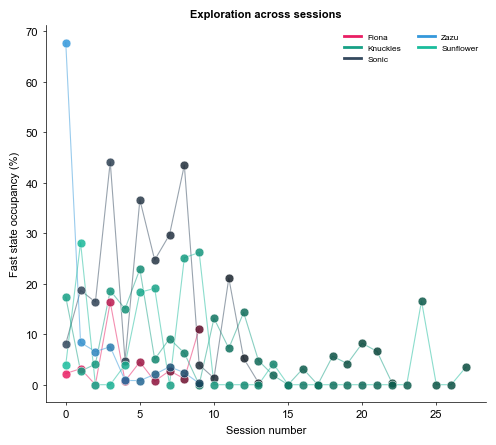

In [135]:
fig, ax = plt.subplots(figsize=(5, 4.5))
session_df = session_df_filtered.copy()
for animal in animals_ordered:
    adf = session_df[session_df['animal'] == animal].sort_values('session_num')
    if len(adf) == 0:
        continue

    base_color = np.array(plt.matplotlib.colors.to_rgb(ANIMAL_COLORS.get(animal, 'gray')))
    color_dark = np.clip(base_color * 0.4, 0, 1)
    color_light = np.clip(base_color * 1.0, 0, 1)

    for _, row in adf.iterrows():
        color = color_dark + (color_light - color_dark) * (1 - row['session_num_norm'])
        ax.scatter(row['session_num'], row['fast_occ'],
                   color=color, s=40, alpha=0.85,
                   edgecolors='white', linewidths=0.4, zorder=3)

    ax.plot(adf['session_num'], adf['fast_occ'],
            color=ANIMAL_COLORS.get(animal, 'gray'),
            linewidth=0.8, alpha=0.5, zorder=2, label=animal)

handles = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                      linewidth=2, label=a) for a in animals_ordered
           if a in session_df['animal'].values]
ax.legend(handles=handles, fontsize=FONTSIZE - 2, frameon=False, ncol=2)

ax.set_xlabel('Session number', fontsize=FONTSIZE)
ax.set_ylabel('Fast state occupancy (%)', fontsize=FONTSIZE)
ax.set_title('Exploration across sessions', fontsize=FONTSIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fast_state_across_sessions.svg'), bbox_inches='tight')
plt.show()

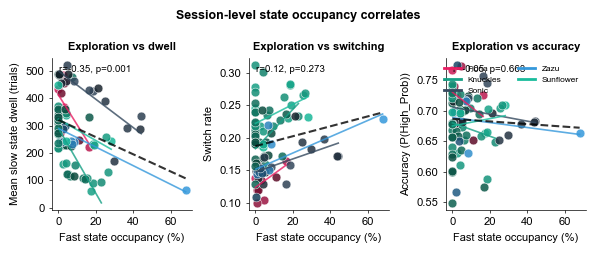

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(6, 2.5))

metrics = [
    ('mean_slow_dwell', 'Mean slow state dwell (trials)'),
    ('switch_rate',     'Switch rate'),
    ('accuracy',        'Accuracy (P(High_Prob))'),
]

for ax, (metric, ylabel) in zip(axes, metrics):
    for animal in animals_ordered:
        adf = session_df_filtered[session_df_filtered['animal'] == animal].dropna(
              subset=['fast_occ', metric])
        if len(adf) < 3:
            continue

        base_color = np.array(plt.matplotlib.colors.to_rgb(
                         ANIMAL_COLORS.get(animal, 'gray')))

        # Dots only — no connecting lines
        for _, row in adf.iterrows():
            color = np.clip(base_color * (0.4 + 0.6 * (1 - row['session_num_norm'])), 0, 1)
            ax.scatter(row['fast_occ'], row[metric],
                       color=color, s=40, alpha=0.85,
                       edgecolors='white', linewidths=0.4, zorder=3)

        # Per-animal regression line
        b, m = polyfit(adf['fast_occ'], adf[metric], 1)
        xline = np.linspace(adf['fast_occ'].min(), adf['fast_occ'].max(), 100)
        ax.plot(xline, b + m * xline,
                color=ANIMAL_COLORS.get(animal, 'gray'),
                linewidth=1.2, alpha=0.8, zorder=4)

    # Overall regression + correlation
    valid = session_df_filtered.dropna(subset=['fast_occ', metric])
    if len(valid) > 5:
        b, m  = polyfit(valid['fast_occ'], valid[metric], 1)
        xline = np.linspace(valid['fast_occ'].min(), valid['fast_occ'].max(), 100)
        ax.plot(xline, b + m * xline, color='black',
                linewidth=1.5, ls='--', alpha=0.8, zorder=5)
        r, p = spearmanr(valid['fast_occ'], valid[metric])
        ax.text(0.05, 0.95, f'r={r:.2f}, p={p:.3f}',
                transform=ax.transAxes, fontsize=FONTSIZE - 1,
                va='top', color='black')

    ax.set_xlabel('Fast state occupancy (%)', fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.spines[['top', 'right']].set_visible(False)

handles = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                      linewidth=2, label=a) for a in animals_ordered
           if a in session_df_filtered['animal'].values]
axes[2].legend(handles=handles, fontsize=FONTSIZE - 2, frameon=False, ncol=2, loc='upper right')

axes[0].set_title('Exploration vs dwell',    fontsize=FONTSIZE, fontweight='bold')
axes[1].set_title('Exploration vs switching', fontsize=FONTSIZE, fontweight='bold')
axes[2].set_title('Exploration vs accuracy',  fontsize=FONTSIZE, fontweight='bold')

fig.suptitle('Session-level state occupancy correlates',
             fontsize=FONTSIZE + 1, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'session_occupancy_correlates_v2.svg'),
            bbox_inches='tight')
plt.show()

/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; al

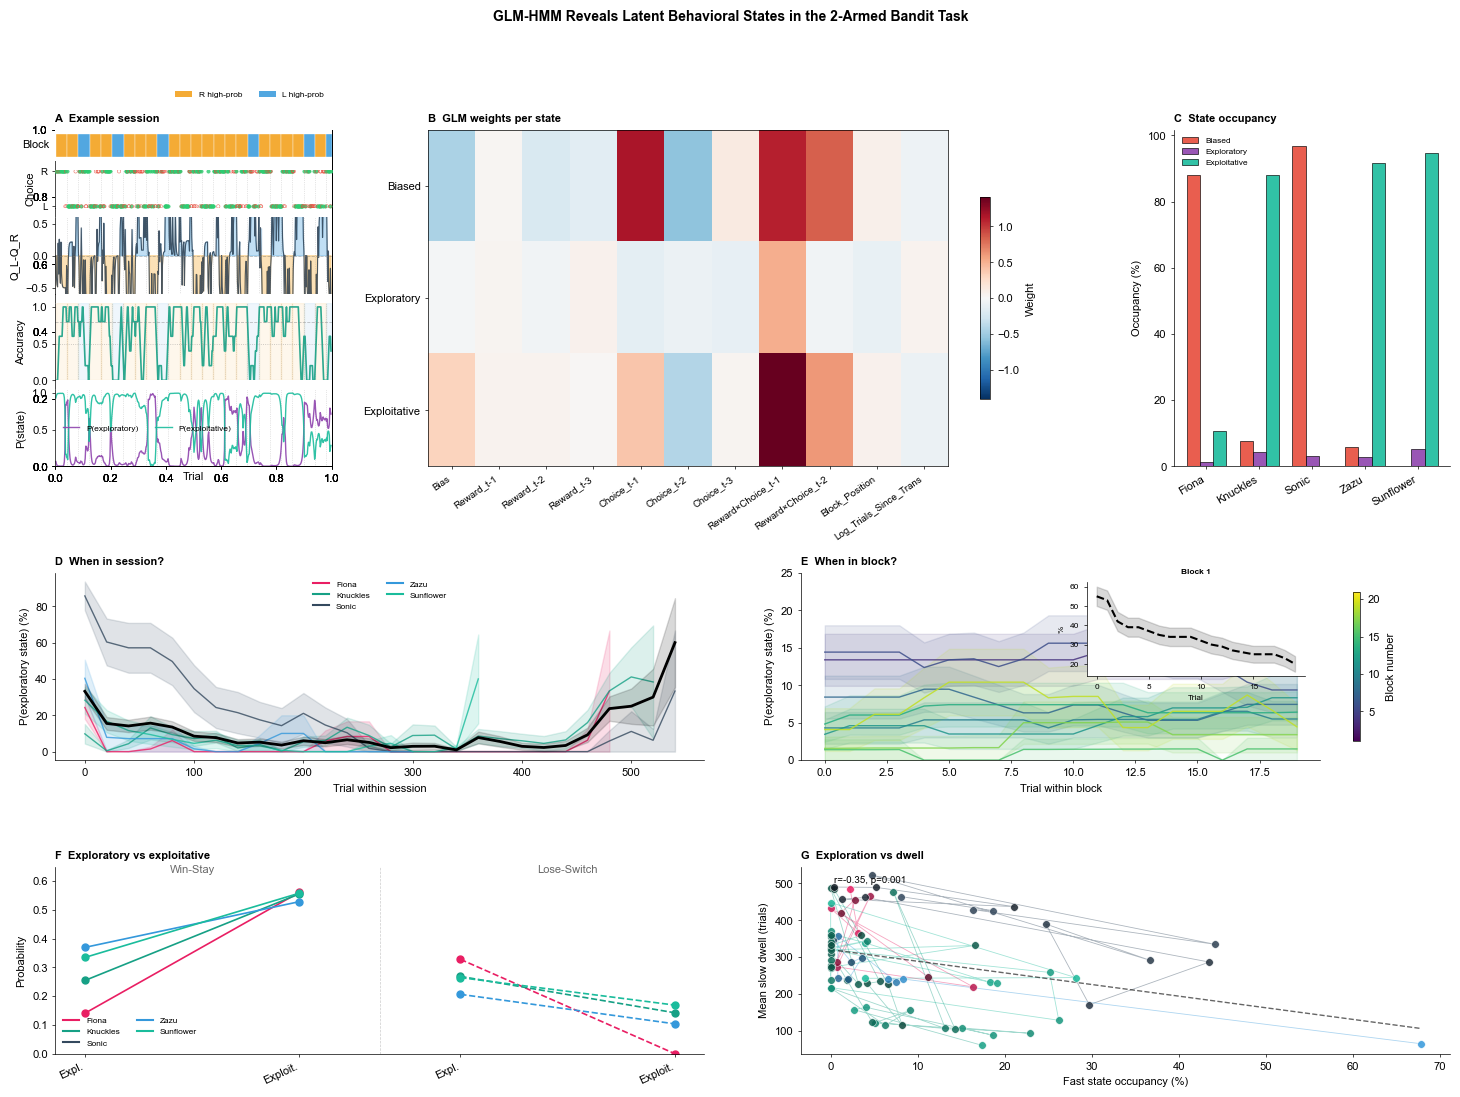

In [141]:
# ── Main Figure: GLM-HMM Behavioral State Discovery ──────────────────────────

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(
    3, 4,
    figure        = fig,
    hspace        = 0.45,
    wspace        = 0.35,
    height_ratios = [1.8, 1, 1],
)

# Panel layout
ax_block   = fig.add_subplot(gs[0, 0])      # A: block structure
ax_choice  = fig.add_subplot(gs[0, 0])      # shared with A
ax_qdiff   = fig.add_subplot(gs[0, 0])      # shared with A
ax_acc     = fig.add_subplot(gs[0, 0])      # shared with A
ax_pstate  = fig.add_subplot(gs[0, 0])      # shared with A

# Redo exemplar session as a nested gridspec
gs_A = gridspec.GridSpecFromSubplotSpec(
    5, 1,
    subplot_spec  = gs[0, 0],
    hspace        = 0.15,
    height_ratios = [0.4, 0.5, 1, 1, 1],
)
ax_A1 = fig.add_subplot(gs_A[0])
ax_A2 = fig.add_subplot(gs_A[1], sharex=ax_A1)
ax_A3 = fig.add_subplot(gs_A[2], sharex=ax_A1)
ax_A4 = fig.add_subplot(gs_A[3], sharex=ax_A1)
ax_A5 = fig.add_subplot(gs_A[4], sharex=ax_A1)

ax_B  = fig.add_subplot(gs[0, 1:3])         # B: GLM weights heatmap
ax_C  = fig.add_subplot(gs[0, 3])           # C: state occupancy per animal
ax_D1 = fig.add_subplot(gs[1, 0:2])         # D1: when in session
ax_D2 = fig.add_subplot(gs[1, 2:4])         # D2: when in block
ax_E  = fig.add_subplot(gs[2, 0:2])         # E: win-stay / lose-switch
ax_F  = fig.add_subplot(gs[2, 2:4])         # F: exploration vs dwell

# ── Panel A: Exemplar session ─────────────────────────────────────────────────
example_session = '2023-10-06_20231006_Knuckles_Reversal3.1'
animal          = 'Knuckles'

sdf_ex = df[df['Session_ID'] == example_session].sort_values('Trial').reset_index(drop=True)
sdf_ex['continuous_trial'] = range(len(sdf_ex))

best_k     = animal_results[animal]['best']
df_a_k     = best_k['df']
states_k   = best_k['states']
gamma_k    = best_k['gamma']
model_k    = best_k['model']

mean_dwell   = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
absorbing    = [k for k in range(K) if mean_dwell[k] > 10000]
valid        = [k for k in range(K) if k not in absorbing]
valid_dwells = [(k, mean_dwell[k]) for k in valid]
fast_state   = min(valid_dwells, key=lambda x: x[1])[0]
slow_state   = max(valid_dwells, key=lambda x: x[1])[0]

sess_mask_k  = df_a_k['Session_ID'] == example_session
gamma_ex     = gamma_k[sess_mask_k.values]

sdf_ex['Q_wave'] = sdf_ex['Q_left'] - sdf_ex['Q_right']
block_starts_ex  = sdf_ex.groupby('BlockCount')['continuous_trial'].min()

HIGH_RIGHT_COLOR = '#f39c12'
HIGH_LEFT_COLOR  = '#3498db'

# A1: block structure
for _, block_df in sdf_ex.groupby('BlockCount'):
    start = block_df['continuous_trial'].min()
    end   = block_df['continuous_trial'].max()
    color = HIGH_RIGHT_COLOR if block_df['High_Prob_Is_Right'].iloc[0] else HIGH_LEFT_COLOR
    ax_A1.barh(0, end - start + 1, left=start, height=0.6,
               color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
ax_A1.set_xlim(-1, len(sdf_ex))
ax_A1.set_ylim(-0.4, 0.4)
ax_A1.set_yticks([])
ax_A1.set_xticks([])
ax_A1.spines[['top','right','bottom','left']].set_visible(False)
ax_A1.set_ylabel('Block', fontsize=FONTSIZE, rotation=0, ha='right', va='center')
from matplotlib.patches import Patch
ax_A1.legend(handles=[
    Patch(facecolor=HIGH_RIGHT_COLOR, label='R high-prob', alpha=0.85),
    Patch(facecolor=HIGH_LEFT_COLOR,  label='L high-prob', alpha=0.85),
], fontsize=FONTSIZE-2, frameon=False, loc='upper right',
   bbox_to_anchor=(1.0, 2.5), ncol=2)

# A2: choices
for _, trial in sdf_ex.iterrows():
    fc = '#2ecc71' if trial['Outcome_Binary'] == 1 else 'none'
    ec = '#2ecc71' if trial['Outcome_Binary'] == 1 else '#e74c3c'
    ax_A2.scatter(trial['continuous_trial'], trial['Choice_Binary'],
                  s=6, facecolors=fc, edgecolors=ec,
                  alpha=0.8, linewidth=0.4, zorder=3)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A2.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A2.set_yticks([0, 1])
ax_A2.set_yticklabels(['L', 'R'], fontsize=FONTSIZE-1)
ax_A2.set_ylabel('Choice', fontsize=FONTSIZE)
ax_A2.spines[['top','bottom','right']].set_visible(False)
ax_A2.tick_params(axis='x', labelbottom=False, length=0)

# A3: Q_diff
ax_A3.plot(sdf_ex['continuous_trial'], sdf_ex['Q_wave'],
           color='#2c3e50', linewidth=0.8, alpha=0.85)
ax_A3.axhline(0, color='gray', ls='--', lw=0.6, alpha=0.5)
ax_A3.fill_between(sdf_ex['continuous_trial'], 0, sdf_ex['Q_wave'],
                   where=sdf_ex['Q_wave'] > 0, color=HIGH_LEFT_COLOR, alpha=0.3)
ax_A3.fill_between(sdf_ex['continuous_trial'], 0, sdf_ex['Q_wave'],
                   where=sdf_ex['Q_wave'] < 0, color=HIGH_RIGHT_COLOR, alpha=0.3)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A3.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A3.set_ylabel('Q_L-Q_R', fontsize=FONTSIZE)
ax_A3.set_yticks([-0.5, 0, 0.5])
ax_A3.set_ylim(-0.6, 0.6)
ax_A3.spines[['top','bottom','right']].set_visible(False)
ax_A3.tick_params(axis='x', labelbottom=False, length=0)

# A4: rolling accuracy
for _, block_df in sdf_ex.groupby('BlockCount'):
    start = block_df['continuous_trial'].min()
    end   = block_df['continuous_trial'].max()
    color = HIGH_RIGHT_COLOR if block_df['High_Prob_Is_Right'].iloc[0] else HIGH_LEFT_COLOR
    ax_A4.axvspan(start - 0.5, end + 0.5, alpha=0.08, color=color)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A4.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A4.plot(sdf_ex['continuous_trial'], sdf_ex['Rolling_Accuracy'],
           color=ANIMAL_COLORS[animal], linewidth=1.2, alpha=0.9)
ax_A4.axhline(0.8, color='gray', ls='--', lw=0.6, alpha=0.5)
ax_A4.axhline(0.5, color='gray', ls=':',  lw=0.6, alpha=0.5)
ax_A4.set_ylim(0, 1.05)
ax_A4.set_yticks([0, 0.5, 1.0])
ax_A4.set_ylabel('Accuracy', fontsize=FONTSIZE)
ax_A4.spines[['top','bottom','right']].set_visible(False)
ax_A4.tick_params(axis='x', labelbottom=False, length=0)

# A5: P(state)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A5.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A5.plot(sdf_ex['continuous_trial'], gamma_ex[:, fast_state],
           color='#8e44ad', linewidth=1.0, label='P(exploratory)', alpha=0.9)
ax_A5.plot(sdf_ex['continuous_trial'], gamma_ex[:, slow_state],
           color='#1abc9c', linewidth=1.0, label='P(exploitative)', alpha=0.9)
ax_A5.set_ylim(0, 1.05)
ax_A5.set_yticks([0, 0.5, 1.0])
ax_A5.set_ylabel('P(state)', fontsize=FONTSIZE)
ax_A5.set_xlabel('Trial', fontsize=FONTSIZE)
ax_A5.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2)
ax_A5.spines[['top','right']].set_visible(False)

ax_A1.set_title('A  Example session', fontsize=FONTSIZE, fontweight='bold', loc='left')

# ── Panel B: GLM weight heatmap ───────────────────────────────────────────────
ax_B.set_title('B  GLM weights per state', fontsize=FONTSIZE, fontweight='bold', loc='left')

W    = model_k3.weights
vmax = np.abs(W).max()
im   = ax_B.imshow(W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax_B.set_yticks(range(3))
ax_B.set_yticklabels([STATE_NAMES[k] for k in range(3)], fontsize=FONTSIZE)
ax_B.set_xticks(range(len(names_AR)))
ax_B.set_xticklabels(names_AR, rotation=35, ha='right', fontsize=FONTSIZE-1)
plt.colorbar(im, ax=ax_B, shrink=0.6, label='Weight')

# ── Panel C: State occupancy per animal ───────────────────────────────────────
ax_C.set_title('C  State occupancy', fontsize=FONTSIZE, fontweight='bold', loc='left')

x     = np.arange(len(animals_ordered))
width = 0.25

for ki, (k, name) in enumerate(STATE_NAMES.items()):
    occs = []
    for animal_n in animals_ordered:
        mask  = (states_k3 == k) & (df_AR['Animal_Name'] == animal_n)
        total = (df_AR['Animal_Name'] == animal_n).sum()
        occs.append(mask.sum() / total * 100)
    ax_C.bar(x + (ki - 1) * width, occs, width,
             label=name, color=STATE_COLORS_K3[k],
             edgecolor='black', linewidth=LINE_WIDTH, alpha=0.9)

ax_C.set_xticks(x)
ax_C.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE)
ax_C.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
ax_C.legend(fontsize=FONTSIZE-2, frameon=False, ncol=1)
ax_C.spines[['top', 'right']].set_visible(False)

# ── Panel D1: When in session ─────────────────────────────────────────────────
ax_D1.set_title('D  When in session?', fontsize=FONTSIZE, fontweight='bold', loc='left')

df['Session_Trial']     = df.groupby('Session_ID').cumcount()
df['GLM_Fast']          = (df['GLM_Animal_State'] == 'Exploratory').astype(float)
df['Session_Trial_Bin'] = (df['Session_Trial'] // 20) * 20

for animal_n in animals_ordered:
    adf = df[df['Animal_Name'] == animal_n]
    sf  = adf.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast'].mean().reset_index()
    bs  = sf.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
    bs  = bs[bs['count'] >= 3]
    ax_D1.plot(bs.index, bs['mean'] * 100,
               color=ANIMAL_COLORS.get(animal_n, 'gray'), linewidth=1, alpha=0.8)
    ax_D1.fill_between(bs.index,
                       (bs['mean'] - bs['sem']) * 100,
                       (bs['mean'] + bs['sem']) * 100,
                       color=ANIMAL_COLORS.get(animal_n, 'gray'), alpha=0.15)

# Overall mean
sf_all = df.groupby(['Session_ID', 'Session_Trial_Bin'])['GLM_Fast'].mean().reset_index()
bs_all = sf_all.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
bs_all = bs_all[bs_all['count'] >= 5]
ax_D1.plot(bs_all.index, bs_all['mean'] * 100,
           color='black', linewidth=2, zorder=10)
ax_D1.fill_between(bs_all.index,
                   (bs_all['mean'] - bs_all['sem']) * 100,
                   (bs_all['mean'] + bs_all['sem']) * 100,
                   color='black', alpha=0.15, zorder=10)

ax_D1.set_xlabel('Trial within session', fontsize=FONTSIZE)
ax_D1.set_ylabel('P(exploratory state) (%)', fontsize=FONTSIZE)
ax_D1.spines[['top', 'right']].set_visible(False)

handles_animals = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                               linewidth=1.5, label=a) for a in animals_ordered]
ax_D1.legend(handles=handles_animals, fontsize=FONTSIZE-2, frameon=False, ncol=2)

# ── Panel D2: When in block ───────────────────────────────────────────────────
ax_D2.set_title('E  When in block?', fontsize=FONTSIZE, fontweight='bold', loc='left')

MIN_BLOCK      = df['BlockCount'].min()
MAX_BLOCKS     = 20
BLOCKS_TO_SHOW = list(range(MIN_BLOCK + 2, MIN_BLOCK + MAX_BLOCKS, 2))
cmap_blocks    = plt.cm.viridis

for block_n in BLOCKS_TO_SHOW:
    bd    = df[df['BlockCount'] == block_n]
    sb    = bd.groupby(['Session_ID', 'Trial_in_Block'])['GLM_Fast'].mean().reset_index()
    stats = sb.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem, 'count'])
    stats = stats[stats['count'] >= 5]
    ax_D2.plot(stats.index, stats['mean'] * 100,
               color=cmap_blocks(block_n / (MIN_BLOCK + MAX_BLOCKS)),
               linewidth=1, alpha=0.85)
    ax_D2.fill_between(stats.index,
                       (stats['mean'] - stats['sem']) * 100,
                       (stats['mean'] + stats['sem']) * 100,
                       color=cmap_blocks(block_n / (MIN_BLOCK + MAX_BLOCKS)), alpha=0.12)

ax_D2.set_ylim(0, 25)
ax_D2.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax_D2.set_ylabel('P(exploratory state) (%)', fontsize=FONTSIZE)
ax_D2.spines[['top', 'right']].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap_blocks,
                            norm=plt.Normalize(vmin=MIN_BLOCK, vmax=MIN_BLOCK + MAX_BLOCKS))
sm.set_array([])
plt.colorbar(sm, ax=ax_D2, label='Block number', shrink=0.8)

# Inset: block 1
ax_inset = ax_D2.inset_axes([0.55, 0.45, 0.42, 0.50])
b1d   = df[df['BlockCount'] == MIN_BLOCK]
sb1   = b1d.groupby(['Session_ID', 'Trial_in_Block'])['GLM_Fast'].mean().reset_index()
st1   = sb1.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem, 'count'])
st1   = st1[st1['count'] >= 5]
ax_inset.plot(st1.index, st1['mean'] * 100, color='black', linewidth=1.5, ls='--')
ax_inset.fill_between(st1.index,
                      (st1['mean'] - st1['sem']) * 100,
                      (st1['mean'] + st1['sem']) * 100,
                      color='black', alpha=0.15)
ax_inset.set_title(f'Block {MIN_BLOCK}', fontsize=FONTSIZE-2, fontweight='bold')
ax_inset.set_xlabel('Trial', fontsize=FONTSIZE-2)
ax_inset.set_ylabel('%', fontsize=FONTSIZE-2)
ax_inset.tick_params(labelsize=FONTSIZE-2)
ax_inset.spines[['top', 'right']].set_visible(False)

# ── Panel E: Win-stay / Lose-switch ──────────────────────────────────────────
ax_E.set_title('F  Exploratory vs exploitative', fontsize=FONTSIZE, fontweight='bold', loc='left')

for animal_n in animals_ordered:
    vals = {}
    for k, label in [(1, 'exploratory'), (2, 'exploitative')]:
        mask = (states_k3 == k) & (df_AR['Animal_Name'] == animal_n)
        sdf_s = df_AR[mask]
        if len(sdf_s) < 20:
            continue
        vals[label] = {
            'ws': ((sdf_s['Outcome_Binary'].shift(1) == 1) &
                   (sdf_s['Choice_Binary'] == sdf_s['Choice_Binary'].shift(1))).mean(),
            'ls': ((sdf_s['Outcome_Binary'].shift(1) == 0) &
                   (sdf_s['Choice_Binary'] != sdf_s['Choice_Binary'].shift(1))).mean(),
        }
    if 'exploratory' not in vals or 'exploitative' not in vals:
        continue

    color = ANIMAL_COLORS.get(animal_n, 'gray')
    ax_E.plot([0, 0.4], [vals['exploratory']['ws'], vals['exploitative']['ws']],
              'o-', color=color, linewidth=1.2, markersize=5)
    ax_E.plot([0.7, 1.1], [vals['exploratory']['ls'], vals['exploitative']['ls']],
              'o--', color=color, linewidth=1.2, markersize=5)

ax_E.set_xticks([0, 0.4, 0.7, 1.1])
ax_E.set_xticklabels(['Expl.', 'Exploit.', 'Expl.', 'Exploit.'],
                     fontsize=FONTSIZE, rotation=25, ha='right')
ax_E.set_ylabel('Probability', fontsize=FONTSIZE)
ax_E.set_ylim(0, 0.65)
ax_E.axvline(0.55, color='gray', lw=0.5, ls='--', alpha=0.4)
ax_E.text(0.2,  0.63, 'Win-Stay',    ha='center', fontsize=FONTSIZE, color='dimgray')
ax_E.text(0.9,  0.63, 'Lose-Switch', ha='center', fontsize=FONTSIZE, color='dimgray')
ax_E.spines[['top', 'right']].set_visible(False)

handles_e = [plt.Line2D([0], [0], color=ANIMAL_COLORS.get(a, 'gray'),
                         linewidth=1.5, label=a) for a in animals_ordered]
ax_E.legend(handles=handles_e, fontsize=FONTSIZE-2, frameon=False, ncol=2)

# ── Panel F: Exploration vs dwell ─────────────────────────────────────────────
ax_F.set_title('G  Exploration vs dwell', fontsize=FONTSIZE, fontweight='bold', loc='left')

for animal_n in animals_ordered:
    adf = session_df_filtered[session_df_filtered['animal'] == animal_n].dropna(
          subset=['fast_occ', 'mean_slow_dwell']).sort_values('session_num')
    if len(adf) == 0:
        continue
    base_color = np.array(plt.matplotlib.colors.to_rgb(ANIMAL_COLORS.get(animal_n, 'gray')))
    for _, row in adf.iterrows():
        color = np.clip(base_color * (0.4 + 0.6 * (1 - row['session_num_norm'])), 0, 1)
        ax_F.scatter(row['fast_occ'], row['mean_slow_dwell'],
                     color=color, s=30, alpha=0.85,
                     edgecolors='white', linewidths=0.4, zorder=3)
    ax_F.plot(adf['fast_occ'], adf['mean_slow_dwell'],
              color=ANIMAL_COLORS.get(animal_n, 'gray'), linewidth=0.6, alpha=0.4)

valid = session_df_filtered.dropna(subset=['fast_occ', 'mean_slow_dwell'])
b, m  = polyfit(valid['fast_occ'], valid['mean_slow_dwell'], 1)
xline = np.linspace(valid['fast_occ'].min(), valid['fast_occ'].max(), 100)
ax_F.plot(xline, b + m * xline, color='black', linewidth=1, ls='--', alpha=0.6)
r, p = spearmanr(valid['fast_occ'], valid['mean_slow_dwell'])
ax_F.text(0.05, 0.95, f'r={r:.2f}, p={p:.3f}',
          transform=ax_F.transAxes, fontsize=FONTSIZE-1, va='top')
ax_F.set_xlabel('Fast state occupancy (%)', fontsize=FONTSIZE)
ax_F.set_ylabel('Mean slow dwell (trials)', fontsize=FONTSIZE)
ax_F.spines[['top', 'right']].set_visible(False)

fig.suptitle('GLM-HMM Reveals Latent Behavioral States in the 2-Armed Bandit Task',
             fontsize=FONTSIZE + 2, fontweight='bold')

plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_glmhmm_final.svg'), bbox_inches='tight')
plt.show()

/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/opt/anaconda3/envs/ssm_env_1/lib/python3.13/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; al

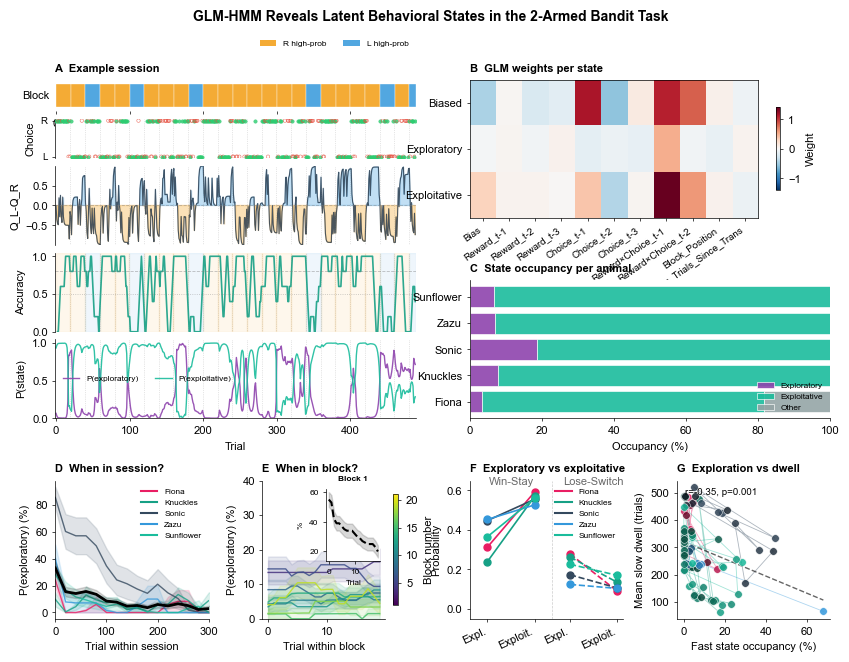

In [145]:
# ── Main Figure: GLM-HMM Behavioral State Discovery ──────────────────────────

fig = plt.figure(figsize=(10, 7))

# Outer grid: 3 rows × 4 columns
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: rows 0-1, cols 0-1
gs_A = gridspec.GridSpecFromSubplotSpec(
    5, 1,
    subplot_spec  = gs[0:2, 0:2],
    hspace        = 0.12,
    height_ratios = [0.4, 0.5, 1, 1, 1],
)
ax_A1 = fig.add_subplot(gs_A[0])
ax_A2 = fig.add_subplot(gs_A[1], sharex=ax_A1)
ax_A3 = fig.add_subplot(gs_A[2], sharex=ax_A1)
ax_A4 = fig.add_subplot(gs_A[3], sharex=ax_A1)
ax_A5 = fig.add_subplot(gs_A[4], sharex=ax_A1)

# Panel B: row 0, col 2-3
ax_B = fig.add_subplot(gs[0, 2:4])

# Panel C: row 1, col 2-3
ax_C = fig.add_subplot(gs[1, 2:4])

# Bottom row: 4 panels across cols 0-3
ax_D1 = fig.add_subplot(gs[2, 0])
ax_D2 = fig.add_subplot(gs[2, 1])
ax_E  = fig.add_subplot(gs[2, 2])
ax_F  = fig.add_subplot(gs[2, 3])

# ── Panel A: Exemplar session ─────────────────────────────────────────────────
example_session = '2023-10-06_20231006_Knuckles_Reversal3.1'
animal          = 'Knuckles'

sdf_ex = df[df['Session_ID'] == example_session].sort_values('Trial').reset_index(drop=True)
sdf_ex['continuous_trial'] = range(len(sdf_ex))

best_k       = animal_results[animal]['best']
df_a_k       = best_k['df']
gamma_k      = best_k['gamma']
model_k      = best_k['model']
mean_dwell_k = 1.0 / np.maximum(1 - np.diag(model_k.transitions), 1e-6)
fast_k       = np.argmin(mean_dwell_k)
slow_k       = np.argmax(np.clip(mean_dwell_k, 0, 1000))
sess_mask_k  = df_a_k['Session_ID'] == example_session
gamma_ex     = gamma_k[sess_mask_k.values]

sdf_ex['Q_wave']  = sdf_ex['Q_left'] - sdf_ex['Q_right']
block_starts_ex   = sdf_ex.groupby('BlockCount')['continuous_trial'].min()

HIGH_RIGHT_COLOR = '#f39c12'
HIGH_LEFT_COLOR  = '#3498db'

# A1: block structure
for _, block_df in sdf_ex.groupby('BlockCount'):
    start = block_df['continuous_trial'].min()
    end   = block_df['continuous_trial'].max()
    color = HIGH_RIGHT_COLOR if block_df['High_Prob_Is_Right'].iloc[0] else HIGH_LEFT_COLOR
    ax_A1.barh(0, end - start + 1, left=start, height=0.6,
               color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
ax_A1.set_xlim(-1, len(sdf_ex))
ax_A1.set_ylim(-0.4, 0.4)
ax_A1.set_yticks([])
# ax_A1.set_xticks([])
ax_A1.spines[['top','right','bottom','left']].set_visible(False)
ax_A1.set_ylabel('Block', fontsize=FONTSIZE, rotation=0, ha='right', va='center')
from matplotlib.patches import Patch
ax_A1.legend(handles=[
    Patch(facecolor=HIGH_RIGHT_COLOR, label='R high-prob', alpha=0.85),
    Patch(facecolor=HIGH_LEFT_COLOR,  label='L high-prob', alpha=0.85),
], fontsize=FONTSIZE-2, frameon=False, loc='upper right',
   bbox_to_anchor=(1.0, 2.5), ncol=2)

# A2: choices
for _, trial in sdf_ex.iterrows():
    fc = '#2ecc71' if trial['Outcome_Binary'] == 1 else 'none'
    ec = '#2ecc71' if trial['Outcome_Binary'] == 1 else '#e74c3c'
    ax_A2.scatter(trial['continuous_trial'], trial['Choice_Binary'],
                  s=6, facecolors=fc, edgecolors=ec,
                  alpha=0.8, linewidth=0.4, zorder=3)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A2.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A2.set_yticks([0, 1])
ax_A2.set_yticklabels(['L', 'R'], fontsize=FONTSIZE-1)
ax_A2.set_ylabel('Choice', fontsize=FONTSIZE)
ax_A2.spines[['top','bottom','right']].set_visible(False)
ax_A2.tick_params(axis='x', labelbottom=False, length=0)

# A3: Q_diff
ax_A3.plot(sdf_ex['continuous_trial'], sdf_ex['Q_wave'],
           color='#2c3e50', linewidth=0.8, alpha=0.85)
ax_A3.axhline(0, color='gray', ls='--', lw=0.6, alpha=0.5)
ax_A3.fill_between(sdf_ex['continuous_trial'], 0, sdf_ex['Q_wave'],
                   where=sdf_ex['Q_wave'] > 0, color=HIGH_LEFT_COLOR, alpha=0.3)
ax_A3.fill_between(sdf_ex['continuous_trial'], 0, sdf_ex['Q_wave'],
                   where=sdf_ex['Q_wave'] < 0, color=HIGH_RIGHT_COLOR, alpha=0.3)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A3.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A3.set_ylabel('Q_L-Q_R', fontsize=FONTSIZE)
ax_A3.set_yticks([-0.5, 0, 0.5])
ax_A3.set_ylim(-1, 1)
ax_A3.spines[['top','bottom','right']].set_visible(False)
ax_A3.tick_params(axis='x', labelbottom=False, length=0)

# A4: rolling accuracy
for _, block_df in sdf_ex.groupby('BlockCount'):
    start = block_df['continuous_trial'].min()
    end   = block_df['continuous_trial'].max()
    color = HIGH_RIGHT_COLOR if block_df['High_Prob_Is_Right'].iloc[0] else HIGH_LEFT_COLOR
    ax_A4.axvspan(start - 0.5, end + 0.5, alpha=0.08, color=color)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A4.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A4.plot(sdf_ex['continuous_trial'], sdf_ex['Rolling_Accuracy'],
           color=ANIMAL_COLORS[animal], linewidth=1.2, alpha=0.9)
ax_A4.axhline(0.8, color='gray', ls='--', lw=0.6, alpha=0.5)
ax_A4.axhline(0.5, color='gray', ls=':',  lw=0.6, alpha=0.5)
ax_A4.set_ylim(0, 1.05)
ax_A4.set_yticks([0, 0.5, 1.0])
ax_A4.set_ylabel('Accuracy', fontsize=FONTSIZE)
ax_A4.spines[['top','bottom','right']].set_visible(False)
ax_A4.tick_params(axis='x', labelbottom=False, length=0)

# A5: P(state)
for block, start in block_starts_ex.items():
    if start > 0:
        ax_A5.axvline(start - 0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A5.plot(sdf_ex['continuous_trial'], gamma_ex[:, fast_k],
           color='#8e44ad', linewidth=1.0, label='P(exploratory)', alpha=0.9)
ax_A5.plot(sdf_ex['continuous_trial'], gamma_ex[:, slow_k],
           color='#1abc9c', linewidth=1.0, label='P(exploitative)', alpha=0.9)
ax_A5.set_ylim(0, 1.05)
ax_A5.set_yticks([0, 0.5, 1.0])
ax_A5.set_ylabel('P(state)', fontsize=FONTSIZE)
ax_A5.set_xlabel('Trial', fontsize=FONTSIZE)
ax_A5.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2)
ax_A5.spines[['top','right']].set_visible(False)
ax_A1.set_title('A  Example session', fontsize=FONTSIZE, fontweight='bold', loc='left')

# ── Panel B: GLM weight heatmap ───────────────────────────────────────────────
ax_B.set_title('B  GLM weights per state', fontsize=FONTSIZE, fontweight='bold', loc='left')
W    = model_k3.weights
vmax = np.abs(W).max()
im   = ax_B.imshow(W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax_B.set_yticks(range(3))
ax_B.set_yticklabels([STATE_NAMES[k] for k in range(3)], fontsize=FONTSIZE)
ax_B.set_xticks(range(len(names_AR)))
ax_B.set_xticklabels(names_AR, rotation=35, ha='right', fontsize=FONTSIZE-1)
plt.colorbar(im, ax=ax_B, shrink=0.6, label='Weight')

# # ── Panel C: State occupancy per animal ───────────────────────────────────────
# ax_C.set_title('C  State occupancy per animal', fontsize=FONTSIZE, fontweight='bold', loc='left')
# x     = np.arange(len(animals_ordered))
# width = 0.25
# for ki, (k, name) in enumerate(STATE_NAMES.items()):
#     occs = []
#     for animal_n in animals_ordered:
#         mask  = (states_k3 == k) & (df_AR['Animal_Name'] == animal_n)
#         total = (df_AR['Animal_Name'] == animal_n).sum()
#         occs.append(mask.sum() / total * 100)
#     ax_C.bar(x + (ki - 1) * width, occs, width,
#              label=name, color=STATE_COLORS_K3[k],
#              edgecolor='black', linewidth=LINE_WIDTH, alpha=0.9)
# ax_C.set_xticks(x)
# ax_C.set_xticklabels(animals_ordered, rotation=30, ha='right', fontsize=FONTSIZE)
# ax_C.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
# ax_C.legend(fontsize=FONTSIZE-2, frameon=False, ncol=1)
# ax_C.spines[['top', 'right']].set_visible(False)
# ── Panel C: State occupancy per animal — from per-animal model ───────────────
ax_C.set_title('C  State occupancy per animal', fontsize=FONTSIZE, fontweight='bold', loc='left')

y     = np.arange(len(animals_ordered))
lefts = np.zeros(len(animals_ordered))

state_labels  = ['Exploratory', 'Exploitative', 'Other']
state_colors  = ['#8e44ad', '#1abc9c', '#95a5a6']

for label, color in zip(state_labels, state_colors):
    occs = []
    for animal_n in animals_ordered:
        mask  = df['Animal_Name'] == animal_n
        total = mask.sum()
        occ   = ((df[mask]['GLM_Animal_State'] == label).sum() / total) * 100
        occs.append(occ)

    ax_C.barh(y, occs, left=lefts,
              label=label, color=color,
              edgecolor='white', linewidth=0.5, alpha=0.9)
    lefts += np.array(occs)

ax_C.set_yticks(y)
ax_C.set_yticklabels(animals_ordered[::-1] if False else animals_ordered, fontsize=FONTSIZE)
ax_C.set_xlabel('Occupancy (%)', fontsize=FONTSIZE)
ax_C.set_xlim(0, 100)
ax_C.legend(fontsize=FONTSIZE-2, frameon=False, loc='lower right')
ax_C.spines[['top', 'right']].set_visible(False)
# # ── Panel C: State occupancy per animal — horizontal stacked 100% bar ─────────
# ax_C.set_title('C  State occupancy per animal', fontsize=FONTSIZE, fontweight='bold', loc='left')

# y     = np.arange(len(animals_ordered))
# lefts = np.zeros(len(animals_ordered))

# for k, name in STATE_NAMES.items():
#     occs = []
#     for animal_n in animals_ordered:
#         mask  = (states_k3 == k) & (df_AR['Animal_Name'] == animal_n)
#         total = (df_AR['Animal_Name'] == animal_n).sum()
#         occs.append(mask.sum() / total * 100)

#     ax_C.barh(y, occs, left=lefts,
#               label=name, color=STATE_COLORS_K3[k],
#               edgecolor='white', linewidth=0.5, alpha=0.9)
#     lefts += np.array(occs)

# ax_C.set_yticks(y)
# ax_C.set_yticklabels(animals_ordered, fontsize=FONTSIZE)
# ax_C.set_xlabel('Occupancy (%)', fontsize=FONTSIZE)
# ax_C.set_xlim(0, 100)
# # reverse order of the y-ticks
# ax_C.set_yticks(y[::-1])
# ax_C.set_yticklabels(animals_ordered[::-1], fontsize=FONTSIZE)
# ax_C.legend(fontsize=FONTSIZE-2, frameon=False, loc='lower right')
# ax_C.spines[['top', 'right']].set_visible(False)

# ── Panel D1: When in session ─────────────────────────────────────────────────
ax_D1.set_title('D  When in session?', fontsize=FONTSIZE, fontweight='bold', loc='left')
df['Session_Trial']     = df.groupby('Session_ID').cumcount()
df['GLM_Fast']          = (df['GLM_Animal_State'] == 'Exploratory').astype(float)
df['Session_Trial_Bin'] = (df['Session_Trial'] // 20) * 20

for animal_n in animals_ordered:
    adf = df[df['Animal_Name'] == animal_n]
    sf  = adf.groupby(['Session_ID','Session_Trial_Bin'])['GLM_Fast'].mean().reset_index()
    bs  = sf.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
    bs  = bs[bs['count'] >= 3]
    ax_D1.plot(bs.index, bs['mean']*100,
               color=ANIMAL_COLORS.get(animal_n,'gray'), linewidth=1, alpha=0.8)
    ax_D1.fill_between(bs.index,
                       (bs['mean']-bs['sem'])*100,
                       (bs['mean']+bs['sem'])*100,
                       color=ANIMAL_COLORS.get(animal_n,'gray'), alpha=0.15)

sf_all = df.groupby(['Session_ID','Session_Trial_Bin'])['GLM_Fast'].mean().reset_index()
bs_all = sf_all.groupby('Session_Trial_Bin')['GLM_Fast'].agg(['mean', sem, 'count'])
bs_all = bs_all[bs_all['count'] >= 5]
ax_D1.plot(bs_all.index, bs_all['mean']*100, color='black', linewidth=2, zorder=10)
ax_D1.fill_between(bs_all.index,
                   (bs_all['mean']-bs_all['sem'])*100,
                   (bs_all['mean']+bs_all['sem'])*100,
                   color='black', alpha=0.15, zorder=10)
ax_D1.set_xlabel('Trial within session', fontsize=FONTSIZE)
ax_D1.set_ylabel('P(exploratory) (%)', fontsize=FONTSIZE)
ax_D1.set_xlim(0, 300)
ax_D1.spines[['top','right']].set_visible(False)
handles_d = [plt.Line2D([0],[0], color=ANIMAL_COLORS.get(a,'gray'),
                         linewidth=1.5, label=a) for a in animals_ordered]
ax_D1.legend(handles=handles_d, fontsize=FONTSIZE-2, frameon=False, ncol=1)

# ── Panel D2: When in block ───────────────────────────────────────────────────
ax_D2.set_title('E  When in block?', fontsize=FONTSIZE, fontweight='bold', loc='left')
MIN_BLOCK      = df['BlockCount'].min()
MAX_BLOCKS     = 20
BLOCKS_TO_SHOW = list(range(MIN_BLOCK+2, MIN_BLOCK+MAX_BLOCKS, 2))
cmap_b         = plt.cm.viridis

for block_n in BLOCKS_TO_SHOW:
    bd    = df[df['BlockCount'] == block_n]
    sb    = bd.groupby(['Session_ID','Trial_in_Block'])['GLM_Fast'].mean().reset_index()
    stats = sb.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem, 'count'])
    stats = stats[stats['count'] >= 5]
    ax_D2.plot(stats.index, stats['mean']*100,
               color=cmap_b(block_n/(MIN_BLOCK+MAX_BLOCKS)), linewidth=1, alpha=0.85)
    ax_D2.fill_between(stats.index,
                       (stats['mean']-stats['sem'])*100,
                       (stats['mean']+stats['sem'])*100,
                       color=cmap_b(block_n/(MIN_BLOCK+MAX_BLOCKS)), alpha=0.12)

ax_D2.set_ylim(0, 40)
ax_D2.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax_D2.set_ylabel('P(exploratory) (%)', fontsize=FONTSIZE)
ax_D2.spines[['top','right']].set_visible(False)
sm = plt.cm.ScalarMappable(cmap=cmap_b,
                            norm=plt.Normalize(vmin=MIN_BLOCK, vmax=MIN_BLOCK+MAX_BLOCKS))
sm.set_array([])
plt.colorbar(sm, ax=ax_D2, label='Block number', shrink=0.8)

ax_inset = ax_D2.inset_axes([0.52, 0.42, 0.44, 0.52])
b1d  = df[df['BlockCount'] == MIN_BLOCK]
sb1  = b1d.groupby(['Session_ID','Trial_in_Block'])['GLM_Fast'].mean().reset_index()
st1  = sb1.groupby('Trial_in_Block')['GLM_Fast'].agg(['mean', sem, 'count'])
st1  = st1[st1['count'] >= 5]
ax_inset.plot(st1.index, st1['mean']*100, color='black', linewidth=1.5, ls='--')
ax_inset.fill_between(st1.index,
                      (st1['mean']-st1['sem'])*100,
                      (st1['mean']+st1['sem'])*100,
                      color='black', alpha=0.15)
ax_inset.set_title(f'Block {MIN_BLOCK}', fontsize=FONTSIZE-2, fontweight='bold')
ax_inset.set_xlabel('Trial', fontsize=FONTSIZE-2)
ax_inset.set_ylabel('%', fontsize=FONTSIZE-2)
ax_inset.tick_params(labelsize=FONTSIZE-2)
ax_inset.spines[['top','right']].set_visible(False)

# ── Panel E: Win-stay / Lose-switch ──────────────────────────────────────────
ax_E.set_title('F  Exploratory vs exploitative', fontsize=FONTSIZE, fontweight='bold', loc='left')

for animal_n in animals_ordered:
    # Get correct fast/slow state indices for this animal
    best_n     = animal_results[animal_n]['best']
    model_n    = best_n['model']
    K_n        = best_n['K']
    df_a_n     = best_n['df']
    states_n   = best_n['states']

    mean_dwell_n = 1.0 / np.maximum(1 - np.diag(model_n.transitions), 1e-6)
    absorbing_n  = [k for k in range(K_n) if mean_dwell_n[k] > 10000]
    valid_n      = [k for k in range(K_n) if k not in absorbing_n]
    valid_dw_n   = [(k, mean_dwell_n[k]) for k in valid_n]
    fast_n       = min(valid_dw_n, key=lambda x: x[1])[0]
    slow_n       = max(valid_dw_n, key=lambda x: x[1])[0]

    vals = {}
    for state_idx, label in [(fast_n, 'exploratory'), (slow_n, 'exploitative')]:
        mask  = states_n == state_idx
        sdf_s = df_a_n[mask]
        if len(sdf_s) < 20:
            continue
        vals[label] = {
            'ws': ((sdf_s['Outcome_Binary'].shift(1)==1) &
                   (sdf_s['Choice_Binary']==sdf_s['Choice_Binary'].shift(1))).mean(),
            'ls': ((sdf_s['Outcome_Binary'].shift(1)==0) &
                   (sdf_s['Choice_Binary']!=sdf_s['Choice_Binary'].shift(1))).mean(),
        }
    if 'exploratory' not in vals or 'exploitative' not in vals:
        continue

    color = ANIMAL_COLORS.get(animal_n, 'gray')
    ax_E.plot([0, 0.4], [vals['exploratory']['ws'], vals['exploitative']['ws']],
              'o-', color=color, linewidth=1.2, markersize=5)
    ax_E.plot([0.7, 1.1], [vals['exploratory']['ls'], vals['exploitative']['ls']],
              'o--', color=color, linewidth=1.2, markersize=5)

ax_E.set_xticks([0, 0.4, 0.7, 1.1])
ax_E.set_xticklabels(['Expl.','Exploit.','Expl.','Exploit.'],
                     fontsize=FONTSIZE, rotation=25, ha='right')
ax_E.set_ylabel('Probability', fontsize=FONTSIZE)
ax_E.set_ylim(-0.05, 0.65)
ax_E.set_xlim(-0.15, 1.15)
ax_E.axvline(0.55, color='gray', lw=0.5, ls='--', alpha=0.4)
ax_E.text(0.2,  0.63, 'Win-Stay',    ha='center', fontsize=FONTSIZE, color='dimgray')
ax_E.text(0.9,  0.63, 'Lose-Switch', ha='center', fontsize=FONTSIZE, color='dimgray')
ax_E.spines[['top','right']].set_visible(False)
handles_e = [plt.Line2D([0],[0], color=ANIMAL_COLORS.get(a,'gray'),
                         linewidth=1.5, label=a) for a in animals_ordered]
ax_E.legend(handles=handles_e, fontsize=FONTSIZE-2, frameon=False, ncol=1)
# ── Panel F: Exploration vs dwell ─────────────────────────────────────────────
ax_F.set_title('G  Exploration vs dwell', fontsize=FONTSIZE, fontweight='bold', loc='left')
for animal_n in animals_ordered:
    adf = session_df_filtered[session_df_filtered['animal']==animal_n].dropna(
          subset=['fast_occ','mean_slow_dwell']).sort_values('session_num')
    if len(adf) == 0:
        continue
    base_color = np.array(plt.matplotlib.colors.to_rgb(ANIMAL_COLORS.get(animal_n,'gray')))
    for _, row in adf.iterrows():
        color = np.clip(base_color*(0.4+0.6*(1-row['session_num_norm'])), 0, 1)
        ax_F.scatter(row['fast_occ'], row['mean_slow_dwell'],
                     color=color, s=30, alpha=0.85,
                     edgecolors='white', linewidths=0.4, zorder=3)
    ax_F.plot(adf['fast_occ'], adf['mean_slow_dwell'],
              color=ANIMAL_COLORS.get(animal_n,'gray'), linewidth=0.6, alpha=0.4)

valid = session_df_filtered.dropna(subset=['fast_occ','mean_slow_dwell'])
b, m  = polyfit(valid['fast_occ'], valid['mean_slow_dwell'], 1)
xline = np.linspace(valid['fast_occ'].min(), valid['fast_occ'].max(), 100)
ax_F.plot(xline, b+m*xline, color='black', linewidth=1, ls='--', alpha=0.6)
r, p  = spearmanr(valid['fast_occ'], valid['mean_slow_dwell'])
ax_F.text(0.05, 0.95, f'r={r:.2f}, p={p:.3f}',
          transform=ax_F.transAxes, fontsize=FONTSIZE-1, va='top')
ax_F.set_xlabel('Fast state occupancy (%)', fontsize=FONTSIZE)
ax_F.set_ylabel('Mean slow dwell (trials)', fontsize=FONTSIZE)
ax_F.spines[['top','right']].set_visible(False)

fig.suptitle('GLM-HMM Reveals Latent Behavioral States in the 2-Armed Bandit Task',
             fontsize=FONTSIZE+2, fontweight='bold')

plt.savefig(os.path.join(FIGURE_PATH, 'main_figure_glmhmm_final_v2.svg'),
            bbox_inches='tight')
plt.show()

In [144]:
for animal_n in animals_ordered:
    best_n       = animal_results[animal_n]['best']
    model_n      = best_n['model']
    K_n          = best_n['K']
    df_a_n       = best_n['df']
    states_n     = best_n['states']
    mean_dwell_n = 1.0 / np.maximum(1 - np.diag(model_n.transitions), 1e-6)
    absorbing_n  = [k for k in range(K_n) if mean_dwell_n[k] > 10000]
    valid_n      = [k for k in range(K_n) if k not in absorbing_n]
    valid_dw_n   = [(k, mean_dwell_n[k]) for k in valid_n]
    fast_n       = min(valid_dw_n, key=lambda x: x[1])[0]
    slow_n       = max(valid_dw_n, key=lambda x: x[1])[0]

    print(f'\n{animal_n} (K={K_n}):')
    print(f'  Mean dwell: {mean_dwell_n.round(1)}')
    print(f'  Absorbing:  {absorbing_n}')
    print(f'  Fast state: {fast_n}')
    print(f'  Slow state: {slow_n}')
    for k in range(K_n):
        mask = states_n == k
        sdf_s = df_a_n[mask]
        print(f'  State {k}: N={mask.sum()}, acc={sdf_s["High_Prob"].mean():.3f}, '
              f'switch={sdf_s["PhysicalSwitch"].mean():.3f}, '
              f'p_right={sdf_s["Choice_Binary"].mean():.3f}')


Fiona (K=3):
  Mean dwell: [1.000e+06 1.260e+01 3.772e+02]
  Absorbing:  [0]
  Fast state: 1
  Slow state: 2
  State 0: N=965, acc=0.651, switch=0.000, p_right=0.572
  State 1: N=176, acc=0.545, switch=0.420, p_right=0.330
  State 2: N=4083, acc=0.725, switch=0.121, p_right=0.414

Knuckles (K=2):
  Mean dwell: [39.8  7.2]
  Absorbing:  []
  Fast state: 1
  Slow state: 0
  State 0: N=10185, acc=0.670, switch=0.179, p_right=0.538
  State 1: N=865, acc=0.675, switch=0.532, p_right=0.420

Sonic (K=2):
  Mean dwell: [202.5  49.1]
  Absorbing:  []
  Fast state: 1
  Slow state: 0
  State 0: N=5823, acc=0.701, switch=0.143, p_right=0.338
  State 1: N=1348, acc=0.671, switch=0.269, p_right=0.316

Zazu (K=2):
  Mean dwell: [51.  10.3]
  Absorbing:  []
  Fast state: 1
  Slow state: 0
  State 0: N=3070, acc=0.693, switch=0.161, p_right=0.664
  State 1: N=234, acc=0.615, switch=0.265, p_right=0.509

Sunflower (K=2):
  Mean dwell: [110.2  16.7]
  Absorbing:  []
  Fast state: 1
  Slow state: 0
  Sta

In [93]:
session_records = []

for animal, res in animal_results.items():
    best       = res['best']
    df_a       = best['df'].copy()
    states_a   = best['states']
    model_a    = best['model']

    mean_dwell = 1.0 / np.maximum(1 - np.diag(model_a.transitions), 1e-6)
    fast_state = np.argmin(mean_dwell)
    slow_state = np.argmax(np.clip(mean_dwell, 0, 1000))

    df_a['GLM_state'] = states_a

    sessions_sorted = sorted(df_a['Session_ID'].unique())

    for i, session in enumerate(sessions_sorted):
        sdf = df_a[df_a['Session_ID'] == session]
        n_total = len(sdf)
        if n_total < 20:
            continue

        slow_mask       = sdf['GLM_state'] == slow_state
        runs            = (slow_mask != slow_mask.shift()).cumsum()
        slow_runs       = sdf[slow_mask].groupby(runs[slow_mask]).size()
        mean_slow_dwell = slow_runs.mean() if len(slow_runs) > 0 else np.nan

        session_records.append(dict(
            animal          = animal,
            session_id      = session,
            session_num     = i,
            fast_occ        = (sdf['GLM_state'] == fast_state).mean() * 100,
            slow_occ        = (sdf['GLM_state'] == slow_state).mean() * 100,
            mean_slow_dwell = mean_slow_dwell,
            n_trials        = n_total,
        ))

session_df = pd.DataFrame(session_records)

# Normalise session number per animal
session_df['session_num_norm'] = session_df.groupby('animal')['session_num'].transform(
    lambda x: x / x.max() if x.max() > 0 else 0
)

# Merge accuracy and switch rate
session_metrics = (
    df.groupby(['Animal_Name', 'Session_ID'])
    .agg(accuracy=('High_Prob', 'mean'), switch_rate=('PhysicalSwitch', 'mean'))
    .reset_index()
    .rename(columns={'Animal_Name': 'animal', 'Session_ID': 'session_id'})
)
session_df = session_df.merge(session_metrics, on=['animal', 'session_id'], how='left')

# Filter
session_df_filtered = session_df[session_df['n_trials'] >= 200].copy()

print(f'Total sessions: {len(session_df_filtered)}')
print(f'\nSunflower sessions with 0% fast:')
print(session_df_filtered[
    (session_df_filtered['animal'] == 'Sunflower') &
    (session_df_filtered['fast_occ'] == 0)
][['session_id', 'n_trials', 'fast_occ']].head())

Total sessions: 87

Sunflower sessions with 0% fast:
                                           session_id  n_trials  fast_occ
56  2023-11-16_231116_Sunflower_VDT_NoInitiation_1...       448       0.0
57  2023-11-17_231117_Sunflower_VDT_NoInitiation_1...       364       0.0
61  2024-01-19_20240119_Sunflower_Reversal3.1 Bloc...       321       0.0
67  2024-02-02_20240202_Sunflower_Reversal3.1 Bloc...       218       0.0
68  2024-02-05_20240205_Sunflower_Reversal3.1 Bloc...       370       0.0


In [85]:
print(session_df[session_df['fast_occ'] > 40].sort_values('fast_occ', ascending=False)[
    ['animal', 'session_id', 'fast_occ', 'slow_occ', 'accuracy', 'switch_rate', 'n_trials']
])

       animal                                         session_id    fast_occ  \
63  Sunflower  2024-01-26_20240126_Sunflower_Reversal3.1 Bloc...  100.000000   
65  Sunflower  2024-01-30_20240130_Sunflower_Reversal3.1 Bloc...  100.000000   
86       Zazu      2024-02-22_20240222_Zazu_Reversal3.1 2 Blocks   67.804878   
40      Sonic              2023-10-26_20231026_Sonic_Reversal3.1   44.166667   
45      Sonic              2023-11-06_20231106_Sonic_Reversal3.1   43.503937   

     slow_occ  accuracy  switch_rate  n_trials  
63   0.000000  0.676692     0.473684       133  
65   0.000000  0.666667     0.500000        36  
86  32.195122  0.663415     0.229268       205  
40  55.833333  0.683333     0.171667       600  
45  56.496063  0.681102     0.171260       508  


In [60]:
# Cross-tabulate against manual states
df['GLM_Perf_State'] = states_perf

cross_perf = pd.crosstab(
    df['Behavioral_State'],
    df['GLM_Perf_State'],
    normalize='index'
) * 100

states_to_show = ['Engaged', 'Learning (fast)', 'Learning (slow)',
                  'Random', 'Left Bias', 'Right Bias', 'Perseveration']

print(cross_perf.loc[
    [s for s in states_to_show if s in cross_perf.index]
].round(1))

GLM_Perf_State       0     1     2
Behavioral_State                  
Engaged           37.8  56.9   5.3
Learning (fast)   34.5  55.5  10.0
Learning (slow)   22.9  48.1  29.0
Random            34.9  43.3  21.8
Left Bias         36.2  52.4  11.4
Right Bias        27.0  53.3  19.7
